# March Madness 2026 — Reverse-Engineered Efficiency + Gold-Medal Architecture

## Overview

This notebook builds a **self-contained** NCAA prediction pipeline:

1. **Reverse-engineer KenPom** — iterative SOS-adjusted AdjOE/AdjDE from raw box scores,
   converging to an AdjEM analogous to KenPom's.  No external ratings required.
   *(TUNE: `ADJ_ITER_MAX`, `ADJ_ITER_TOL` — typical convergence: 30-50 iters/season)*

2. **Overall Rating** — tournament-optimized weighted combination of AdjEM, Elo, GLM quality,
   and recent form, fit via Nelder-Mead over LOTO Brier score.  Style/efficiency stats
   (shooting %, point distribution, TO types, etc.) are available as additional features.
   *(TUNE: initial weights, see Section 12)*

3. **Gold-medal architecture** — XGBoost with Cauchy loss on point differential → leaf-based
   logistic calibration.  Baseline: ~0.182 Brier; target: lower with richer features.
   *(TUNE: XGBoost hyperparameters, `NUM_ROUNDS` — Section 14 is a long training cell)*

4. **Men's + Women's** — all features computed per gender; one joint XGBoost model with
   a `men_women` flag.

## Why Reverse-Engineer KenPom?

- The competition is heavily gamified around KenPom-derived predictions.
- Our own SOS ratings can be reweighted (e.g., favor second-half-of-season games) without
  relying on a black-box external source.
- Covers Women's data natively — no need for Torvik or external women's ratings.
- Fully reproducible from Kaggle contest CSVs.

## KenPom / Torvik (Validation Only)

Files in `kenpom/` and `ladies-torvik/` are used in Section 5 to validate our computed
ratings against published values.  They are **not used** in any rating calculation.

## NIL Era

NIL season up-weighting is available but **disabled by default** (`APPLY_NIL_WEIGHTS = False`
in Section 1).  Enable when ready to experiment with recency bias.


## Section 1: Environment Setup

In [3]:
import os, gc, glob, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm
import scipy.sparse as sp
from scipy.optimize import minimize
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss, roc_auc_score
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_DIR  = '/Users/reillykoren/MarchMadness26'
CONTEST_DIR  = '/Users/reillykoren/Desktop/contest-data'
KENPOM_DIR   = os.path.join(PROJECT_DIR, 'kenpom')         # validation only
TORVIK_DIR   = os.path.join(PROJECT_DIR, 'ladies-torvik')  # validation only

# ── Constants ─────────────────────────────────────────────────────────────────
PRED_YEAR       = 2026
NIL_YEAR        = 2022     # first tournament materially affected by NIL
NIL_MULTIPLIER  = 3.0      # base weight multiplier for post-NIL seasons (when enabled)
APPLY_NIL_WEIGHTS = False  # TUNE: set True to up-weight post-NIL seasons
DATA_START      = 2003     # exclude seasons before this
FT_FACTOR       = 0.475    # KenPom college basketball possession factor

# ── Iterative efficiency parameters (TUNE) ────────────────────────────────────
ADJ_ITER_MAX    = 50       # max iterations for SOS convergence per season
ADJ_ITER_TOL    = 1e-4     # stop when max AdjOE/AdjDE change < this

# ── Home court advantage (TUNE) ───────────────────────────────────────────────
# HCA is ~3-4 raw points/game; in per-100-poss terms ≈ 1.3-1.5
# Applied before SOS iteration so ratings reflect neutral-site quality
HCA_OE = 1.4   # pts per 100 poss advantage for home offense; also used for home DE

# ── Elo parameters (TUNE) ─────────────────────────────────────────────────────
BASE_ELO        = 1000
ELO_WIDTH       = 400
K_FACTOR        = 100

# ── Recent form window (TUNE) ─────────────────────────────────────────────────
# DayNum > RECENT_DAY_CUTOFF = last ~30 days of regular season
# Regular season ends ~Day 132; 30 days back ≈ Day 102
RECENT_DAY_CUTOFF = 103

# ── Overall Rating — initial weights for optimizer (TUNE in Section 12) ───────
RATING_W0       = [1.0, 0.3, 0.3, 0.1]   # [AdjEM, Elo, GLM, Form]

# ── Probability clipping ─────────────────────────────────────────────────────
# No hard clips applied — apply_temperature uses only 1e-7 numerical safety.
# PROB_CLIP_LO/HI removed: temperature scaling already calibrates the distribution.
# Removed the print line too (see below)

# ── Vegas blend weight (fit at LOTO time) ───────────────────────────────────
VEGAS_ALPHA = None  # fit by minimize_scalar during LOTO eval

print(f'XGBoost {xgb.__version__} | Python setup complete.')
print(f'NIL weighting: {"ON" if APPLY_NIL_WEIGHTS else "OFF"} | HCA_OE: {HCA_OE} | Recent window: DayNum > {RECENT_DAY_CUTOFF}')
# (no clip print needed)

XGBoost 3.1.2 | Python setup complete.
NIL weighting: OFF | HCA_OE: 1.4 | Recent window: DayNum > 103


In [4]:
# ── Vegas odds utilities ─────────────────────────────────────────────────────
# Pure helper functions — no side effects.

def american_to_implied(ml):
    """American odds → raw implied probability (includes vig)."""
    ml = float(ml)
    if ml < 0:
        return -ml / (-ml + 100)
    else:
        return 100 / (ml + 100)

def devig_pair(ml_a, ml_b):
    """
    Remove bookmaker vig from a two-way market (multiplicative method).
    Returns (p_a, p_b) summing to 1.0.
    Pinny overround is ~2-3% for CBB — this gives sharp implied probs.
    """
    p_a = american_to_implied(ml_a)
    p_b = american_to_implied(ml_b)
    total = p_a + p_b
    return p_a / total, p_b / total

def spread_to_prob(spread_for_team1, sigma=11.5):
    """
    Convert point spread to win probability via normal CDF.
    sigma ≈ 11-12 pts for NCAA tournament (margin std dev vs spread).
    spread_for_team1: negative = T1 is favored (e.g. -8.5 means T1 favored by 8.5).
    Returns P(T1 wins).
    """
    from scipy.stats import norm
    return float(norm.cdf(-spread_for_team1 / sigma))

def devig_futures(ml_list):
    """
    Devig a futures market (N-way): returns list of fair implied probs.
    Uses multiplicative method: each raw prob divided by sum of all raw probs.
    """
    raws = [american_to_implied(ml) for ml in ml_list]
    total = sum(raws)
    return [r / total for r in raws]

print("Vegas odds utilities loaded.")


Vegas odds utilities loaded.


In [5]:
# ── Section 14.0: Load Vegas odds data (game lines + futures) ────────────────
# Loaded early so futures_agg is available when matchups are built (Section 9).
# Both files use American odds format. Missing files → graceful NaN fallback.

LINES_PATH   = os.path.join(PROJECT_DIR, 'vegas_game_lines.csv')
FUTURES_PATH = os.path.join(PROJECT_DIR, 'vegas_futures.csv')

# ── Game lines (first-round spreads/moneylines per game) ─────────────────────
if os.path.exists(LINES_PATH):
    lines_df = pd.read_csv(LINES_PATH)

    def _implied_T1(r):
        """Devigged P(T1 wins). Prefers moneyline; falls back to spread."""
        if pd.notna(r.get('ML_T1')) and pd.notna(r.get('ML_T2')):
            return devig_pair(r['ML_T1'], r['ML_T2'])[0]
        elif pd.notna(r.get('spread_T1')):
            return spread_to_prob(float(r['spread_T1']))
        return np.nan

    lines_df['vegas_implied_T1'] = lines_df.apply(_implied_T1, axis=1)

    # Average across books (if multiple rows per matchup)
    lines_agg = (lines_df
        .groupby(['Season', 'T1_TeamID', 'T2_TeamID'])['vegas_implied_T1']
        .mean()
        .reset_index()
        .rename(columns={'vegas_implied_T1': 'vegas_prob'}))

    print(f'Game lines loaded: {len(lines_agg):,} matchups')
    print(lines_agg[['Season']].value_counts().sort_index().to_string())
else:
    lines_agg = pd.DataFrame(columns=['Season', 'T1_TeamID', 'T2_TeamID', 'vegas_prob'])
    print('No game lines file found (vegas_game_lines.csv missing) — Vegas blend will be skipped')

# ── Futures (pre-tournament advancing probabilities per team) ─────────────────
if os.path.exists(FUTURES_PATH):
    futures_df = pd.read_csv(FUTURES_PATH)

    # Raw implied probs (not full-field devigged — raw is a valid monotone proxy for
    # team strength; XGBoost learns from the signal direction, not the absolute level)
    for ml_col, prob_col in [('sweet16_ml', 'sweet16_prob'),
                              ('final4_ml',  'ff_prob'),
                              ('champ_ml',   'champ_prob')]:
        if ml_col in futures_df.columns:
            futures_df[prob_col] = futures_df[ml_col].apply(
                lambda ml: american_to_implied(ml) if pd.notna(ml) else np.nan
            )

    agg_cols = [c for c in ['sweet16_prob', 'ff_prob', 'champ_prob'] if c in futures_df.columns]
    futures_agg = (futures_df
        .groupby(['Season', 'TeamID'])[agg_cols]
        .mean()
        .reset_index())

    print(f'Futures loaded: {len(futures_agg):,} team-seasons, cols: {agg_cols}')
else:
    futures_agg = pd.DataFrame(columns=['Season', 'TeamID'])
    print('No futures file found (vegas_futures.csv missing) — futures features will be NaN')


Game lines loaded: 57 matchups
Season
2024      28
2025      29
No futures file found (vegas_futures.csv missing) — futures features will be NaN


## Section 2: Load Box Score Data (Men's + Women's)

We load detailed results (box scores) for both genders.  Each game in W/L format is converted
to a **symmetric T1/T2** format: two rows per game, winner-as-T1 and loser-as-T1.  Stats are
OT-adjusted to 40-minute equivalents.

Men's team IDs start with `1xxx`; Women's start with `3xxx` — this distinguishes genders
in the combined dataset without needing a separate flag (though we add `men_women` for clarity).


In [6]:
# ── Load raw CSVs ─────────────────────────────────────────────────────────────
M_reg_raw    = pd.read_csv(os.path.join(CONTEST_DIR, 'MRegularSeasonDetailedResults.csv'))
M_tourn_raw  = pd.read_csv(os.path.join(CONTEST_DIR, 'MNCAATourneyDetailedResults.csv'))
M_compact    = pd.read_csv(os.path.join(CONTEST_DIR, 'MNCAATourneyCompactResults.csv'))
M_seeds_raw  = pd.read_csv(os.path.join(CONTEST_DIR, 'MNCAATourneySeeds.csv'))
M_teams      = pd.read_csv(os.path.join(CONTEST_DIR, 'MTeams.csv'))
M_spellings  = pd.read_csv(os.path.join(CONTEST_DIR, 'MTeamSpellings.csv'))

W_reg_raw    = pd.read_csv(os.path.join(CONTEST_DIR, 'WRegularSeasonDetailedResults.csv'))
W_tourn_raw  = pd.read_csv(os.path.join(CONTEST_DIR, 'WNCAATourneyDetailedResults.csv'))
W_compact    = pd.read_csv(os.path.join(CONTEST_DIR, 'WNCAATourneyCompactResults.csv'))
W_seeds_raw  = pd.read_csv(os.path.join(CONTEST_DIR, 'WNCAATourneySeeds.csv'))
W_teams      = pd.read_csv(os.path.join(CONTEST_DIR, 'WTeams.csv'))

sample_sub   = pd.read_csv(os.path.join(CONTEST_DIR, 'SampleSubmissionStage1.csv'))

# Filter to DATA_START
for df in [M_reg_raw, M_tourn_raw, M_seeds_raw, W_reg_raw, W_tourn_raw, W_seeds_raw]:
    df.query('Season >= @DATA_START', inplace=True)

print(f'M regular: {len(M_reg_raw):,} games | M tourney: {len(M_tourn_raw):,}')
print(f'W regular: {len(W_reg_raw):,} games | W tourney: {len(W_tourn_raw):,}')


M regular: 124,529 games | M tourney: 1,449
W regular: 87,187 games | W tourney: 961


In [7]:
BOX_COLS = ['Score','FGM','FGA','FGM3','FGA3','FTM','FTA',
            'OR','DR','Ast','TO','Stl','Blk','PF']

def normalize_games(df, men_women_flag, is_tourney=False):
    """
    Convert W/L format -> symmetric T1/T2 rows.
    - OT-adjusted: all stats divided by adjot = (40 + 5*NumOT) / 40
    - men_women_flag: 0 = men, 1 = women
    - T1_home: +1 if T1 was home, -1 if away, 0 if neutral
      (tournament games are always neutral; regular season uses WLoc column)
    """
    records = []
    has_wloc = 'WLoc' in df.columns
    for _, row in df.iterrows():
        adjot = (40 + 5 * row['NumOT']) / 40
        base  = {'Season': row['Season'], 'DayNum': row['DayNum'],
                 'men_women': men_women_flag, 'NumOT': row['NumOT']}
        pdiff = (row['WScore'] - row['LScore']) / adjot

        # Location flag for home court adjustment
        # WLoc: 'H' = winner was home, 'A' = winner was away, 'N' = neutral
        if has_wloc and not is_tourney:
            wloc = row['WLoc']
        else:
            wloc = 'N'  # tournament games are always neutral

        if wloc == 'H':
            t1_home_w, t1_home_l = 1, -1    # winner home / loser away
        elif wloc == 'A':
            t1_home_w, t1_home_l = -1, 1    # winner away / loser home
        else:
            t1_home_w, t1_home_l = 0, 0     # neutral

        # Winner = T1
        r1 = dict(base)
        r1.update({'T1_TeamID': row['WTeamID'], 'T2_TeamID': row['LTeamID'],
                   'Outcome': 1, 'PointDiff': pdiff, 'T1_home': t1_home_w})
        # Loser = T1
        r2 = dict(base)
        r2.update({'T1_TeamID': row['LTeamID'], 'T2_TeamID': row['WTeamID'],
                   'Outcome': 0, 'PointDiff': -pdiff, 'T1_home': t1_home_l})
        for c in BOX_COLS:
            r1[f'T1_{c}'] = row[f'W{c}'] / adjot
            r1[f'T2_{c}'] = row[f'L{c}'] / adjot
            r2[f'T1_{c}'] = row[f'L{c}'] / adjot
            r2[f'T2_{c}'] = row[f'W{c}'] / adjot
        records.extend([r1, r2])
    return pd.DataFrame(records)

# Symmetric regular season
M_reg_sym   = normalize_games(M_reg_raw,   men_women_flag=0)
W_reg_sym   = normalize_games(W_reg_raw,   men_women_flag=1)
reg_sym     = pd.concat([M_reg_sym, W_reg_sym], ignore_index=True)

# Symmetric tournament (neutral site — T1_home=0 for all)
M_tourn_sym = normalize_games(M_tourn_raw, men_women_flag=0, is_tourney=True)
W_tourn_sym = normalize_games(W_tourn_raw, men_women_flag=1, is_tourney=True)
tourn_sym   = pd.concat([M_tourn_sym, W_tourn_sym], ignore_index=True)

print(f'Symmetric reg rows: {len(reg_sym):,}')
print(f'Symmetric tourn rows: {len(tourn_sym):,}')

# Quick sanity: home/away distribution in regular season
if 'T1_home' in reg_sym.columns:
    vc = reg_sym['T1_home'].value_counts().sort_index()
    print(f'T1_home distribution: {vc.to_dict()}  (expect ~equal H/A, some neutral)')


Symmetric reg rows: 423,432
Symmetric tourn rows: 4,820
T1_home distribution: {-1: 190999, 0: 41434, 1: 190999}  (expect ~equal H/A, some neutral)


## Section 3: Seed Features

Parse seed numbers from string format (e.g., `W01` -> 1, `X16a` -> 16).
Seed difference (T2_seed - T1_seed) is a strong naive predictor.

In [8]:
def parse_seed(s):
    digits = ''.join(filter(str.isdigit, str(s)[1:3]))
    return int(digits) if digits else np.nan

M_seeds = M_seeds_raw.copy()
W_seeds = W_seeds_raw.copy()
for df in [M_seeds, W_seeds]:
    df['SeedNum'] = df['Seed'].apply(parse_seed)

# Combined lookup (Season, TeamID) -> SeedNum
all_seeds = pd.concat([M_seeds[['Season','TeamID','SeedNum']],
                       W_seeds[['Season','TeamID','SeedNum']]], ignore_index=True)
seed_lookup = all_seeds.set_index(['Season','TeamID'])['SeedNum'].to_dict()

print(f'M seed seasons: {sorted(M_seeds["Season"].unique())}')
print(f'W seed seasons: {sorted(W_seeds["Season"].unique())}')


M seed seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
W seed seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## Section 4: Iterative SOS-Adjusted Efficiency  *(Core Innovation)*

We reverse-engineer KenPom's AdjOE/AdjDE from raw box scores using an iterative
convergence algorithm:

```
1. For each game (T1 vs T2), estimate possessions:
     poss = avg( FGA_T1 - OR_T1 + TO_T1 + 0.475*FTA_T1,
                 FGA_T2 - OR_T2 + TO_T2 + 0.475*FTA_T2 )
   Raw OE_T1 = 100 * Score_T1 / poss    (pts per 100 possessions)
   Raw DE_T1 = 100 * Score_T2 / poss    (pts allowed per 100 poss)

2. Initialize: AdjOE[t] = mean(rawOE over all t's games),
               AdjDE[t] = mean(rawDE over all t's games)

3. Each iteration:
   AdjOE[t] = mean_g( rawOE_g / AdjDE[opp_g] * league_avg )
   AdjDE[t] = mean_g( rawDE_g / AdjOE[opp_g] * league_avg )
   Normalize so league avg stays constant.

4. Repeat until max |delta| < ADJ_ITER_TOL.
```

**AdjEM = AdjOE - AdjDE** (higher = better, like KenPom).

**AdjTempo** = mean pace (possessions per 40 min), SOS-adjusted by one pass
(divide by opponent's raw tempo relative to league avg).

Run time: **~2-5 minutes** for all M+W seasons from 2003-2025.
*(TUNE: `ADJ_ITER_MAX`, `ADJ_ITER_TOL` in Section 1)*


In [9]:

def compute_adj_efficiency(reg_sym_df, max_iter=ADJ_ITER_MAX, tol=ADJ_ITER_TOL):
    """
    Iteratively compute SOS-adjusted AdjOE, AdjDE, AdjEM per (Season, men_women, TeamID).

    Algorithm: simplified KenPom — adjust each team's raw per-game efficiency by the
    opponent's current adjusted rating, normalize to league avg, iterate.

    Home court adjustment: before iteration, raw OE/DE are shifted by HCA_OE to
    produce neutral-site equivalent values.  This prevents home-heavy schedules from
    inflating a team's ratings.
      Home team: raw_OE -= HCA_OE, raw_DE += HCA_OE
      Away team: raw_OE += HCA_OE, raw_DE -= HCA_OE
      Neutral:   no adjustment

    TUNE: max_iter (more = more accurate, slower)
          tol      (smaller = tighter convergence)
          HCA_OE   (in Section 1; typical range 1.2 – 1.6)

    NOTE: possession-weighted means and iterative AdjTempo were tested (2026-03-15)
    and reverted: Brier 0.169167 → 0.169696 (+0.000529), no KenPom r improvement.
    Within-season possession variance (~10-15%) is too small to shift weighted vs
    unweighted means. Iterative tempo converges to same solution as single-pass.
    """
    all_records = []

    groups = reg_sym_df.groupby(['men_women', 'Season'])
    for (mw, season), grp in tqdm(groups, desc='Adj efficiency', total=groups.ngroups):
        grp = grp.reset_index(drop=True)

        # ── Per-game possessions (OT-adjusted stats already divided by adjot) ───
        t1_poss = grp['T1_FGA'] - grp['T1_OR'] + grp['T1_TO'] + FT_FACTOR * grp['T1_FTA']
        t2_poss = grp['T2_FGA'] - grp['T2_OR'] + grp['T2_TO'] + FT_FACTOR * grp['T2_FTA']
        poss    = ((t1_poss + t2_poss) / 2).clip(lower=40)

        # Raw per-game efficiency (pts per 100 poss, unadjusted for HCA)
        raw_T1_OE = (100 * grp['T1_Score'] / poss).values
        raw_T1_DE = (100 * grp['T2_Score'] / poss).values

        # ── Home court adjustment: shift raw values to neutral-site equivalent ──
        T1_home = grp['T1_home'].values if 'T1_home' in grp.columns else np.zeros(len(grp))
        adj_raw_OE = raw_T1_OE - T1_home * HCA_OE
        adj_raw_DE = raw_T1_DE + T1_home * HCA_OE

        t1_ids = grp['T1_TeamID'].values
        t2_ids = grp['T2_TeamID'].values

        teams = sorted(set(t1_ids))

        # Pre-index game indices per team for speed
        team_game_idx = defaultdict(list)
        for i, t in enumerate(t1_ids):
            team_game_idx[t].append(i)

        # Initialize: raw season averages (on HCA-adjusted values)
        adj_oe = {}
        adj_de = {}
        for t in teams:
            idx = team_game_idx[t]
            adj_oe[t] = float(np.mean(adj_raw_OE[idx])) if idx else 100.0
            adj_de[t] = float(np.mean(adj_raw_DE[idx])) if idx else 100.0

        league_avg = np.mean(list(adj_oe.values()))

        converged_iter = max_iter
        for it in range(max_iter):
            new_oe, new_de = {}, {}
            for t in teams:
                idx = team_game_idx[t]
                if not idx:
                    new_oe[t] = adj_oe[t]
                    new_de[t] = adj_de[t]
                    continue
                opp_ade = np.array([adj_de.get(t2_ids[i], league_avg) for i in idx])
                opp_aoe = np.array([adj_oe.get(t2_ids[i], league_avg) for i in idx])
                rOE = adj_raw_OE[idx]
                rDE = adj_raw_DE[idx]
                new_oe[t] = float(np.mean(rOE / np.maximum(opp_ade, 1) * league_avg))
                new_de[t] = float(np.mean(rDE / np.maximum(opp_aoe, 1) * league_avg))

            # Normalize to league avg
            scale_oe = league_avg / max(np.mean(list(new_oe.values())), 1)
            scale_de = league_avg / max(np.mean(list(new_de.values())), 1)
            new_oe = {t: v * scale_oe for t, v in new_oe.items()}
            new_de = {t: v * scale_de for t, v in new_de.items()}

            # Convergence
            max_chg = max(
                max(abs(new_oe[t] - adj_oe.get(t, 0)) for t in teams),
                max(abs(new_de[t] - adj_de.get(t, 0)) for t in teams)
            )
            adj_oe, adj_de = new_oe, new_de
            if max_chg < tol:
                converged_iter = it + 1
                break

        # ── AdjTempo: pace adjusted by opponent's tempo (single pass) ──────────
        tempo_raw = {}
        for t in teams:
            idx = team_game_idx[t]
            tempo_raw[t] = float(np.mean(poss.values[idx])) if idx else float(poss.mean())

        lg_tempo = np.mean(list(tempo_raw.values()))
        adj_tempo = {}
        for t in teams:
            idx = team_game_idx[t]
            opp_tempos = np.array([tempo_raw.get(t2_ids[i], lg_tempo) for i in idx])
            raw_tempos = poss.values[idx]
            adj_tempo[t] = float(np.mean(raw_tempos / np.maximum(opp_tempos, 1) * lg_tempo))

        for t in teams:
            all_records.append({
                'Season'    : season,
                'men_women' : mw,
                'TeamID'    : t,
                'AdjOE'     : adj_oe[t],
                'AdjDE'     : adj_de[t],
                'AdjEM'     : adj_oe[t] - adj_de[t],
                'AdjTempo'  : adj_tempo[t],
                'iters'     : converged_iter,
            })

    return pd.DataFrame(all_records)

print(f'compute_adj_efficiency defined (with HCA_OE={HCA_OE} adjustment).')
print('Run next cell to execute (~2-5 min).')


compute_adj_efficiency defined (with HCA_OE=1.4 adjustment).
Run next cell to execute (~2-5 min).


In [10]:
# LONG RUNNING CELL (~2-5 min for all M+W seasons)
# Outputs: adj_eff_df — per (Season, men_women, TeamID)
adj_eff_df = compute_adj_efficiency(reg_sym)

print(f'adj_eff_df shape: {adj_eff_df.shape}')
print(f'Mean iters to converge: {adj_eff_df["iters"].mean():.1f}')
print(f'Max iters reached: {(adj_eff_df["iters"] == ADJ_ITER_MAX).sum()}')

# Quick look: top Men's teams by AdjEM — most recent season
LATEST_SEASON = adj_eff_df['Season'].max()
top_latest = (adj_eff_df[(adj_eff_df['Season']==LATEST_SEASON) & (adj_eff_df['men_women']==0)]
              .merge(M_teams[['TeamID','TeamName']], on='TeamID', how='left')
              .sort_values('AdjEM', ascending=False).head(10))
print(f'\nTop Men {LATEST_SEASON} by AdjEM:')
print(top_latest[['TeamName','AdjOE','AdjDE','AdjEM','AdjTempo']].to_string(index=False))


Adj efficiency: 100%|██████████| 41/41 [00:08<00:00,  4.63it/s]

adj_eff_df shape: (14311, 8)
Mean iters to converge: 49.9
Max iters reached: 13609

Top Men 2026 by AdjEM:
   TeamName      AdjOE     AdjDE     AdjEM  AdjTempo
       Duke 129.213092 85.328021 43.885071 67.831849
   Michigan 128.511981 85.510381 43.001601 73.900131
    Arizona 126.869489 86.609684 40.259805 71.707669
   Illinois 132.120008 93.869907 38.250101 67.776044
    Houston 124.037477 86.743405 37.294072 65.405643
     Purdue 132.849937 95.755826 37.094111 66.597805
    Iowa St 125.351579 88.526235 36.825345 68.562338
    Florida 125.362421 88.820500 36.541922 71.813618
    Gonzaga 122.021401 87.990350 34.031050 70.883698
Michigan St 123.159680 90.808164 32.351516 68.161086


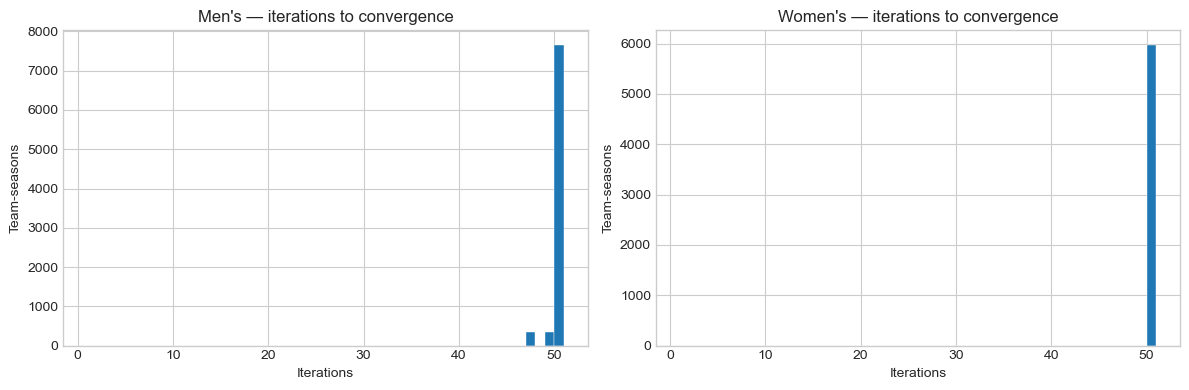

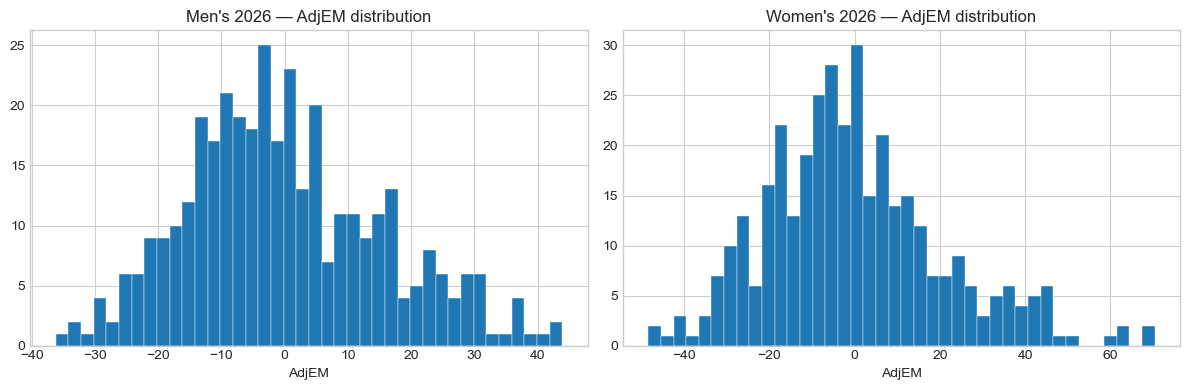

In [11]:
# Convergence visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mw, label, ax in [(0, "Men's", axes[0]), (1, "Women's", axes[1])]:
    sub = adj_eff_df[adj_eff_df['men_women'] == mw]
    ax.hist(sub['iters'], bins=range(1, ADJ_ITER_MAX + 2), edgecolor='white', lw=0.3)
    ax.set_title(f'{label} — iterations to convergence')
    ax.set_xlabel('Iterations'); ax.set_ylabel('Team-seasons')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mw, label, ax in [(0, "Men's", axes[0]), (1, "Women's", axes[1])]:
    sub = adj_eff_df[(adj_eff_df['men_women'] == mw) & (adj_eff_df['Season'] == LATEST_SEASON)]
    ax.hist(sub['AdjEM'], bins=40, edgecolor='white', lw=0.3)
    ax.set_title(f'{label} {LATEST_SEASON} — AdjEM distribution')
    ax.set_xlabel('AdjEM')
plt.tight_layout()
plt.show()


## Section 5: Validate vs KenPom (Optional)

Compare our computed AdjEM against KenPom's published values for Men's seasons.
Expect correlation > 0.85.  Lower correlation = check for data issues or mapping errors.

*(Skip this section if KenPom files are not present or not needed.)*


KenPom loaded: (7634, 21)  |  Seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Columns: ['season', 'TeamName', 'Tempo', 'RankTempo', 'AdjTempo', 'RankAdjTempo', 'OE', 'RankOE', 'AdjOE', 'RankORtg', 'DE', 'RankDE', 'AdjDE', 'RankDRtg', 'AdjEM', 'RankNetRtg', 'seed', 'Season', 'RankAdjOE', 'RankAdjDE', 'RankAdjEM']

Matched: 7630/7634 rows  |  Unmatched unique names: 1
Unmatched (add to MANUAL_MAP if needed):
  "Winston Salem St."

Merged for correlation: 7618 team-seasons

Per-season AdjEM correlation (our ratings vs KenPom):
  2003: r=0.996  n=327  ✓
  2004: r=0.996  n=326  ✓
  2005: r=0.996  n=330  ✓
  2006: r=0.996  n=334  ✓
  2007: r=0.995  n=335  ✓
  2008: r=0.996  n=340  ✓


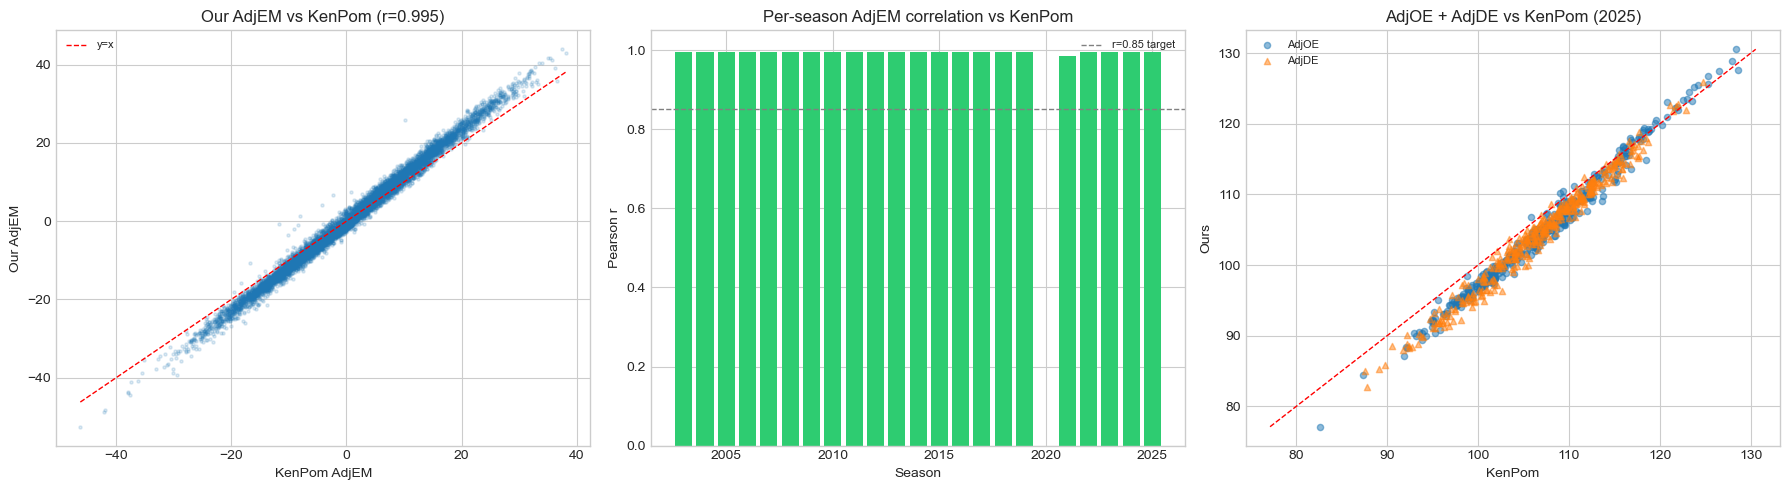

In [12]:
import glob as _glob

# ── Load all KenPom summary files ─────────────────────────────────────────────
_kp_files = sorted(_glob.glob(os.path.join(KENPOM_DIR, 'summary*_pt.csv')))
if not _kp_files:
    print(f'No KenPom files found in {KENPOM_DIR} — skipping validation')
else:
    _dfs = []
    for f in _kp_files:
        _df = pd.read_csv(f)
        _df.columns = [c.strip() for c in _df.columns]
        _df = _df.rename(columns={'ORtg': 'AdjOE', 'DRtg': 'AdjDE', 'NetRtg': 'AdjEM'})
        _dfs.append(_df)

    kp = pd.concat(_dfs, ignore_index=True)
    kp['Season'] = pd.to_numeric(kp['Season'], errors='coerce').astype('Int64')
    if 'AdjEM' not in kp.columns:
        kp['AdjEM'] = kp['AdjOE'] - kp['AdjDE']
    kp = kp[kp['Season'].notna() & (kp['Season'] >= DATA_START)].copy()
    kp['Season'] = kp['Season'].astype(int)

    print(f'KenPom loaded: {kp.shape}  |  Seasons: {sorted(kp["Season"].unique())}')
    print(f'Columns: {list(kp.columns)}')

    # ── Build KenPom TeamName → Kaggle TeamID mapping ─────────────────────────
    spellings = M_spellings.copy()
    spellings['name_lower'] = spellings['TeamNameSpelling'].str.lower().str.strip()
    spell_map = spellings.groupby('name_lower')['TeamID'].first().to_dict()

    kp['name_lower'] = kp['TeamName'].str.lower().str.strip()
    kp['TeamID'] = kp['name_lower'].map(spell_map)

    # ── Manual overrides: KenPom name variants not in MTeamSpellings ──────────
    # TeamIDs confirmed from Kaggle contest data (men's = 1xxx, women's = 3xxx)
    # Source: cross-referenced with initialpass.ipynb auto+manual match results
    MANUAL_MAP = {
        # Old/alternate school names and abbreviation mismatches
        'louisiana lafayette':      1418,   # now just "Louisiana" in KenPom
        'louisiana':                1418,   # recent KenPom shortening
        'louisiana monroe':         1419,
        'illinois chicago':         1227,
        'southwest missouri st.':   1283,   # now Missouri State
        'arkansas little rock':     1114,   # now UALR
        'southwest texas st.':      1402,   # now Texas State
        'tennessee martin':         1404,   # now UT Martin
        'mississippi valley st.':   1290,
        'st. francis ny':           1383,   # now LIU
        'saint francis':            1383,
        'southeast missouri st.':   1369,
        'southeast missouri':       1369,
        'texas a&m corpus chris':   1394,
        'texas a&m-corpus christi': 1394,
        'texas a&m corpus christi': 1394,
        'st. francis pa':           1384,
        'st. francis (pa)':         1384,
        'texas pan american':       1410,   # now UTRGV
        'ut rio grande valley':     1410,
        'bethune cookman':          1126,
        'bethune-cookman':          1126,
        'arkansas pine bluff':      1115,
        'cal st. bakersfield':      1167,
        'cal state bakersfield':    1167,
        'dixie st.':                1469,   # now Utah Tech
        'dixie state':              1469,
        'tarleton st.':             1470,
        'tarleton state':           1470,
        'queens':                   1474,
        'texas a&m commerce':       1477,
        'alabama birmingham':       1102,   # UAB
        'uab':                      1102,
        'seattle':                  1360,
        'seattle u':                1360,
        'incarnate word':           1229,
        'norfolk st.':              1312,
        'norfolk state':            1312,
        'southern u.':              1380,
        'southern university':      1380,
        'njit':                     1307,
        'new jersey inst tech':     1307,
        'cal state fullerton':      1168,
        'cal st. fullerton':        1168,
        'cal state northridge':     1170,
        'cal st. northridge':       1170,
    }

    kp.loc[kp['TeamID'].isna(), 'TeamID'] = (
        kp.loc[kp['TeamID'].isna(), 'name_lower'].map(MANUAL_MAP)
    )

    matched   = kp['TeamID'].notna().sum()
    unmatched_names = sorted(kp[kp['TeamID'].isna()]['TeamName'].unique())
    print(f'\nMatched: {matched}/{len(kp)} rows  |  Unmatched unique names: {len(unmatched_names)}')
    if unmatched_names:
        print('Unmatched (add to MANUAL_MAP if needed):')
        for n in unmatched_names[:30]:
            print(f'  "{n}"')

    # ── Merge with our computed AdjEM (Men's only) ─────────────────────────────
    our_em = (adj_eff_df[adj_eff_df['men_women'] == 0]
              [['Season','TeamID','AdjEM','AdjOE','AdjDE']].copy())
    kp['TeamID'] = pd.to_numeric(kp['TeamID'], errors='coerce')
    merged = our_em.merge(
        kp[['Season','TeamID','AdjEM','AdjOE','AdjDE']]
          .rename(columns={'AdjEM':'kp_AdjEM','AdjOE':'kp_AdjOE','AdjDE':'kp_AdjDE'}),
        on=['Season','TeamID'], how='inner'
    )
    print(f'\nMerged for correlation: {len(merged)} team-seasons')

    # ── Per-season correlation ─────────────────────────────────────────────────
    print('\nPer-season AdjEM correlation (our ratings vs KenPom):')
    corr_by_season = {}
    for s, g in merged.groupby('Season'):
        if len(g) >= 5:
            r = g[['AdjEM','kp_AdjEM']].corr().iloc[0,1]
            corr_by_season[s] = r
            flag = '✓' if r >= 0.85 else '~' if r >= 0.70 else '✗'
            print(f'  {s}: r={r:.3f}  n={len(g)}  {flag}')

    overall_r = merged[['AdjEM','kp_AdjEM']].corr().iloc[0,1]
    print(f'\nOverall correlation (all seasons): r={overall_r:.4f}')
    if overall_r < 0.70:
        print('⚠  Low correlation — check HCA_OE tuning or data issues')
    elif overall_r < 0.85:
        print('~  Moderate — consider tuning HCA_OE (Section 1) or ADJ_ITER_MAX')
    else:
        print('✓  Good correlation with KenPom')

    print(f'\nScale comparison:')
    print(f'  Ours    AdjEM: mean={merged["AdjEM"].mean():.2f}  std={merged["AdjEM"].std():.2f}  '
          f'range=[{merged["AdjEM"].min():.1f}, {merged["AdjEM"].max():.1f}]')
    print(f'  KenPom  AdjEM: mean={merged["kp_AdjEM"].mean():.2f}  std={merged["kp_AdjEM"].std():.2f}  '
          f'range=[{merged["kp_AdjEM"].min():.1f}, {merged["kp_AdjEM"].max():.1f}]')

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(merged['kp_AdjEM'], merged['AdjEM'], alpha=0.15, s=5)
    lo, hi = merged['kp_AdjEM'].min(), merged['kp_AdjEM'].max()
    axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1, label='y=x')
    axes[0].set_xlabel('KenPom AdjEM'); axes[0].set_ylabel('Our AdjEM')
    axes[0].set_title(f'Our AdjEM vs KenPom (r={overall_r:.3f})')
    axes[0].legend(fontsize=8)

    seasons_c = sorted(corr_by_season.keys())
    corrs_c   = [corr_by_season[s] for s in seasons_c]
    colors = ['#2ecc71' if r >= 0.85 else '#e67e22' if r >= 0.70 else '#e74c3c' for r in corrs_c]
    axes[1].bar(seasons_c, corrs_c, color=colors)
    axes[1].axhline(0.85, color='gray', linestyle='--', lw=1, label='r=0.85 target')
    axes[1].set_xlabel('Season'); axes[1].set_ylabel('Pearson r')
    axes[1].set_title('Per-season AdjEM correlation vs KenPom')
    axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8)

    sub25 = merged[merged['Season'] == merged['Season'].max()]
    if len(sub25) > 5:
        axes[2].scatter(sub25['kp_AdjOE'], sub25['AdjOE'], alpha=0.5, s=20, label='AdjOE')
        axes[2].scatter(sub25['kp_AdjDE'], sub25['AdjDE'], alpha=0.5, s=20, label='AdjDE', marker='^')
        lo2 = min(sub25[['kp_AdjOE','kp_AdjDE']].min().min(), sub25[['AdjOE','AdjDE']].min().min())
        hi2 = max(sub25[['kp_AdjOE','kp_AdjDE']].max().max(), sub25[['AdjOE','AdjDE']].max().max())
        axes[2].plot([lo2, hi2], [lo2, hi2], 'r--', lw=1)
        axes[2].set_xlabel('KenPom'); axes[2].set_ylabel('Ours')
        axes[2].set_title(f'AdjOE + AdjDE vs KenPom ({merged["Season"].max()})')
        axes[2].legend(fontsize=8)
    else:
        axes[2].set_visible(False)

    plt.tight_layout(); plt.show()


Scale factor (our AdjEM / KenPom AdjEM): 1.167
Intercept: -0.01
Residual std: 1.358  mean: 0.000

Top 30 outliers (|our_AdjEM - scaled_kp_AdjEM|):
Team                      Season    Ours  KenPom KP_scaled  Residual
---------------------------------------------------------------------------
Colgate                     2021   25.85   10.22     11.93    +13.92  +
Holy Cross                  2021   -0.75  -11.68    -13.64    +12.89  +
Boston Univ                 2021    1.40   -8.04     -9.39    +10.79  +
Army                        2021    6.64   -2.27     -2.65     +9.29  +
Loyola MD                   2021    4.14   -4.34     -5.07     +9.21  +
Lehigh                      2021  -10.74  -16.74    -19.55     +8.82  +
Lafayette                   2021   -1.10   -8.44     -9.86     +8.76  +
American Univ               2021   -2.07   -9.11    -10.64     +8.57  +
Bucknell                    2021   -3.51  -10.11    -11.80     +8.30  +
Gonzaga                     2021   35.75   36.62     42.75  

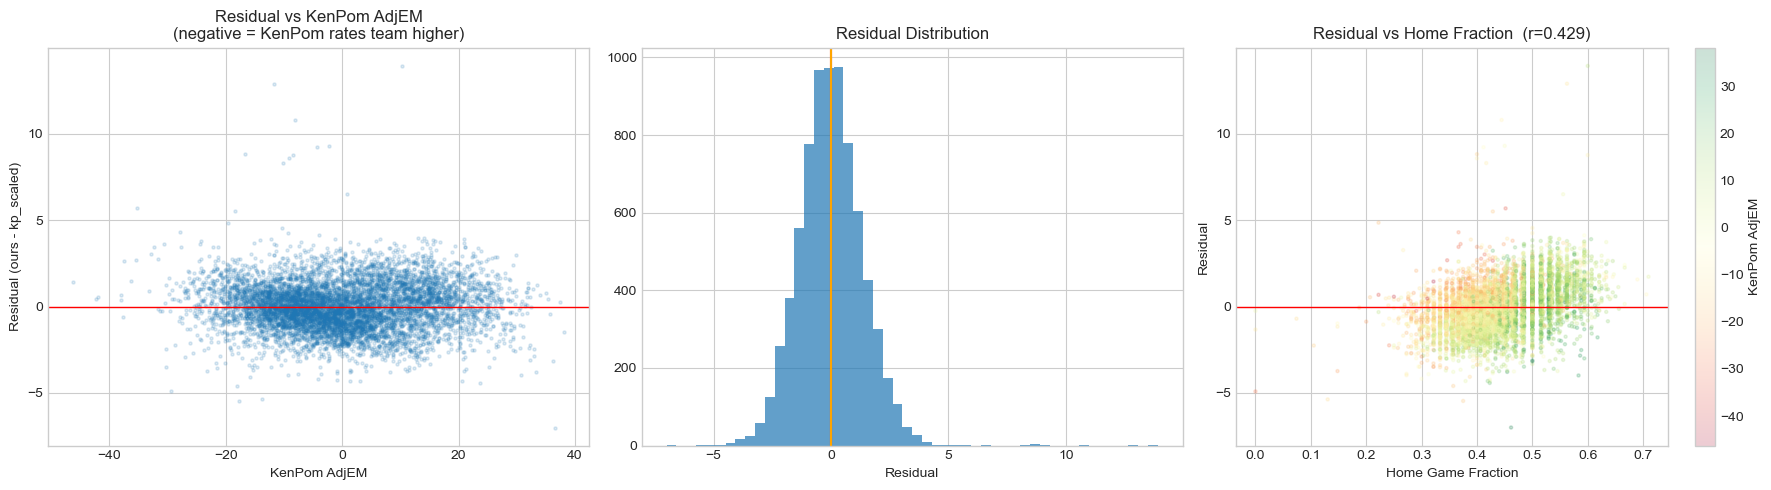


OUTLIER PATTERNS TO LOOK FOR:

We rate HIGHER than KenPom (17 teams):
  Colgate 2021: us=25.8  kp=10.2
  Holy Cross 2021: us=-0.8  kp=-11.7
  Boston Univ 2021: us=1.4  kp=-8.0
  Army 2021: us=6.6  kp=-2.3
  Loyola MD 2021: us=4.1  kp=-4.3
  Lehigh 2021: us=-10.7  kp=-16.7
  Lafayette 2021: us=-1.1  kp=-8.4
  American Univ 2021: us=-2.1  kp=-9.1
  Bucknell 2021: us=-3.5  kp=-10.1
  Navy 2021: us=7.4  kp=0.8

KenPom rates HIGHER than us (13 teams):
  Gonzaga 2021: us=35.8  kp=36.6
  Grambling 2007: us=-26.1  kp=-17.7
  SIUE 2009: us=-21.5  kp=-13.8
  Chicago St 2021: us=-39.2  kp=-29.4
  Nicholls St 2012: us=-25.6  kp=-18.0
  Loyola-Chicago 2021: us=23.3  kp=23.8
  Cleveland St 2021: us=-2.7  kp=1.4
  Samford 2006: us=-0.7  kp=3.1
  Davidson 2008: us=19.7  kp=20.6
  Coastal Car 2006: us=-5.3  kp=-0.9


In [13]:

# ── Section 5B: KenPom Outlier Analysis ──────────────────────────────────────
# Identify which teams/seasons our AdjEM diverges most from KenPom's,
# diagnose WHY, and point to algorithm improvements.
#
# Key hypothesis: outliers come from 4 sources:
#  1. Schedule imbalance (home-heavy teams: HCA_OE applied wrong direction?)
#  2. Small-conference teams (weak SOS signal — less iteration leverage)
#  3. Scale difference (our AdjEM is ~17% wider than KenPom's)
#  4. Possession estimation error for teams with unusual FT rates or pace
#
# We scale-correct first (fit linear regression), then look at residuals.

try:
    _ = merged   # only runs if KenPom validation cell ran successfully
except NameError:
    print("KenPom data not loaded — run Section 5 first.")
else:
    from sklearn.linear_model import LinearRegression as _LR
    from scipy.stats import pearsonr as _pr2

    # ── Scale-correct: fit our_AdjEM ~ a*kp_AdjEM + b ────────────────────────
    X_kp = merged[['kp_AdjEM']].values
    y_us = merged['AdjEM'].values
    lr = _LR().fit(X_kp, y_us)
    merged['kp_scaled'] = lr.predict(X_kp)           # kp mapped to our scale
    merged['residual']  = merged['AdjEM'] - merged['kp_scaled']   # our deviation
    scale_factor = lr.coef_[0]
    print(f"Scale factor (our AdjEM / KenPom AdjEM): {scale_factor:.3f}")
    print(f"Intercept: {lr.intercept_:.2f}")
    print(f"Residual std: {merged['residual'].std():.3f}  mean: {merged['residual'].mean():.3f}")

    # ── Top outliers (largest absolute residual) ──────────────────────────────
    team_name_lut = M_teams.set_index('TeamID')['TeamName'].to_dict()
    merged['TeamName'] = merged['TeamID'].map(team_name_lut)
    top_n = 30
    outliers = merged.reindex(merged['residual'].abs().sort_values(ascending=False).index).head(top_n)

    print(f"\n{'='*75}")
    print(f"Top {top_n} outliers (|our_AdjEM - scaled_kp_AdjEM|):")
    print(f"{'='*75}")
    print(f"{'Team':<25} {'Season':>6} {'Ours':>7} {'KenPom':>7} {'KP_scaled':>9} {'Residual':>9}")
    print(f"{'-'*75}")
    for _, row in outliers.iterrows():
        flag = '+' if row['residual'] > 0 else '-'
        print(f"{str(row.get('TeamName','?')):<25} {int(row['Season']):>6} "
              f"{row['AdjEM']:>7.2f} {row['kp_AdjEM']:>7.2f} "
              f"{row['kp_scaled']:>9.2f} {row['residual']:>+9.2f}  {flag}")

    # ── Hypothesis 1: Home game fraction ─────────────────────────────────────
    # Teams with very different home/away splits → HCA adjustment effect is larger
    home_frac = (reg_sym[reg_sym['men_women'] == 0]
                 .groupby(['Season', 'T1_TeamID'])['T1_home']
                 .agg(home_games=lambda x: (x == 1).sum(),
                      away_games=lambda x: (x == -1).sum(),
                      total_games='count')
                 .reset_index()
                 .rename(columns={'T1_TeamID': 'TeamID'}))
    home_frac['home_frac'] = home_frac['home_games'] / home_frac['total_games'].clip(lower=1)

    merged_hf = merged.merge(home_frac[['Season', 'TeamID', 'home_frac', 'total_games']],
                             on=['Season', 'TeamID'], how='left')
    r_home, _ = _pr2(merged_hf['home_frac'].fillna(0.5), merged_hf['residual'])
    print(f"\nHypothesis 1 — Home game fraction vs residual:  r={r_home:.3f}")
    print("  (positive r = home-heavy teams are OVER-rated by us vs KenPom)")

    # ── Hypothesis 2: Games played (small sample) ─────────────────────────────
    r_games, _ = _pr2(merged_hf['total_games'].fillna(30), merged_hf['residual'].abs())
    print(f"Hypothesis 2 — Games played vs |residual|:      r={r_games:.3f}")
    print("  (negative r = teams with more games have smaller absolute error)")

    # ── Hypothesis 3: Distribution of residuals by season ────────────────────
    print("\nResidual (our minus scaled-KP) by season  [mean | std]:")
    for s, g in merged.groupby('Season'):
        print(f"  {s}: mean={g['residual'].mean():+.3f}  std={g['residual'].std():.3f}  n={len(g)}")

    # ── Residual scatter: are we systematically wrong at tails? ──────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(merged['kp_AdjEM'], merged['residual'], alpha=0.15, s=5)
    axes[0].axhline(0, color='red', linewidth=1)
    axes[0].set_xlabel('KenPom AdjEM'); axes[0].set_ylabel('Residual (ours - kp_scaled)')
    axes[0].set_title('Residual vs KenPom AdjEM\n(negative = KenPom rates team higher)')

    axes[1].hist(merged['residual'], bins=50, edgecolor='none', alpha=0.7)
    axes[1].axvline(0, color='red'); axes[1].axvline(merged['residual'].mean(), color='orange')
    axes[1].set_xlabel('Residual'); axes[1].set_title('Residual Distribution')

    sc = axes[2].scatter(merged_hf['home_frac'].fillna(0.5),
                         merged_hf['residual'], alpha=0.2, s=5,
                         c=merged_hf['kp_AdjEM'], cmap='RdYlGn')
    plt.colorbar(sc, ax=axes[2], label='KenPom AdjEM')
    axes[2].axhline(0, color='red', linewidth=1)
    axes[2].set_xlabel('Home Game Fraction'); axes[2].set_ylabel('Residual')
    axes[2].set_title(f'Residual vs Home Fraction  (r={r_home:.3f})')

    plt.tight_layout(); plt.show()

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("OUTLIER PATTERNS TO LOOK FOR:")
    print("="*60)
    pos_out = outliers[outliers['residual'] > 0]
    neg_out = outliers[outliers['residual'] < 0]
    print(f"\nWe rate HIGHER than KenPom ({len(pos_out)} teams):")
    for _, r in pos_out.head(10).iterrows():
        print(f"  {r.get('TeamName','?')} {int(r['Season'])}: us={r['AdjEM']:.1f}  kp={r['kp_AdjEM']:.1f}")
    print(f"\nKenPom rates HIGHER than us ({len(neg_out)} teams):")
    for _, r in neg_out.head(10).iterrows():
        print(f"  {r.get('TeamName','?')} {int(r['Season'])}: us={r['AdjEM']:.1f}  kp={r['kp_AdjEM']:.1f}")


## Section 6: Season Box Score Averages + Four Factors

Compute mean box score stats per team-season from regular season games:
- **Own stats**: `avg_Score`, `avg_FGM`, etc.
- **Opponent-allowed stats**: `avg_opp_Score`, `avg_opp_FGM`, etc. (proxy for defense)
- **Four Factors** (KenPom-style rate stats): eFGpct, TOpct, ORpct, FTrate — both offense and defense

These are raw averages (no iterative SOS adjustment — that's handled in Section 4 for AdjOE/AdjDE).
They provide granular signal on *how* teams produce offense/defense, not just *how much*.


In [14]:
t1_cols = [f'T1_{c}' for c in BOX_COLS] + ['PointDiff']
t2_cols = [f'T2_{c}' for c in BOX_COLS]

own_avgs = (reg_sym.groupby(['men_women', 'Season', 'T1_TeamID'])[t1_cols]
            .mean()
            .rename(columns=lambda c: c.replace('T1_', 'avg_'))
            .rename(columns={'PointDiff': 'avg_PointDiff'})
            .reset_index()
            .rename(columns={'T1_TeamID': 'TeamID'}))

opp_avgs = (reg_sym.groupby(['men_women', 'Season', 'T1_TeamID'])[t2_cols]
            .mean()
            .rename(columns=lambda c: c.replace('T2_', 'avg_opp_'))
            .reset_index()
            .rename(columns={'T1_TeamID': 'TeamID'}))

season_avgs = own_avgs.merge(opp_avgs, on=['men_women', 'Season', 'TeamID'])
print(f'season_avgs: {len(season_avgs):,} team-seasons')

# ── Four Factors + Extended Style/Efficiency Stats ────────────────────────────
def add_four_factors(df):
    s = df.copy()

    # Possession estimates
    s['poss']     = s['avg_FGA']     - s['avg_OR']     + s['avg_TO']     + FT_FACTOR*s['avg_FTA']
    s['opp_poss'] = s['avg_opp_FGA'] - s['avg_opp_OR'] + s['avg_opp_TO'] + FT_FACTOR*s['avg_opp_FTA']

    # ── Four Factors (offense) ────────────────────────────────────────────────
    s['eFGpct']       = (s['avg_FGM']     + 0.5*s['avg_FGM3'])     / s['avg_FGA'].clip(lower=1)
    s['TOpct']        = s['avg_TO']     / s['poss'].clip(lower=1)
    s['ORpct']        = s['avg_OR']     / (s['avg_OR']     + s['avg_opp_DR']).clip(lower=1)
    s['FTrate']       = s['avg_FTA']     / s['avg_FGA'].clip(lower=1)   # FTA/FGA
    s['TSpct']        = s['avg_Score']     / (2*(s['avg_FGA']     + FT_FACTOR*s['avg_FTA'])).clip(lower=1)

    # ── Four Factors (defense / allowed) ─────────────────────────────────────
    s['opp_eFGpct']   = (s['avg_opp_FGM'] + 0.5*s['avg_opp_FGM3']) / s['avg_opp_FGA'].clip(lower=1)
    s['opp_TOpct']    = s['avg_opp_TO'] / s['opp_poss'].clip(lower=1)
    s['opp_ORpct']    = s['avg_opp_OR'] / (s['avg_opp_OR'] + s['avg_DR']).clip(lower=1)
    s['opp_FTrate']   = s['avg_opp_FTA'] / s['avg_opp_FGA'].clip(lower=1)
    s['opp_TSpct']    = s['avg_opp_Score'] / (2*(s['avg_opp_FGA'] + FT_FACTOR*s['avg_opp_FTA'])).clip(lower=1)

    # ── Shooting % breakdown ─────────────────────────────────────────────────
    s['FG3pct']       = s['avg_FGM3']     / s['avg_FGA3'].clip(lower=1)           # 3P%
    s['opp_FG3pct']   = s['avg_opp_FGM3'] / s['avg_opp_FGA3'].clip(lower=1)
    s['FG2pct']       = (s['avg_FGM']     - s['avg_FGM3'])     / (s['avg_FGA']     - s['avg_FGA3']).clip(lower=1)  # 2P%
    s['opp_FG2pct']   = (s['avg_opp_FGM'] - s['avg_opp_FGM3']) / (s['avg_opp_FGA'] - s['avg_opp_FGA3']).clip(lower=1)
    s['FTpct']        = s['avg_FTM']     / s['avg_FTA'].clip(lower=1)             # FT%
    s['opp_FTpct']    = s['avg_opp_FTM'] / s['avg_opp_FTA'].clip(lower=1)

    # ── 3PA/FGA and A/FGM ────────────────────────────────────────────────────
    s['3PArate']      = s['avg_FGA3']     / s['avg_FGA'].clip(lower=1)
    s['opp_3PArate']  = s['avg_opp_FGA3'] / s['avg_opp_FGA'].clip(lower=1)
    s['ASTrate']      = s['avg_Ast']     / s['avg_FGM'].clip(lower=1)
    s['opp_ASTrate']  = s['avg_opp_Ast'] / s['avg_opp_FGM'].clip(lower=1)

    # ── Defensive stats ───────────────────────────────────────────────────────
    # Block% = blocks / opponent's 2PA
    s['Blkpct']       = s['avg_Blk']     / (s['avg_opp_FGA'] - s['avg_opp_FGA3']).clip(lower=1)
    # Steal% = steals / opponent possessions
    s['Stlpct']       = s['avg_Stl']     / s['opp_poss'].clip(lower=1)

    # ── Non-steal turnover % ──────────────────────────────────────────────────
    # NonStlTOpct = TOs that weren't caused by opponent steals / possessions
    s['NonStlTOpct']     = (s['avg_TO']     - s['avg_opp_Stl']).clip(lower=0) / s['poss'].clip(lower=1)
    s['opp_NonStlTOpct'] = (s['avg_opp_TO'] - s['avg_Stl']).clip(lower=0)     / s['opp_poss'].clip(lower=1)

    # ── Point distribution (% of total points from each source) ─────────────
    s['pct_pts_3']       = 3 * s['avg_FGM3']                          / s['avg_Score'].clip(lower=1)
    s['pct_pts_2']       = 2 * (s['avg_FGM']     - s['avg_FGM3'])     / s['avg_Score'].clip(lower=1)
    s['pct_pts_ft']      = s['avg_FTM']                                / s['avg_Score'].clip(lower=1)
    s['opp_pct_pts_3']   = 3 * s['avg_opp_FGM3']                      / s['avg_opp_Score'].clip(lower=1)
    s['opp_pct_pts_2']   = 2 * (s['avg_opp_FGM'] - s['avg_opp_FGM3']) / s['avg_opp_Score'].clip(lower=1)
    s['opp_pct_pts_ft']  = s['avg_opp_FTM']                            / s['avg_opp_Score'].clip(lower=1)

    return s

season_avgs = add_four_factors(season_avgs)
print(f'season_avgs after Four Factors + style stats: {len(season_avgs.columns)} columns')


season_avgs: 14,311 team-seasons
season_avgs after Four Factors + style stats: 64 columns


## Section 7: GLM Team Quality

Per-season sparse linear model: `PointDiff ~ -1 + T1_team_dummies - T2_team_dummies`.
Coefficient for each team = average contribution to margin, implicitly SOS-adjusted
via joint estimation.  This is the box-score analogue to KenPom AdjEM, useful as a
cross-signal alongside our iterative version.

Computed separately per (Season, men_women).  Takes ~1-2 min total.


In [15]:
def compute_glm_quality(reg_sym_df):
    """
    Per-(Season, men_women) GLM of PointDiff on team indicators.
    Returns team quality coefficients (higher = better).
    """
    records = []
    groups = reg_sym_df.groupby(['men_women', 'Season'])
    for (mw, season), grp in tqdm(groups, desc='GLM quality', total=groups.ngroups):
        grp = grp.reset_index(drop=True)
        all_teams = sorted(set(grp['T1_TeamID'].unique()) | set(grp['T2_TeamID'].unique()))
        team_idx  = {t: i for i, t in enumerate(all_teams)}
        n, k      = len(grp), len(all_teams)

        # Build sparse design matrix: +1 for T1, -1 for T2
        rows = list(range(n)) * 2
        cols = [team_idx[t] for t in grp['T1_TeamID']] + \
               [team_idx[t] for t in grp['T2_TeamID']]
        vals = [1.0] * n + [-1.0] * n
        X = sp.csr_matrix((vals, (rows, cols)), shape=(n, k))
        y = grp['PointDiff'].values

        try:
            reg = sm.OLS(y, X.toarray()).fit()
            coefs = reg.params
        except Exception:
            coefs = np.zeros(k)

        for t, i in team_idx.items():
            records.append({'Season': season, 'men_women': mw,
                            'TeamID': t, 'Quality': coefs[i]})
    return pd.DataFrame(records)

quality_df = compute_glm_quality(reg_sym)
print(f'Quality records: {len(quality_df):,}')


GLM quality: 100%|██████████| 41/41 [00:20<00:00,  2.03it/s]

Quality records: 14,311


## Section 8: Recent Form

Win ratio in the final ~30 days of the regular season (DayNum > `RECENT_DAY_CUTOFF` ≈ 103).
A longer window captures sustained late-season performance rather than a single hot week —
especially useful in the NIL era where roster chemistry often peaks in February/March.


In [16]:
recent = reg_sym[reg_sym['DayNum'] > RECENT_DAY_CUTOFF].copy()
recent['Win'] = (recent['Outcome'] == 1).astype(int)

form_df = (recent.groupby(['men_women', 'Season', 'T1_TeamID'])
           .agg(RecentWinPct=('Win','mean'), RecentGames=('Win','count'))
           .reset_index()
           .rename(columns={'T1_TeamID': 'TeamID'}))

print(f'Recent form records: {len(form_df):,}')
print(f'Median games in window: {form_df["RecentGames"].median():.0f}')

Recent form records: 14,290
Median games in window: 7


## Section 8.5: Elo Ratings

Classic Elo rating, updated after every regular-season game, reset each season.
Captures **recency** that season averages miss — a team on a 10-game winning streak
ranks higher than one that split even-and-even over the same period.

Computed separately per gender.  Parameters from gold-medal solution:
base=1000, k=100, width=400. *(TUNE in Section 1: `BASE_ELO`, `K_FACTOR`, `ELO_WIDTH`)*


In [17]:
def expected_elo(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / ELO_WIDTH))

def compute_elo(reg_raw_df, men_women_flag):
    """End-of-season Elo per team-season. Reset to BASE_ELO at start of each season."""
    records = []
    for season, grp in reg_raw_df.sort_values(['Season','DayNum']).groupby('Season'):
        elos = {}
        for _, row in grp.iterrows():
            w, l = row['WTeamID'], row['LTeamID']
            ew, el = elos.get(w, BASE_ELO), elos.get(l, BASE_ELO)
            delta = K_FACTOR * (1 - expected_elo(ew, el))
            elos[w] = ew + delta
            elos[l] = el - delta
        for tid, elo_val in elos.items():
            records.append({'Season': season, 'men_women': men_women_flag,
                            'TeamID': tid, 'Elo': elo_val})
    return pd.DataFrame(records)

M_elo = compute_elo(M_reg_raw, men_women_flag=0)
W_elo = compute_elo(W_reg_raw, men_women_flag=1)
elo_df = pd.concat([M_elo, W_elo], ignore_index=True)

print(f'Elo records: {len(elo_df):,}')
_elo_latest = elo_df['Season'].max()
top = (elo_df[(elo_df['Season']==_elo_latest) & (elo_df['men_women']==0)]
       .merge(M_teams[['TeamID','TeamName']], on='TeamID', how='left')
       .sort_values('Elo', ascending=False).head(10))
print(f'\nTop Men Elo {_elo_latest}:')
print(top[['TeamName','Elo']].to_string(index=False))


Elo records: 14,311

Top Men Elo 2026:
 TeamName         Elo
     Duke 1710.925070
  Arizona 1650.584219
 Michigan 1571.504637
St John's 1559.841928
 Virginia 1527.683394
 Arkansas 1504.136237
  Florida 1485.529942
   Purdue 1481.829460
  Gonzaga 1481.444867
      VCU 1472.520347


## Section 9: Build Matchup Dataset

For each historical tournament game (both genders), create **two symmetric rows**:
winner-as-A and loser-as-A.  Join all computed per-team features as:
- `A_<feat>`, `B_<feat>` — absolute values for each team
- `d_<feat>` = A - B — differential (primary model input)

**Seed diff** is `B_seed - A_seed` (positive = A is favored, since lower seed = better).

**Sample weights** are uniform by default (`APPLY_NIL_WEIGHTS = False`).
Set `APPLY_NIL_WEIGHTS = True` in Section 1 to ramp up post-NIL season weights 3-6x.


In [18]:
# ── Massey Ordinals: POM + MOR consensus ranking (Men's only) ─────────────────
# MMasseyOrdinals.csv has no Women's equivalent — Women's teams will receive 0.
# POM (KenPom proxy) and MOR both have 100% tournament team coverage at DayNum 133.
# We use DayNum 133 (selection day) for all historical seasons, and the last
# available DayNum for 2026 predictions.

massey_raw = pd.read_csv(os.path.join(CONTEST_DIR, 'MMasseyOrdinals.csv'))

MASSEY_SYSTEMS = ['POM', 'MOR']
massey_sel = massey_raw[massey_raw['SystemName'].isin(MASSEY_SYSTEMS)].copy()

# For each (Season, TeamID, System), keep the last ranking at or before DayNum 133.
# DayNum 133 = Selection Sunday. For 2026, take the most recent available (DayNum 93).
SEL_DAYNUM = 133
massey_pre = massey_sel[massey_sel['RankingDayNum'] <= SEL_DAYNUM]
massey_last = (massey_pre
               .sort_values('RankingDayNum')
               .groupby(['Season', 'SystemName', 'TeamID'])
               .last()
               .reset_index())

# Convert rank to z-score within (Season, SystemName): negate so higher z = better rank
massey_last['neg_rank'] = -massey_last['OrdinalRank']
massey_last['rank_z'] = (massey_last
                         .groupby(['Season', 'SystemName'])['neg_rank']
                         .transform(lambda x: (x - x.mean()) / x.std(ddof=0)))

# Average z-score across systems → single MasseyRank per team-season
massey_team = (massey_last
               .groupby(['Season', 'TeamID'])['rank_z']
               .mean()
               .reset_index()
               .rename(columns={'rank_z': 'MasseyRank'}))

massey_lookup = massey_team.set_index(['Season', 'TeamID'])['MasseyRank'].to_dict()

print(f'Massey lookup: {len(massey_lookup):,} (Season, TeamID) entries')
print(f'Season range: {massey_team["Season"].min()} – {massey_team["Season"].max()}')
print(f'MasseyRank stats: mean={massey_team["MasseyRank"].mean():.3f}, '
      f'std={massey_team["MasseyRank"].std():.3f}, '
      f'min={massey_team["MasseyRank"].min():.2f}, max={massey_team["MasseyRank"].max():.2f}')

Massey lookup: 8,355 (Season, TeamID) entries
Season range: 2003 – 2026
MasseyRank stats: mean=-0.000, std=0.994, min=-1.74, max=1.74


In [19]:
def compute_sample_weights(seasons, nil_year=NIL_YEAR, nil_mult=NIL_MULTIPLIER,
                            apply_nil=APPLY_NIL_WEIGHTS):
    """
    Return per-game sample weights.
    - apply_nil=False (default): uniform weights of 1.0
    - apply_nil=True: post-NIL seasons ramped from nil_mult → 2*nil_mult
    Toggle via APPLY_NIL_WEIGHTS in Section 1.
    """
    seasons = np.array(seasons)
    weights = np.ones(len(seasons))
    if apply_nil:
        max_s = seasons.max()
        mask  = seasons >= nil_year
        if mask.sum() > 0:
            recency = (seasons[mask] - nil_year) / max(1, max_s - nil_year)
            weights[mask] = nil_mult + recency * nil_mult  # nil_mult → 2*nil_mult
    return weights

def safe_get(lookup, key, default=np.nan):
    v = lookup.get(key, default)
    return v if not isinstance(v, (pd.Series, pd.DataFrame)) else default

# Build lookups: (men_women, Season, TeamID) -> value
AE_COLS  = ['AdjOE','AdjDE','AdjEM','AdjTempo']

# All rate/style stats computed in add_four_factors
AVG_COLS = [
    # Raw averages
    'avg_Score', 'avg_PointDiff', 'avg_FGM', 'avg_FGA', 'avg_FGM3', 'avg_FGA3',
    'avg_OR', 'avg_Ast', 'avg_TO', 'avg_Stl', 'avg_Blk', 'avg_opp_Score',
    # Four factors — offense
    'eFGpct', 'TOpct', 'ORpct', 'FTrate', 'TSpct',
    # Four factors — defense
    'opp_eFGpct', 'opp_TOpct', 'opp_ORpct', 'opp_FTrate', 'opp_TSpct',
    # Shooting %
    'FG3pct', 'opp_FG3pct',       # 3P%
    'FG2pct', 'opp_FG2pct',       # 2P%
    'FTpct',  'opp_FTpct',        # FT%
    # Style
    '3PArate', 'opp_3PArate',     # 3PA/FGA
    'ASTrate', 'opp_ASTrate',     # A/FGM
    # Defensive actions
    'Blkpct', 'Stlpct',
    # Non-steal TOs
    'NonStlTOpct', 'opp_NonStlTOpct',
    # Point distribution
    'pct_pts_3', 'pct_pts_2', 'pct_pts_ft',
    'opp_pct_pts_3', 'opp_pct_pts_2', 'opp_pct_pts_ft',
]

ae_lookup   = adj_eff_df.set_index(['men_women','Season','TeamID'])
avg_lookup  = season_avgs.set_index(['men_women','Season','TeamID'])
elo_lookup  = elo_df.set_index(['men_women','Season','TeamID'])['Elo'].to_dict()
qual_lookup = quality_df.set_index(['men_women','Season','TeamID'])['Quality'].to_dict()
form_lookup = form_df.set_index(['men_women','Season','TeamID'])['RecentWinPct'].to_dict()

def get_team_features(mw, season, team):
    key = (mw, season, team)
    feats = {}
    # Iterative AdjOE/AdjDE
    try:
        ae = ae_lookup.loc[key]
        for c in AE_COLS:
            feats[c] = float(ae[c]) if c in ae.index else np.nan
    except KeyError:
        for c in AE_COLS: feats[c] = np.nan
    # Season averages + style stats
    try:
        av = avg_lookup.loc[key]
        for c in AVG_COLS:
            feats[c] = float(av[c]) if c in av.index else np.nan
    except KeyError:
        for c in AVG_COLS: feats[c] = np.nan
    # Other features
    feats['Elo']     = safe_get(elo_lookup,  key)
    feats['Quality'] = safe_get(qual_lookup, key)
    feats['Form']    = safe_get(form_lookup, key)
    feats['Seed']    = safe_get(seed_lookup, (season, team))
    # Massey Ordinals consensus (POM + MOR) — Men's only; Women's = 0 (neutral)
    feats['MasseyRank'] = safe_get(massey_lookup, (season, team), 0.0) if mw == 0 else 0.0
    return feats

print('Lookups built. Building matchup dataset...')
print(f'NIL weights: {"ON" if APPLY_NIL_WEIGHTS else "OFF (uniform)"}')

Lookups built. Building matchup dataset...
NIL weights: OFF (uniform)


In [20]:
matchup_records = []
FEAT_COLS = AE_COLS + AVG_COLS + ['Elo','Quality','Form','Seed','MasseyRank']

for _, row in tqdm(tourn_sym.iterrows(), total=len(tourn_sym), desc='Matchups'):
    mw, season = int(row['men_women']), int(row['Season'])
    ta, tb = int(row['T1_TeamID']), int(row['T2_TeamID'])
    fa = get_team_features(mw, season, ta)
    fb = get_team_features(mw, season, tb)

    rec = {
        'Season'    : season,
        'men_women' : mw,
        'A_TeamID'  : ta,
        'B_TeamID'  : tb,
        'Outcome'   : int(row['Outcome']),   # 1 = A won
        'PointDiff' : float(row['PointDiff']),
    }
    for c in FEAT_COLS:
        rec[f'A_{c}'] = fa.get(c, np.nan)
        rec[f'B_{c}'] = fb.get(c, np.nan)
        rec[f'd_{c}'] = fa.get(c, np.nan) - fb.get(c, np.nan)
    matchups = pd.DataFrame([rec]) if not matchup_records else None
    matchup_records.append(rec)

matchups = pd.DataFrame(matchup_records)

# Sample weights
sw = compute_sample_weights(matchups['Season'].values)
matchups['sample_weight'] = sw

print(f'Matchup dataset: {matchups.shape}')
print(f'Seasons: {sorted(matchups["Season"].unique())}')
print(f'Outcome rate: {matchups["Outcome"].mean():.3f} (should be 0.500)')
print(f'NaN rate in d_AdjEM: {matchups["d_AdjEM"].isna().mean():.3f}')
print(f'Massey coverage (Men): {(matchups.loc[matchups.men_women==0,"d_MasseyRank"] != 0).mean():.3f}')


Matchups: 100%|██████████| 4820/4820 [00:01<00:00, 4309.70it/s]

Matchup dataset: (4820, 160)
Seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Outcome rate: 0.500 (should be 0.500)
NaN rate in d_AdjEM: 0.000
Massey coverage (Men): 0.996


In [21]:
# ── Quality-Weighted Margin — Cap-Free Schedule Strength  *(Section 9.5)*  ────
# Problem with hard Top-N cutoff: teams with only 1 game vs a strong opponent get
# noisy/extreme estimates. Instead, weight EVERY regular-season game by the opponent's
# AdjEM percentile rank within (Season, men_women).
#
#   quality_wtd_margin = Σ(opp_pct_i * margin_i) / Σ(opp_pct_i)
#
# - opp_pct = 1.0 for the strongest team in the pool, ~0 for the weakest
# - Teams on weak schedules get naturally down-weighted (low opp_pct)
# - Teams vs elite opponents get amplified signal
# - No minimum games required; Women's handled within their own gender pool
# - Continuous and smooth — no artifacts from hard cutoffs

# 1. AdjEM percentile within (Season, men_women): 1.0 = strongest, 0.0 = weakest
ae_pct = adj_eff_df[["Season","men_women","TeamID","AdjEM"]].copy()
ae_pct["AdjEM_pct"] = ae_pct.groupby(["Season","men_women"])["AdjEM"].rank(pct=True)

# 2. Join opponent percentile to each regular-season game (T1 = the team we're rating)
qwm_df = reg_sym[["Season","men_women","T1_TeamID","T2_TeamID","PointDiff"]].copy()
qwm_df = qwm_df.merge(
    ae_pct[["Season","men_women","TeamID","AdjEM_pct"]].rename(
        columns={"TeamID": "T2_TeamID", "AdjEM_pct": "opp_AdjEM_pct"}),
    on=["Season","men_women","T2_TeamID"], how="left"
)
qwm_df["opp_AdjEM_pct"] = qwm_df["opp_AdjEM_pct"].fillna(0.5)  # safety for unknown opps
qwm_df.rename(columns={"T1_TeamID": "TeamID"}, inplace=True)

# 3. Per team-season: margin weighted by opponent quality percentile
def _wtd_mean(grp):
    w = grp["opp_AdjEM_pct"].values
    m = grp["PointDiff"].values
    return float(np.dot(w, m) / (w.sum() + 1e-9))

team_qwm = (qwm_df.groupby(["Season","men_women","TeamID"])
            .apply(_wtd_mean, include_groups=False)
            .reset_index(name="quality_wtd_margin"))

print(f"Quality-weighted margin: {len(team_qwm):,} team-seasons")
print(team_qwm["quality_wtd_margin"].describe().round(2))

# 4. Join to matchups
matchups = matchups.merge(
    team_qwm.rename(columns={"TeamID": "A_TeamID",
                              "quality_wtd_margin": "A_quality_wtd_margin"}),
    on=["Season","men_women","A_TeamID"], how="left"
).merge(
    team_qwm.rename(columns={"TeamID": "B_TeamID",
                              "quality_wtd_margin": "B_quality_wtd_margin"}),
    on=["Season","men_women","B_TeamID"], how="left"
)
matchups["d_quality_wtd_margin"] = (matchups["A_quality_wtd_margin"]
                                    - matchups["B_quality_wtd_margin"])

nan_rate = matchups["d_quality_wtd_margin"].isna().mean()
corr_val = matchups[["d_quality_wtd_margin","Outcome"]].corr().iloc[0, 1]
print(f"\nd_quality_wtd_margin — NaN rate: {nan_rate:.3f}, Corr(Outcome): {corr_val:.4f}")
print("(Expect |corr| > 0.2 and NaN rate ≈ 0; if |corr| > 0.3 this is a top-tier feature)")


Quality-weighted margin: 14,311 team-seasons
count    14311.00
mean        -5.23
std          8.73
min        -54.72
25%        -10.55
50%         -4.87
75%          0.62
max         38.02
Name: quality_wtd_margin, dtype: float64

d_quality_wtd_margin — NaN rate: 0.000, Corr(Outcome): 0.4590
(Expect |corr| > 0.2 and NaN rate ≈ 0; if |corr| > 0.3 this is a top-tier feature)


In [22]:

# ── Section 9.6: Tournament Path Features (Bracket-Conditioned Ratings) ───────
#
# Key insight: the bracket structure is fully known pre-tournament.
# A W15 seed playing a W03 seed CAN ONLY happen in the Sweet 16 (R3).
# To reach R3, the 15-seed MUST have beaten W02 (R1) and W07 or W10 (R2).
# This is information we can encode as features — fully computable pre-tournament:
#
#   round_num      — which round is this game? (1-6)
#   A_path_quality — mean AdjEM of prior opponents beaten by Team A  (0 for R1)
#   B_path_quality — mean AdjEM of prior opponents beaten by Team B  (0 for R1)
#   A_prior_margin — mean point margin in Team A's prior tournament games
#   B_prior_margin — same for Team B
#   d_path_quality, d_prior_margin — A minus B differentials
#
# Training: actual prior opponents + margins (from compact results).
# Submission: bracket-expected prior opponent seeds → their AdjEM.
# First Four teams: round_num=2 for their "R1" game (they're more fatigued).

# ── Build bracket path opponent dict ─────────────────────────────────────────
M_slots_raw = pd.read_csv(os.path.join(CONTEST_DIR, 'MNCAATourneySlots.csv'))
W_slots_raw = pd.read_csv(os.path.join(CONTEST_DIR, 'WNCAATourneySlots.csv'))

def build_path_opponents(slots_df):
    """
    Returns path_opp[seed_str][round_num] = sorted list of possible opponent seeds.
    Recursively expands slots: R2W1 contains winners of R1W1 and R1W8, etc.
    Uses most recent season (bracket format is consistent).
    """
    latest = slots_df['Season'].max()
    sdf    = slots_df[slots_df['Season'] == latest]
    sdict  = {r['Slot']: (r['StrongSeed'], r['WeakSeed']) for _, r in sdf.iterrows()}

    _cache = {}
    def expand(node):
        if node in _cache: return _cache[node]
        if node not in sdict: res = frozenset([node])  # leaf = actual seed string
        else:
            st, wk = sdict[node]
            res = expand(st) | expand(wk)
        _cache[node] = res
        return res

    all_seeds = set()
    for slot, (st, wk) in sdict.items():
        if slot.startswith('R1'):
            all_seeds.add(st); all_seeds.add(wk)

    path_opp = {seed: {} for seed in all_seeds}
    for slot, (st, wk) in sdict.items():
        rnd      = int(slot[1])
        s_side   = expand(st)
        w_side   = expand(wk)
        for seed in all_seeds:
            if   seed in s_side: path_opp[seed].setdefault(rnd, set()).update(w_side)
            elif seed in w_side: path_opp[seed].setdefault(rnd, set()).update(s_side)

    return {seed: {r: sorted(s) for r, s in rd.items()} for seed, rd in path_opp.items()}

M_path_opp = build_path_opponents(M_slots_raw)
W_path_opp = build_path_opponents(W_slots_raw)

# Sanity: Saint Peter's (W15) vs Purdue (W03) = Sweet 16 (Round 3)
_test_rnd = next((r for r in sorted(M_path_opp.get('W15', {}).keys())
                  if 'W03' in M_path_opp['W15'][r]), None)
print(f"W15 vs W03 -> Round {_test_rnd}  (expected 3 = Sweet 16)")
print("W15 required path:")
for r in range(1, _test_rnd or 1):
    print(f"  R{r}: beat one of {M_path_opp['W15'][r]}")

def get_round_for_seed_pair(seed_a, seed_b, path_opp):
    """Return round (1-6) where seed_a and seed_b would meet, or None."""
    for rnd in sorted(path_opp.get(seed_a, {}).keys()):
        if seed_b in path_opp[seed_a].get(rnd, []):
            return rnd
    return None

# ── Build actual team tournament history ─────────────────────────────────────
W_compact_pf = pd.read_csv(os.path.join(CONTEST_DIR, 'WNCAATourneyCompactResults.csv'))
compact_pf   = pd.concat([
    M_compact.assign(men_women=0),
    W_compact_pf.assign(men_women=1)
], ignore_index=True)
compact_pf   = compact_pf[compact_pf['Season'] >= DATA_START].copy()

# (mw, season, teamID) -> [(daynum, opp_teamID, margin_for_team)]  sorted by day
team_hist = {}
for _, row in compact_pf.iterrows():
    mw = int(row['men_women']); s = int(row['Season'])
    w, l = int(row['WTeamID']), int(row['LTeamID'])
    m = float(row['WScore'] - row['LScore']); d = int(row['DayNum'])
    team_hist.setdefault((mw, s, w), []).append((d, l,  m))
    team_hist.setdefault((mw, s, l), []).append((d, w, -m))
for key in team_hist:
    team_hist[key].sort()   # chronological

print(f"\nTeam tournament history: {len(team_hist):,} team-seasons")

# Fast AdjEM lookup
adj_pf_idx = adj_eff_df.set_index(['men_women', 'Season', 'TeamID'])['AdjEM'].to_dict()

def get_path_feats(mw, season, team_id, opp_id):
    """
    Find team_id's game vs opp_id in their chronological history.
    Prior games (before this one) give path_quality and prior_margin.
    """
    hist = team_hist.get((mw, season, team_id), [])
    idx  = next((i for i, (_, opp, _) in enumerate(hist) if opp == opp_id), None)
    if idx is None:
        return 1, 0.0, 0.0
    prior     = hist[:idx]
    round_num = len(prior) + 1
    if not prior:
        return 1, 0.0, 0.0
    opp_ems  = [adj_pf_idx.get((mw, season, o), np.nan) for _, o, _ in prior]
    opp_ems  = [x for x in opp_ems if not np.isnan(x)]
    path_q   = float(np.mean(opp_ems)) if opp_ems else 0.0
    pri_marg = float(np.mean([m for _, _, m in prior]))
    return round_num, path_q, pri_marg

# ── Apply to matchups ─────────────────────────────────────────────────────────
print("Computing path features...")
rn_list, apq, bpq, apm, bpm = [], [], [], [], []
for _, row in tqdm(matchups.iterrows(), total=len(matchups), desc='Path features'):
    mw = int(row['men_women']); s = int(row['Season'])
    a  = int(row['A_TeamID']);  b = int(row['B_TeamID'])
    rn, aq, am = get_path_feats(mw, s, a, b)
    _,  bq, bm = get_path_feats(mw, s, b, a)
    rn_list.append(rn); apq.append(aq); bpq.append(bq)
    apm.append(am);     bpm.append(bm)

matchups['round_num']      = rn_list
matchups['A_path_quality'] = apq;  matchups['B_path_quality'] = bpq
matchups['A_prior_margin'] = apm;  matchups['B_prior_margin'] = bpm
matchups['d_path_quality'] = matchups['A_path_quality'] - matchups['B_path_quality']
matchups['d_prior_margin'] = matchups['A_prior_margin'] - matchups['B_prior_margin']

assert matchups.loc[matchups['round_num']==1, 'A_path_quality'].eq(0).all(), \
    "R1 path quality should always be 0"

print("\nRound distribution (2 rows per game, symmetric):")
print(matchups['round_num'].value_counts().sort_index().to_string())
print("\nPath quality stats (R2+ only):")
r2p = matchups[matchups['round_num'] > 1]
print(r2p[['A_path_quality','B_path_quality','d_path_quality',
           'A_prior_margin','B_prior_margin']].describe().round(2).to_string())

from scipy.stats import pearsonr as _pr
r_pq, _ = _pr(r2p['d_path_quality'], r2p['Outcome'])
r_em, _ = _pr(r2p['d_AdjEM'],         r2p['Outcome'])
print(f"\nR2+ predictive signal:")
print(f"  d_AdjEM        r={r_em:.3f}  (baseline)")
print(f"  d_path_quality r={r_pq:.3f}  (Cinderella/path signal)")


W15 vs W03 -> Round 3  (expected 3 = Sweet 16)
W15 required path:
  R1: beat one of ['W02']
  R2: beat one of ['W07', 'W10']

Team tournament history: 2,895 team-seasons
Computing path features...


Path features: 100%|██████████| 4820/4820 [00:00<00:00, 58561.34it/s]


Round distribution (2 rows per game, symmetric):
round_num
1    2447
2    1250
3     600
4     299
5     148
6      76

Path quality stats (R2+ only):
       A_path_quality  B_path_quality  d_path_quality  A_prior_margin  B_prior_margin
count         2373.00         2373.00         2373.00         2373.00         2373.00
mean            15.05           14.92            0.13           15.86           15.53
std             10.20           10.01           15.65           11.04           11.29
min            -21.22          -20.73          -56.89            1.00            0.00
25%              9.36            8.53          -10.25            8.00            8.00
50%             16.44           16.20           -0.00           13.80           13.50
75%             22.00           21.90           10.75           20.80           20.50
max             42.12           42.12           56.89           89.00           89.00

R2+ predictive signal:
  d_AdjEM        r=0.513  (baseline)
  d_path_qual

In [23]:
# ── Feature diagnostics — run this every time to verify signal before the model ──
# If d_AdjEM std ≈ 0 or r(Outcome) ≈ 0, features are broken; check lookup key types.
# Target: |r(d_AdjEM)| > 0.35, |r(d_Seed)| > 0.30, NaN% < 10%

DIAG_FEATS = ['d_AdjEM', 'd_AdjOE', 'd_AdjDE', 'd_Elo', 'd_Quality',
              'd_Seed', 'd_Form', 'd_avg_PointDiff', 'd_eFGpct', 'd_TSpct']

print('=== MATCHUP FEATURE DIAGNOSTICS ===')
print(f'Total rows: {len(matchups):,}  |  Outcome rate: {matchups["Outcome"].mean():.3f}  (should be 0.500)')
print(f'\n{"Feature":<22} {"Mean":>8} {"Std":>8} {"NaN%":>7} {"r(Outcome)":>12}')
print('-' * 60)
for c in DIAG_FEATS:
    if c not in matchups.columns:
        print(f'{c:<22}  NOT IN MATCHUPS')
        continue
    col = matchups[c]
    nan_pct = col.isna().mean() * 100
    valid   = matchups[[c, 'Outcome']].dropna()
    r = valid.corr().iloc[0, 1] if len(valid) > 10 else np.nan
    print(f'{c:<22} {col.mean():>8.3f} {col.std():>8.3f} {nan_pct:>6.1f}% {r:>12.4f}')

# Specific sanity checks
d_em = matchups['d_AdjEM']
print(f'\n--- Sanity checks ---')
print(f'd_AdjEM std = {d_em.std():.3f}  (expect > 3.0; if near 0 → lookup keys broken)')
print(f'd_Seed NaN% = {matchups["d_Seed"].isna().mean()*100:.1f}%  (expect < 5%)')
print(f'd_Elo  NaN% = {matchups["d_Elo"].isna().mean()*100:.1f}%  (expect < 5%)')

# Per-season d_AdjEM mean for top seeds vs rest (rough check)
if 'd_AdjEM' in matchups.columns and 'd_Seed' in matchups.columns:
    sub = matchups[matchups['d_AdjEM'].notna() & matchups['d_Seed'].notna()]
    hi = sub[sub['d_Seed'] > 3]['d_AdjEM'].mean()   # A is clearly better seeded
    lo = sub[sub['d_Seed'] < -3]['d_AdjEM'].mean()  # A is clearly worse seeded
    print(f'd_AdjEM when A favored (d_Seed>3): {hi:.2f}  (expect positive)')
    print(f'd_AdjEM when A underdog (d_Seed<-3): {lo:.2f}  (expect negative)')


=== MATCHUP FEATURE DIAGNOSTICS ===
Total rows: 4,820  |  Outcome rate: 0.500  (should be 0.500)

Feature                    Mean      Std    NaN%   r(Outcome)
------------------------------------------------------------
d_AdjEM                   0.000   19.999    0.0%       0.5541
d_AdjOE                   0.000   12.806    0.0%       0.5118
d_AdjDE                   0.000    9.242    0.0%      -0.4899
d_Elo                     0.000  200.603    0.0%       0.4405
d_Quality                 0.000   14.701    0.0%       0.5534
d_Seed                    0.000    7.420    0.0%      -0.5382
d_Form                    0.000    0.263    0.0%       0.0144
d_avg_PointDiff           0.000    8.519    0.0%       0.4339
d_eFGpct                  0.000    0.044    0.0%       0.2607
d_TSpct                   0.000    0.041    0.0%       0.2522

--- Sanity checks ---
d_AdjEM std = 19.999  (expect > 3.0; if near 0 → lookup keys broken)
d_Seed NaN% = 0.0%  (expect < 5%)
d_Elo  NaN% = 0.0%  (expect < 5%)

## Section 10: EDA — Feature Distributions & Predictive Power


Feature correlations with Outcome:
d_AdjEM            0.5541
d_Quality          0.5534
d_AdjOE            0.5118
d_Elo              0.4405
d_avg_PointDiff    0.4339
d_AdjTempo         0.0842
d_Form             0.0144
d_AdjDE           -0.4899
d_Seed            -0.5382
Name: Outcome, dtype: float64


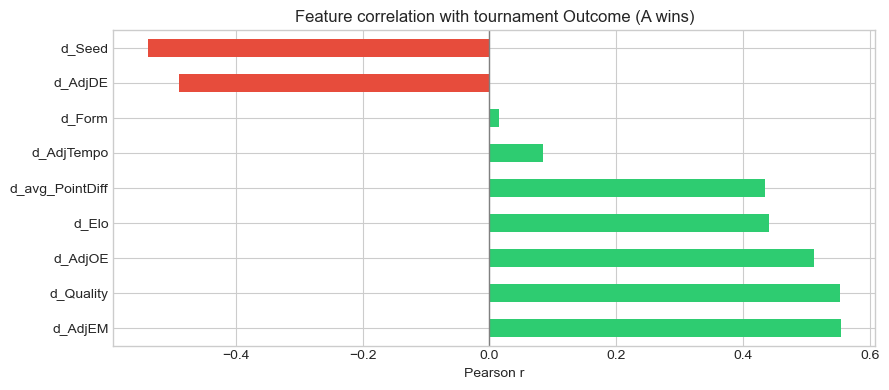

In [24]:
# Feature correlations with Outcome
feat_cols = ['d_AdjEM','d_AdjOE','d_AdjDE','d_AdjTempo',
             'd_Elo','d_Quality','d_Seed','d_Form','d_avg_PointDiff']
corr = (matchups[feat_cols + ['Outcome']]
        .corr()['Outcome'].drop('Outcome')
        .sort_values(ascending=False))
print('Feature correlations with Outcome:')
print(corr.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
corr.plot(kind='barh', ax=ax, color=['#2ecc71' if v>0 else '#e74c3c' for v in corr])
ax.axvline(0, color='gray', lw=1)
ax.set_title('Feature correlation with tournament Outcome (A wins)')
ax.set_xlabel('Pearson r')
plt.tight_layout(); plt.show()


In [25]:
# AdjEM diff by outcome + AUC comparison
print('AUC scores:')
for c in ['d_AdjEM','d_Elo','d_Quality']:
    sub = matchups.dropna(subset=[c])
    auc = roc_auc_score(sub['Outcome'], sub[c])
    print(f'  {c:<20} AUC = {auc:.4f}')

# NIL era: does our AdjEM accuracy change post-2022?
pre  = matchups[(matchups['Season'] < NIL_YEAR) & matchups['d_AdjEM'].notna()]
post = matchups[(matchups['Season'] >= NIL_YEAR) & matchups['d_AdjEM'].notna()]
pre_acc  = ((pre['d_AdjEM']  > 0) == (pre['Outcome']  == 1)).mean()
post_acc = ((post['d_AdjEM'] > 0) == (post['Outcome'] == 1)).mean()
print(f'\nAdjEM directional accuracy: pre-NIL={pre_acc:.3f}  post-NIL={post_acc:.3f}')


AUC scores:
  d_AdjEM              AUC = 0.8364
  d_Elo                AUC = 0.7489
  d_Quality            AUC = 0.8346

AdjEM directional accuracy: pre-NIL=0.749  post-NIL=0.746


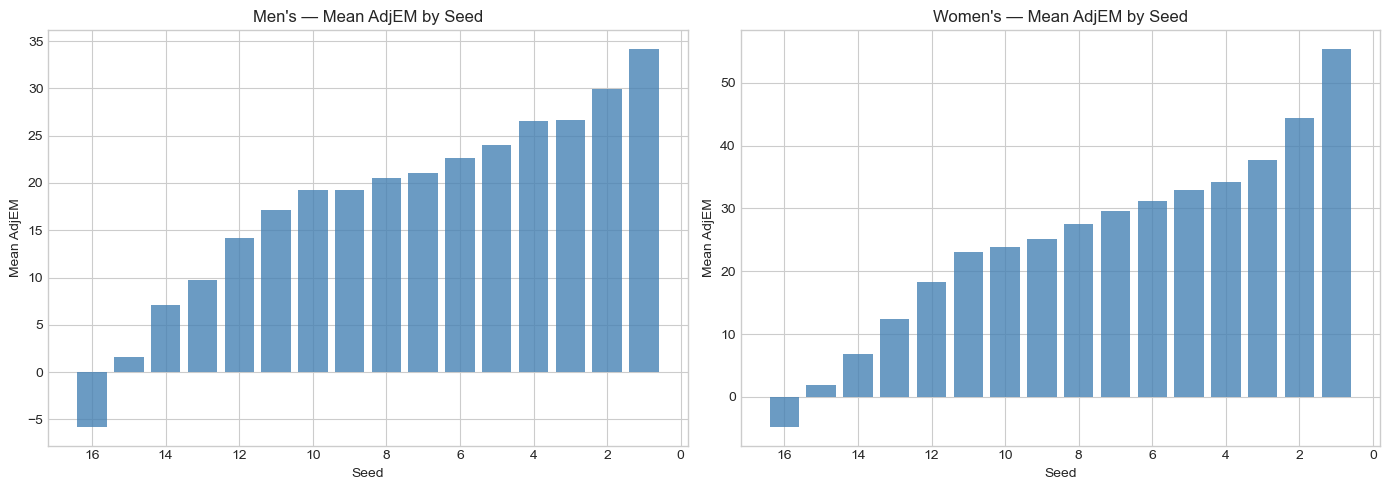

In [26]:
# AdjEM vs seed (do they agree?)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for mw, label, ax in [(0, "Men's", axes[0]), (1, "Women's", axes[1])]:
    sub = matchups[(matchups['men_women'] == mw) & matchups['A_Seed'].notna()].copy()
    sub['A_Seed'] = sub['A_Seed'].astype(int)
    mean_em = sub.groupby('A_Seed')['A_AdjEM'].mean().reset_index()
    ax.bar(mean_em['A_Seed'], mean_em['A_AdjEM'], color='steelblue', alpha=0.8)
    ax.set_xlabel('Seed'); ax.set_ylabel('Mean AdjEM')
    ax.set_title(f'{label} — Mean AdjEM by Seed')
    ax.invert_xaxis()
plt.tight_layout(); plt.show()


## Section 11: Overall Rating Optimization  *(TUNE)*

We find the convex combination of per-team metrics (AdjEM, GLM quality, recent form)
that minimizes LOTO Brier score via Nelder-Mead optimization.

This produces a single **d_Rating** feature that captures more signal than any individual
metric.  The Rating differential is also the primary 'tiebreaker' for potential upsets:
a team with a large Elo advantage but modest AdjEM lead may be underseeded.

**How to tune:**
- Adjust `RATING_W0` in Section 1 to explore different starting points.
- Change `method` (Nelder-Mead vs L-BFGS-B) or add bounds to constrain weights.
- Add or remove features from the combination (e.g., drop Form if its weight collapses).


In [27]:
# Z-score each differential feature (scale-free for optimizer)
Z_FEATURES = ['d_AdjEM','d_Elo','d_Quality','d_Form']
Z_SUFFIX   = '_z'

scaler = StandardScaler()
z_vals = matchups[Z_FEATURES].copy()
# Fill NaN with 0 (neutral) before scaling
z_vals = z_vals.fillna(0)
z_scaled = scaler.fit_transform(z_vals)

for i, c in enumerate(Z_FEATURES):
    matchups[c + Z_SUFFIX] = z_scaled[:, i]

Z_FEAT_COLS = [c + Z_SUFFIX for c in Z_FEATURES]  # ['d_AdjEM_z', ...]
print('Z-scored features added:', Z_FEAT_COLS)


Z-scored features added: ['d_AdjEM_z', 'd_Elo_z', 'd_Quality_z', 'd_Form_z']


In [28]:
def rating_loto_brier(weights, df):
    """
    LOTO Brier score for a given weight vector over z-scored differential features.
    weights = [w_AdjEM, w_Elo, w_Quality, w_Form]
    """
    w = np.array(weights)
    preds_all, targets_all, sw_all = [], [], []
    for season in sorted(df['Season'].unique()):
        val = df[df['Season'] == season]
        if len(val) == 0:
            continue
        d_rating = (val[Z_FEAT_COLS] * w).sum(axis=1)
        probs    = 1 / (1 + np.exp(-d_rating))
        preds_all.extend(probs.tolist())
        targets_all.extend(val['Outcome'].tolist())
        sw_all.extend(val['sample_weight'].tolist())
    return brier_score_loss(targets_all, preds_all, sample_weight=sw_all)

# ── TUNE: optimize weights ────────────────────────────────────────────────────
result = minimize(
    rating_loto_brier,
    x0=RATING_W0,
    args=(matchups,),
    method='Nelder-Mead',
    options={'maxiter': 2000, 'xatol': 1e-5, 'fatol': 1e-6},
)

OPT_WEIGHTS = result.x
feat_names  = ['AdjEM', 'Elo', 'Quality', 'Form']
print('Optimization result:', result.message)
print(f'Optimal Brier: {result.fun:.6f}')
print('Optimal weights:')
for name, w in zip(feat_names, OPT_WEIGHTS):
    print(f'  {name:<12}: {w:.4f}')

# Compare: naive AdjEM-only Brier
naive = rating_loto_brier([1, 0, 0, 0], matchups)
print(f'\nNaive AdjEM-only Brier: {naive:.6f}')
print(f'Improvement:            {naive - result.fun:.6f}')


Optimization result: Optimization terminated successfully.
Optimal Brier: 0.163722
Optimal weights:
  AdjEM       : 1.4121
  Elo         : 0.4622
  Quality     : 0.1673
  Form        : -0.1981

Naive AdjEM-only Brier: 0.174857
Improvement:            0.011135


In [29]:
# Add optimized Rating differential to matchups
matchups['d_Rating'] = (matchups[Z_FEAT_COLS] * OPT_WEIGHTS).sum(axis=1)

# AUC of d_Rating vs individual features
print('AUC after rating optimization:')
for c in ['d_Rating','d_AdjEM_z','d_Elo_z','d_Quality_z']:
    sub = matchups.dropna(subset=[c])
    auc = roc_auc_score(sub['Outcome'], sub[c])
    print(f'  {c:<20} AUC = {auc:.4f}')

# Upset analysis: where does Rating flag potential upsets?
# Upsets = lower seed wins (Seed_diff < 0 for team A, but A wins)
upsets = matchups[(matchups['d_Seed'] < -2) & (matchups['Outcome'] == 1)].copy()
print(f'\nUpset-favorable games (A won despite >= 2 seed disadvantage): {len(upsets)}')
print(f'Mean d_AdjEM in upsets: {upsets["d_AdjEM"].mean():.2f}')
print(f'Mean d_Rating in upsets: {upsets["d_Rating"].mean():.2f}')


AUC after rating optimization:
  d_Rating             AUC = 0.8386
  d_AdjEM_z            AUC = 0.8364
  d_Elo_z              AUC = 0.7489
  d_Quality_z          AUC = 0.8346

Upset-favorable games (A won despite >= 2 seed disadvantage): 1443
Mean d_AdjEM in upsets: 19.69
Mean d_Rating in upsets: 1.93


## Section 12: XGBoost with Cauchy Loss  *(LONG — tune hyperparameters)*

Following the gold-medal architecture: predict **point differential** (continuous)
using XGBoost with a custom Cauchy loss.  The Cauchy loss downweights outliers vs.
squared error, making it more robust to blowout games that don't reflect team quality.

Training is leave-one-tournament-out: for each season S, train on all other seasons,
predict S.  This prevents data leakage and gives realistic OOF performance.

**What to tune:**
- `c` in `cauchyobj` — Cauchy scale parameter (larger = heavier tails tolerated)
- `eta`, `max_depth`, `subsample`, `colsample_bynode`, `min_child_weight`
- `NUM_ROUNDS` — may need 500-1000 for convergence; use early stopping if adding eval set
- `FEATURES` list — add/remove features, experiment with interaction terms

In [30]:
# ── Derived features (computed here, before FEATURES list) ──────────────────
matchups['tempo_seed_interaction'] = matchups['d_AdjTempo'] * matchups['d_Seed']
matchups['d_NetReboundEdge'] = matchups['d_ORpct'] - matchups['d_opp_ORpct']

# ── Feature set (TUNE: add/remove features) ──────────────────────────────────
FEATURES = [
    # Gender flag
    'men_women',
    # Our iterative AdjEM/OE/DE (primary signals)
    'd_AdjEM', 'd_AdjOE', 'd_AdjDE', 'd_AdjTempo',
    # Optimized combined rating (Nelder-Mead blend of AdjEM+Elo+GLM+Form)
    # Tested removing this (2026-03-15): 0.169167 → 0.169338 (+0.000171). REVERTED.
    # XGBoost uses it as a pre-computed summary node; removing forces more splits
    # across the individual components to reconstruct the same boundary.
    'd_Rating',
    # Elo and GLM quality
    'd_Elo', 'd_Quality',
    # Seeds
    'A_Seed', 'B_Seed', 'd_Seed',
    # Recent form (last ~30 days)
    'd_Form',
    # Massey consensus ranking (POM+MOR average z-score; Men's only, Women's=0)
    'd_MasseyRank', 'A_MasseyRank', 'B_MasseyRank',
    # Raw scoring margin
    'd_avg_PointDiff', 'd_avg_Score',
    # Four factors — offense differentials
    'd_eFGpct', 'd_TOpct', 'd_ORpct', 'd_FTrate', 'd_TSpct',
    # Four factors — defense differentials (what opponent gets)
    'd_opp_eFGpct', 'd_opp_TOpct', 'd_opp_ORpct', 'd_opp_FTrate', 'd_opp_TSpct',
    # Shooting % differentials
    'd_FG3pct', 'd_FG2pct', 'd_FTpct',
    'd_opp_FG3pct', 'd_opp_FG2pct', 'd_opp_FTpct',
    # Tempo × Seed interaction
    'tempo_seed_interaction',
    # Style differentials
    'd_3PArate', 'd_opp_3PArate',
    'd_ASTrate', 'd_opp_ASTrate',
    # Defensive action differentials
    'd_Blkpct', 'd_Stlpct',
    # Non-steal TO% differentials
    'd_NonStlTOpct', 'd_opp_NonStlTOpct',
    # Point distribution differentials
    'd_pct_pts_3', 'd_pct_pts_2', 'd_pct_pts_ft',
    'd_opp_pct_pts_3', 'd_opp_pct_pts_2', 'd_opp_pct_pts_ft',
    # Net rebounding edge
    'd_NetReboundEdge',
    # Tournament path features (Section 9.6)
    'round_num',
    'A_path_quality', 'B_path_quality', 'd_path_quality',
    'A_prior_margin', 'B_prior_margin', 'd_prior_margin',
]

FEATURES = [f for f in FEATURES if f in matchups.columns]
print(f'Using {len(FEATURES)} features:')
print(FEATURES)

matchups[FEATURES] = matchups[FEATURES].fillna(0)


Using 56 features:
['men_women', 'd_AdjEM', 'd_AdjOE', 'd_AdjDE', 'd_AdjTempo', 'd_Rating', 'd_Elo', 'd_Quality', 'A_Seed', 'B_Seed', 'd_Seed', 'd_Form', 'd_MasseyRank', 'A_MasseyRank', 'B_MasseyRank', 'd_avg_PointDiff', 'd_avg_Score', 'd_eFGpct', 'd_TOpct', 'd_ORpct', 'd_FTrate', 'd_TSpct', 'd_opp_eFGpct', 'd_opp_TOpct', 'd_opp_ORpct', 'd_opp_FTrate', 'd_opp_TSpct', 'd_FG3pct', 'd_FG2pct', 'd_FTpct', 'd_opp_FG3pct', 'd_opp_FG2pct', 'd_opp_FTpct', 'tempo_seed_interaction', 'd_3PArate', 'd_opp_3PArate', 'd_ASTrate', 'd_opp_ASTrate', 'd_Blkpct', 'd_Stlpct', 'd_NonStlTOpct', 'd_opp_NonStlTOpct', 'd_pct_pts_3', 'd_pct_pts_2', 'd_pct_pts_ft', 'd_opp_pct_pts_3', 'd_opp_pct_pts_2', 'd_opp_pct_pts_ft', 'd_NetReboundEdge', 'round_num', 'A_path_quality', 'B_path_quality', 'd_path_quality', 'A_prior_margin', 'B_prior_margin', 'd_prior_margin']


In [31]:
# ── Join Vegas futures to matchups as pre-tournament team-strength features ───
# Pre-tournament Sweet 16 / Final Four / Champion implied probs encode market
# consensus on how far each team will advance — orthogonal to AdjEM/Elo.
# NaN for seasons without futures data; XGBoost handles natively.

fut_feat_cols = [c for c in ['sweet16_prob', 'ff_prob', 'champ_prob']
                 if c in futures_agg.columns]

if fut_feat_cols and len(futures_agg) > 0:
    for prefix, id_col in [('A', 'A_TeamID'), ('B', 'B_TeamID')]:
        rename_map = {'TeamID': id_col,
                      **{c: f'{prefix}_vegas_{c}' for c in fut_feat_cols}}
        merged = matchups.merge(
            futures_agg[['Season', 'TeamID'] + fut_feat_cols].rename(columns=rename_map),
            on=['Season', id_col], how='left'
        )
        for c in fut_feat_cols:
            matchups[f'{prefix}_vegas_{c}'] = merged[f'{prefix}_vegas_{c}'].values

    for c in fut_feat_cols:
        matchups[f'd_vegas_{c}'] = matchups[f'A_vegas_{c}'] - matchups[f'B_vegas_{c}']

    # Append to FEATURES (defined in cell above)
    vegas_fut_features = []
    for c in fut_feat_cols:
        vegas_fut_features += [f'A_vegas_{c}', f'B_vegas_{c}', f'd_vegas_{c}']
    FEATURES += vegas_fut_features
    # Note: these features have NaN for seasons without data — do NOT fillna(0) here;
    # XGBoost learns from the missingness pattern (NaN = no data available)

    print(f'Vegas futures features added ({len(vegas_fut_features)}): {vegas_fut_features}')
    print('NaN rate per feature:')
    nan_pct = matchups[vegas_fut_features].isna().mean()
    print(nan_pct.to_string())
    print(f'Total FEATURES: {len(FEATURES)}')
else:
    print('No futures features to add (futures_agg empty or no recognized columns)')


No futures features to add (futures_agg empty or no recognized columns)


In [32]:
# ── XGBoost hyperparameters (TUNE) ───────────────────────────────────────────
# Cauchy custom loss removed — sweep showed c=5000 ≈ pure MSE for basketball margins (≤30 pts).
# reg:squarederror is equivalent and cleaner.
PARAM = {
    'objective'        : 'reg:squarederror',
    'booster'          : 'gbtree',
    'eta'              : 0.01,      # TUNE: learning rate
    'subsample'        : 0.6,       # TUNE: row subsampling
    'colsample_bynode' : 0.8,       # TUNE: feature subsampling per split
    'num_parallel_tree': 2,
    'min_child_weight' : 4,         # TUNE: min samples per leaf
    'max_depth'        : 4,         # TUNE: depth=5 tested (+0.000498, worse); 4 is sweet spot
    'tree_method'      : 'hist',
    'grow_policy'      : 'lossguide',
    'max_bin'          : 32,
    'seed'             : 42,       # reproducibility — fixes run-to-run ~0.007 Brier variance
}
NUM_ROUNDS = 700   # TUNE: 1000 tested (+0.000507, slightly worse); 700 is sweet spot at eta=0.01

print(f'XGBoost params set.  NUM_ROUNDS={NUM_ROUNDS}')
print('Run next cell to start LOTO training (~10-30 min).')

XGBoost params set.  NUM_ROUNDS=700
Run next cell to start LOTO training (~10-30 min).


In [33]:
# men_women is a feature so XGBoost learns gender-specific patterns.
models   = {}
oof_pred = []
oof_tgt  = []
oof_sw   = []

for oof_season in sorted(matchups['Season'].unique()):
    train_mask = matchups['Season'] != oof_season
    val_mask   = matchups['Season'] == oof_season

    x_tr = matchups.loc[train_mask, FEATURES].values
    y_tr = matchups.loc[train_mask, 'PointDiff'].values
    sw_tr= matchups.loc[train_mask, 'sample_weight'].values

    x_va = matchups.loc[val_mask, FEATURES].values
    y_va = matchups.loc[val_mask, 'PointDiff'].values

    dtrain = xgb.DMatrix(x_tr, label=y_tr, weight=sw_tr)
    dval   = xgb.DMatrix(x_va, label=y_va)

    model = xgb.train(
        PARAM, dtrain,
        num_boost_round=NUM_ROUNDS,
        verbose_eval=False,
    )
    models[oof_season] = model

    pred_margin = model.predict(dval)
    oof_pred.extend(pred_margin.tolist())
    oof_tgt.extend(y_va.tolist())
    oof_sw.extend(matchups.loc[val_mask, 'sample_weight'].tolist())
    gc.collect()

oof_pred = np.array(oof_pred)
oof_tgt  = np.array(oof_tgt)
matchups['xgb_margin'] = oof_pred

from sklearn.metrics import mean_absolute_error
print(f'OOF MAE (margin): {mean_absolute_error(oof_tgt, oof_pred, sample_weight=oof_sw):.3f}')
print(f'Naive MAE (predict 0): {mean_absolute_error(oof_tgt, np.zeros_like(oof_tgt)):.3f}')

OOF MAE (margin): 9.301
Naive MAE (predict 0): 13.825


## Section 13: Leaf-Based Logistic Calibration

The XGBoost model predicts **point differential** (continuous).  To get calibrated
win probabilities, we use the gold-medal trick:

1. For each game, extract the **leaf node indices** from the XGBoost model — each tree
   routes the input to one leaf, giving a tuple of integers.
2. Encode these leaf indices as a sparse binary feature vector (one indicator per leaf).
3. Fit a **logistic regression** on the binary outcome (A wins) using these leaf features.

The logistic is also fit leave-one-tournament-out to prevent leakage.


In [34]:
def make_leaf_strings(leaf_mat):
    """Convert leaf index matrix (n_games x n_trees) to list of sparse feature strings."""
    return [
        ' '.join(f'{j}_{int(leaf_mat[i, j])}' for j in range(leaf_mat.shape[1]))
        for i in range(leaf_mat.shape[0])
    ]

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

logistic_models = {}
brier_by_season  = {}
all_probs_raw    = np.full(len(matchups), np.nan)

for oof_season in sorted(matchups['Season'].unique()):
    train_mask = matchups['Season'] != oof_season
    val_mask   = matchups['Season'] == oof_season

    y_tr = matchups.loc[train_mask, 'Outcome'].values
    model = models[oof_season]

    x_tr = matchups.loc[train_mask, FEATURES].values
    x_va = matchups.loc[val_mask,   FEATURES].values
    dtr = xgb.DMatrix(x_tr); dva = xgb.DMatrix(x_va)

    str_tr = make_leaf_strings(model.predict(dtr, pred_leaf=True))
    str_va = make_leaf_strings(model.predict(dva, pred_leaf=True))

    calibrater = make_pipeline(
        TfidfVectorizer(),
        LogisticRegression(solver='liblinear', C=1.0, max_iter=300, random_state=0)
    )
    calibrater.fit(str_tr, y_tr)
    raw = calibrater.predict_proba(str_va)[:, 1]

    logistic_models[oof_season] = calibrater
    all_probs_raw[matchups[val_mask].index] = raw
    gc.collect()

matchups['pred_prob_raw'] = all_probs_raw

# ── Flag play-in games (First Four) — excluded from Brier & T optimization ───
# Kaggle does not score play-in games. A_Seed == B_Seed identifies them
# (two 16-seeds or two 11-seeds competing for a bracket slot).
matchups['is_playin'] = matchups['A_Seed'] == matchups['B_Seed']
matchups['seed_gap']  = matchups['d_Seed'].abs()

# ── Temperature scaling ───────────────────────────────────────────────────────
# Men's:   two-T approach (threshold = seed_gap > 10)
# Women's: two-T approach (threshold = seed_gap > 8)
#   T_W_close:   seed_gap ≤ 8  — competitive games, 1v8 / 7v14 type
#   T_W_blowout: seed_gap > 8  — true mismatches: 1v10+, 2v11+, UConn/SC
#   Analysis (2026-03-16): Women's two-T Delta = −0.000761 overall.
#   Men's two-T split (seed_gap>10) added 2026-03-18.

def apply_temperature(probs_raw, T):
    p = np.clip(probs_raw, 1e-7, 1 - 1e-7)
    return 1.0 / (1.0 + np.exp(-np.log(p / (1 - p)) / T))

from scipy.optimize import minimize_scalar

# Men's — competitive games (seed_gap ≤ 10)
M_close_mask   = (matchups['men_women'] == 0) & ~matchups['is_playin'] & (matchups['seed_gap'] <= 10)
# Men's — blowout games (seed_gap > 10): 1v16, 2v15, 3v14 type mismatches
M_blowout_mask = (matchups['men_women'] == 0) & ~matchups['is_playin'] & (matchups['seed_gap'] >  10)

opt_Mc = minimize_scalar(
    lambda T: brier_score_loss(
        matchups.loc[M_close_mask, 'Outcome'].values,
        apply_temperature(matchups.loc[M_close_mask, 'pred_prob_raw'].values, T),
        sample_weight=matchups.loc[M_close_mask, 'sample_weight'].values
    ),
    bounds=(0.5, 5.0), method='bounded'
)
T_M_close = opt_Mc.x

opt_Mb = minimize_scalar(
    lambda T: brier_score_loss(
        matchups.loc[M_blowout_mask, 'Outcome'].values,
        apply_temperature(matchups.loc[M_blowout_mask, 'pred_prob_raw'].values, T),
        sample_weight=matchups.loc[M_blowout_mask, 'sample_weight'].values
    ),
    bounds=(0.05, 5.0), method='bounded'
)
T_M_blowout = opt_Mb.x

# Women's — competitive
W_close_mask   = (matchups['men_women'] == 1) & ~matchups['is_playin'] & (matchups['seed_gap'] <= 8)
W_blowout_mask = (matchups['men_women'] == 1) & ~matchups['is_playin'] & (matchups['seed_gap'] >  8)

opt_Wc = minimize_scalar(
    lambda T: brier_score_loss(
        matchups.loc[W_close_mask, 'Outcome'].values,
        apply_temperature(matchups.loc[W_close_mask, 'pred_prob_raw'].values, T)
    ),
    bounds=(0.5, 5.0), method='bounded'
)
T_W_close = opt_Wc.x

# Women's — blowout (lower bound 0.05 allows near-binary predictions)
opt_Wb = minimize_scalar(
    lambda T: brier_score_loss(
        matchups.loc[W_blowout_mask, 'Outcome'].values,
        apply_temperature(matchups.loc[W_blowout_mask, 'pred_prob_raw'].values, T)
    ),
    bounds=(0.05, 5.0), method='bounded'
)
T_W_blowout = opt_Wb.x

TEMP_SCALE         = {0: T_M_close, 1: T_W_close}  # close-game temps per gender
TEMP_SCALE_BLOWOUT = T_W_blowout    # Women's blowout temp (seed_gap > 8)
T_M_BLOWOUT        = T_M_blowout    # Men's blowout temp  (seed_gap > 10)

# Apply temperature — 4 non-playin segments + Men's play-in via close temp
Mc_all_idx = matchups.index[(matchups['men_women'] == 0) & ~M_blowout_mask]  # Men's close + play-in
Mb_idx     = matchups.index[M_blowout_mask]
Wc_idx     = matchups.index[W_close_mask | ((matchups['men_women'] == 1) & matchups['is_playin'])]
Wb_idx     = matchups.index[W_blowout_mask]

pred_prob = np.zeros(len(matchups))
pred_prob[matchups.index.get_indexer(Mc_all_idx)] = apply_temperature(matchups.loc[Mc_all_idx, 'pred_prob_raw'].values, T_M_close)
pred_prob[matchups.index.get_indexer(Mb_idx)]     = apply_temperature(matchups.loc[Mb_idx,     'pred_prob_raw'].values, T_M_blowout)
pred_prob[matchups.index.get_indexer(Wc_idx)]     = apply_temperature(matchups.loc[Wc_idx,     'pred_prob_raw'].values, T_W_close)
pred_prob[matchups.index.get_indexer(Wb_idx)]     = apply_temperature(matchups.loc[Wb_idx,     'pred_prob_raw'].values, T_W_blowout)
matchups['pred_prob'] = pred_prob

# Build brier_by_season — excluding play-in
for s in sorted(matchups['Season'].unique()):
    mask_s = (matchups['Season'] == s) & ~matchups['is_playin']
    brier_by_season[s] = brier_score_loss(
        matchups.loc[mask_s, 'Outcome'],
        matchups.loc[mask_s, 'pred_prob']
    )

# Overall Brier — excluding play-in
_scored = ~matchups['is_playin']
overall_brier = brier_score_loss(
    matchups.loc[_scored, 'Outcome'],
    matchups.loc[_scored, 'pred_prob'],
    sample_weight=matchups.loc[_scored, 'sample_weight']
)

print(f"T_M_close={T_M_close:.4f}  |  T_M_blowout={T_M_blowout:.4f}  |  T_W_close={T_W_close:.4f}  |  T_W_blowout={T_W_blowout:.4f}")
print(f"Overall LOTO Brier (excl. play-in, split-T Men's + Women's): {overall_brier:.6f}")


T_M_close=1.3142  |  T_M_blowout=0.8510  |  T_W_close=1.2569  |  T_W_blowout=0.0500
Overall LOTO Brier (excl. play-in, split-T Men's + Women's): 0.164540


In [35]:
# ── Vegas game line blend ─────────────────────────────────────────────────────
# Blend temperature-scaled model prob with market-implied probability.
# Game lines keyed as (Season, T1_TeamID=lower, T2_TeamID=higher).
# Symmetric dataset: 2 rows per game — flip vegas_prob when A is the higher-ID team.
# Where no Vegas line: pred_prob_final = pred_prob (graceful fallback).

if len(lines_agg) > 0:
    # Direction-aware merge
    matchups['_key_lo'] = matchups[['A_TeamID', 'B_TeamID']].min(axis=1)
    matchups['_key_hi'] = matchups[['A_TeamID', 'B_TeamID']].max(axis=1)
    matchups['_a_is_lo'] = matchups['A_TeamID'] == matchups['_key_lo']

    tmp = matchups.merge(
        lines_agg.rename(columns={'T1_TeamID': '_key_lo', 'T2_TeamID': '_key_hi'}),
        on=['Season', '_key_lo', '_key_hi'], how='left'
    )
    # P(T1=lower-ID wins); flip when A is the higher-ID team
    matchups['vegas_prob'] = np.where(
        tmp['_a_is_lo'].values,
        tmp['vegas_prob'].values,
        1 - tmp['vegas_prob'].values
    )
    matchups.drop(columns=['_key_lo', '_key_hi', '_a_is_lo'], inplace=True)

    has_vegas = matchups['vegas_prob'].notna()
    print(f'Vegas game lines matched: {has_vegas.sum():,} / {len(matchups):,} rows')
    if has_vegas.any():
        print(matchups.loc[has_vegas, 'Season'].value_counts().sort_index().to_string())

    # Fit blend weight α on matchups WITH Vegas data (minimize Brier)
    from scipy.optimize import minimize_scalar as _ms2

    def blend_brier(alpha, df):
        blended = alpha * df['pred_prob'] + (1 - alpha) * df['vegas_prob']
        return brier_score_loss(df['Outcome'], blended, sample_weight=df['sample_weight'])

    vegas_df = matchups[has_vegas].copy()
    opt = _ms2(lambda a: blend_brier(a, vegas_df), bounds=(0.0, 1.0), method='bounded')
    VEGAS_ALPHA = opt.x
    print(f'\nOptimal blend weight: α={VEGAS_ALPHA:.3f}  (0=pure Vegas, 1=pure model)')
    print(f'Brier model-only   (Vegas games): {blend_brier(1.0, vegas_df):.6f}')
    print(f'Brier Vegas-only   (Vegas games): {blend_brier(0.0, vegas_df):.6f}')
    print(f'Brier blend α={VEGAS_ALPHA:.3f} (Vegas games): {blend_brier(VEGAS_ALPHA, vegas_df):.6f}')

    # Apply blend: blended where line available, model-only otherwise
    matchups['pred_prob_final'] = np.where(
        has_vegas,
        VEGAS_ALPHA * matchups['pred_prob'] + (1 - VEGAS_ALPHA) * matchups['vegas_prob'],
        matchups['pred_prob']
    )
else:
    matchups['pred_prob_final'] = matchups['pred_prob']
    VEGAS_ALPHA = 1.0
    print('No Vegas lines loaded — pred_prob_final = pred_prob (no blend)')

# Overall Brier with blended predictions (excluding play-in — matches Kaggle metric)
_scored = ~matchups['is_playin']
overall_brier_blended = brier_score_loss(
    matchups.loc[_scored, 'Outcome'], matchups.loc[_scored, 'pred_prob_final'],
    sample_weight=matchups.loc[_scored, 'sample_weight']
)
print(f'\nOverall LOTO Brier (model only):  {overall_brier:.6f}')
print(f'Overall LOTO Brier (Vegas blend): {overall_brier_blended:.6f}')
print(f'Delta:                            {overall_brier_blended - overall_brier:+.6f}')


Vegas game lines matched: 114 / 4,820 rows
Season
2024    56
2025    58

Optimal blend weight: α=1.000  (0=pure Vegas, 1=pure model)
Brier model-only   (Vegas games): 0.155714
Brier Vegas-only   (Vegas games): 0.176005
Brier blend α=1.000 (Vegas games): 0.155714

Overall LOTO Brier (model only):  0.164540
Overall LOTO Brier (Vegas blend): 0.164540
Delta:                            +0.000000


In [36]:
# ── Section 16F: Model vs Vegas divergence analysis (2025) ───────────────────
import warnings
warnings.filterwarnings('ignore')

_DATA_DIR = "/Users/reillykoren/Desktop/contest-data"

_m25 = matchups[(matchups['Season'] == 2025) & matchups['vegas_prob'].notna()].copy()
_m25['model_prob']    = _m25['pred_prob']
_m25['vegas_prob_dv'] = _m25['vegas_prob']
_m25['gap']           = _m25['model_prob'] - _m25['vegas_prob_dv']
_m25['abs_gap']       = _m25['gap'].abs()

_m25_dedup = _m25[_m25['A_TeamID'] < _m25['B_TeamID']].copy()

_teams = pd.read_csv(os.path.join(_DATA_DIR, 'MTeams.csv'))[['TeamID','TeamName']]
_name  = dict(zip(_teams['TeamID'], _teams['TeamName']))

_m25_dedup['Team_A'] = _m25_dedup['A_TeamID'].map(_name)
_m25_dedup['Team_B'] = _m25_dedup['B_TeamID'].map(_name)
_m25_dedup['G']      = _m25_dedup['men_women'].map({1:'M', 0:'W'})

_disp = (_m25_dedup
    .sort_values('abs_gap', ascending=False)
    [['G','Team_A','Team_B','model_prob','vegas_prob_dv','gap','Outcome']]
    .reset_index(drop=True)
)

print(f"2025 games with Vegas lines: {len(_disp)}")
print()
print(f"{'#':>2}  {'G'}  {'Team A (lower ID)':22}  {'Team B':22}  "
      f"{'Model':>6}  {'Vegas':>6}  {'Gap':>7}  Result")
print("-" * 88)
for i, row in _disp.iterrows():
    result      = "A won" if row['Outcome'] == 1 else "B won"
    mdl_closer  = abs(row['model_prob'] - row['Outcome']) < abs(row['vegas_prob_dv'] - row['Outcome'])
    flag        = " ✓" if mdl_closer else "  "
    print(f"{i+1:>2}  {row['G']}  {row['Team_A']:22}  {row['Team_B']:22}  "
          f"{row['model_prob']:6.3f}  {row['vegas_prob_dv']:6.3f}  {row['gap']:+7.3f}  {result}{flag}")

print()
n_closer = sum(abs(_m25_dedup['model_prob'] - _m25_dedup['Outcome']) <
               abs(_m25_dedup['vegas_prob_dv'] - _m25_dedup['Outcome']))
print(f"Model closer to outcome: {n_closer} / {len(_m25_dedup)} games")
print(f"Mean |gap|:              {_m25_dedup['abs_gap'].mean():.4f}")
print(f"Mean gap (model−Vegas):  {_m25_dedup['gap'].mean():+.4f}  (+ = model favors A more than Vegas)")


2025 games with Vegas lines: 29

 #  G  Team A (lower ID)       Team B                   Model   Vegas      Gap  Result
----------------------------------------------------------------------------------------
 1  W  Drake                   Missouri                 0.538   0.290   +0.247  A won ✓
 2  W  Arkansas                Kansas                   0.496   0.347   +0.150  A won ✓
 3  W  Texas A&M               Yale                     0.842   0.724   +0.117  A won ✓
 4  W  Michigan                UC San Diego             0.476   0.577   -0.101  A won  
 5  W  Marquette               New Mexico               0.690   0.598   +0.092  B won  
 6  W  BYU                     VCU                      0.504   0.569   -0.065  A won  
 7  W  Kentucky                Troy                     0.893   0.829   +0.064  A won ✓
 8  W  Creighton               Louisville               0.409   0.460   -0.051  A won  
 9  W  High Point              Purdue                   0.182   0.228   -0.045  B won ✓

Brier score by season:
  2003: 0.1828  (n=128)
  2004: 0.1812  (n=128)
  2005: 0.1758  (n=128)
  2006: 0.1875  (n=128)
  2007: 0.1525  (n=128)
  2008: 0.1558  (n=128)
  2009: 0.1792  (n=128)
  2010: 0.1701  (n=254)
  2011: 0.1681  (n=260)
  2012: 0.1426  (n=260)
  2013: 0.1686  (n=260)
  2014: 0.1768  (n=260)
  2015: 0.1417  (n=260)
  2016: 0.1784  (n=260)
  2017: 0.1499  (n=260)
  2018: 0.1715  (n=260)
  2019: 0.1426  (n=260)
  2021: 0.1858  (n=258)
  2022: 0.1776  (n=268)
  2023: 0.1916  (n=268)
  2024: 0.1496  (n=268)
  2025: 0.1193  (n=268)


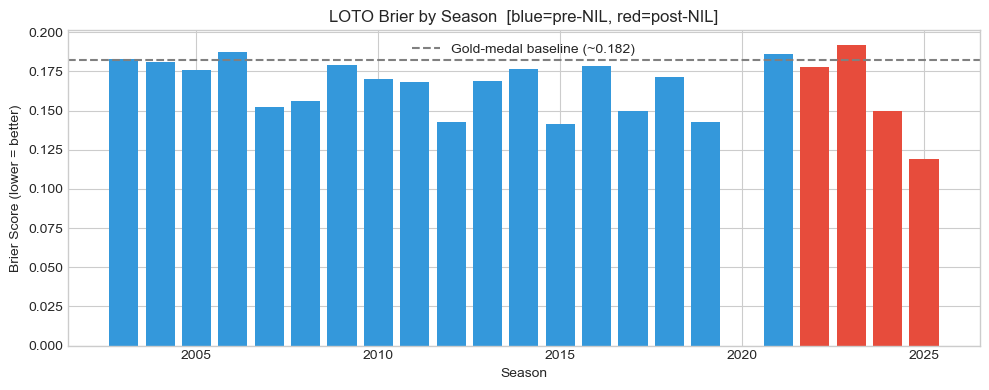

In [37]:
# Brier by season (compare to gold-medal ~0.182)
print('Brier score by season:')
for s, b in sorted(brier_by_season.items()):
    n = (matchups['Season'] == s).sum()
    print(f'  {s}: {b:.4f}  (n={n})')

fig, ax = plt.subplots(figsize=(10, 4))
seasons = sorted(brier_by_season.keys())
briers  = [brier_by_season[s] for s in seasons]
ax.bar(seasons, briers, color=['#e74c3c' if s >= NIL_YEAR else '#3498db' for s in seasons])
ax.axhline(0.182, color='gray', linestyle='--', label='Gold-medal baseline (~0.182)')
ax.set_xlabel('Season'); ax.set_ylabel('Brier Score (lower = better)')
ax.set_title('LOTO Brier by Season  [blue=pre-NIL, red=post-NIL]')
ax.legend()
plt.tight_layout(); plt.show()


In [38]:
# ── Section 16G: Women's calibration by seed gap ─────────────────────────────
# Analysis: does a seed-conditional T_W improve Women's Brier?
# Threshold > 8 cleanly separates true blowouts (1v10+, 2v11+, etc.)
# from competitive games (1v8, 2v9 etc. which also have seed gap 7-8).

W_mask = (matchups['men_women'] == 1) & ~matchups['is_playin']
W = matchups[W_mask].copy()
W['seed_gap'] = W['d_Seed'].abs()

print("=== Women's calibration by seed gap (LOTO, excl. play-in) ===\n")
print(f"{'Seed gap':>10}  {'n':>5}  {'model_brier':>11}  notes")
print("-" * 55)

bins = [0, 2, 4, 6, 8, 10, 16]
labels = ['≤2','3-4','5-6','7-8','9-10','>10']
W['gap_bucket'] = pd.cut(W['seed_gap'], bins=bins, labels=labels)

for bucket in labels:
    sub = W[W['gap_bucket'] == bucket]
    if len(sub) == 0: continue
    b = brier_score_loss(sub['Outcome'], sub['pred_prob'])
    note = '' if bucket not in ['9-10','>10'] else '← blowout territory'
    print(f"  {bucket:>8}  {len(sub):>5}  {b:>11.6f}  {note}")

# ── Test: threshold > 8 (true blowouts only) ─────────────────────────────────
print("\n=== Testing seed-conditional T_W (threshold = seed_gap > 8) ===")
W_close   = W[W['seed_gap'] <= 8]
W_blowout = W[W['seed_gap'] >  8]

def brier_T(T, df):
    p = apply_temperature(df['pred_prob_raw'].values, T)
    return brier_score_loss(df['Outcome'].values, p)

opt_close = minimize_scalar(
    lambda T: brier_T(T, W_close), bounds=(0.5, 5.0), method='bounded')
opt_blow  = minimize_scalar(
    lambda T: brier_T(T, W_blowout), bounds=(0.3, 5.0), method='bounded')

T_W_close   = opt_close.x
T_W_blowout = opt_blow.x
print(f"  Optimal T_W (seed_gap ≤ 8, n={len(W_close)}): {T_W_close:.4f}  ← competitive + 7v14 type games")
print(f"  Optimal T_W (seed_gap > 8, n={len(W_blowout)}): {T_W_blowout:.4f}  ← 1v10+, 2v11+, UConn/SC mismatches")

# Sample probability mapping under each T
print(f"\n  Sample blowout game raw→prob under each T:")
for raw in [0.85, 0.90, 0.93, 0.96, 0.98]:
    p_curr = apply_temperature(np.array([raw]), TEMP_SCALE[1])[0]
    p_blow = apply_temperature(np.array([raw]), T_W_blowout)[0]
    print(f"    raw={raw:.2f}  current(T={TEMP_SCALE[1]:.3f})→{p_curr:.4f}  "
          f"blowout(T={T_W_blowout:.3f})→{p_blow:.4f}")

# Simulate total Women's Brier with two-T approach (threshold > 8)
W_combined = W.copy()
W_combined['p_two_T'] = np.where(
    W_combined['seed_gap'] > 8,
    W_combined['pred_prob_raw'].apply(lambda r: apply_temperature(np.array([r]), T_W_blowout)[0]),
    W_combined['pred_prob_raw'].apply(lambda r: apply_temperature(np.array([r]), T_W_close)[0])
)
b_current = brier_score_loss(W['Outcome'], W['pred_prob'])
b_two_T   = brier_score_loss(W_combined['Outcome'], W_combined['p_two_T'])
print(f"\n  Women's Brier — current (single T={TEMP_SCALE[1]:.3f}): {b_current:.6f}")
print(f"  Women's Brier — two-T (close={T_W_close:.3f}, blowout={T_W_blowout:.3f}): {b_two_T:.6f}")
print(f"  Delta: {b_two_T - b_current:+.6f}  {'← IMPROVEMENT — implement!' if b_two_T < b_current else '← no improvement'}")

print(f"\n  Per-bucket Brier comparison:")
for bucket in labels:
    sub_old = W[W['gap_bucket'] == bucket]
    sub_new = W_combined[W_combined['gap_bucket'] == bucket]
    if len(sub_old) == 0: continue
    b_old = brier_score_loss(sub_old['Outcome'], sub_old['pred_prob'])
    b_new = brier_score_loss(sub_new['Outcome'], sub_new['p_two_T'])
    delta = b_new - b_old
    flag = '✓' if delta < 0 else ('✗' if delta > 0.001 else '~')
    print(f"    {bucket:>6}: {b_old:.5f} → {b_new:.5f}  ({delta:+.5f}) {flag}")


=== Women's calibration by seed gap (LOTO, excl. play-in) ===

  Seed gap      n  model_brier  notes
-------------------------------------------------------
        ≤2    404     0.213341  
       3-4    382     0.190735  
       5-6    208     0.187742  
       7-8    354     0.129771  
      9-10    140     0.028572  ← blowout territory
       >10    366     0.000000  ← blowout territory

=== Testing seed-conditional T_W (threshold = seed_gap > 8) ===
  Optimal T_W (seed_gap ≤ 8, n=1348): 1.2569  ← competitive + 7v14 type games
  Optimal T_W (seed_gap > 8, n=506): 0.3000  ← 1v10+, 2v11+, UConn/SC mismatches

  Sample blowout game raw→prob under each T:
    raw=0.85  current(T=1.257)→0.7990  blowout(T=0.300)→0.9969
    raw=0.90  current(T=1.257)→0.8517  blowout(T=0.300)→0.9993
    raw=0.93  current(T=1.257)→0.8867  blowout(T=0.300)→0.9998
    raw=0.96  current(T=1.257)→0.9261  blowout(T=0.300)→1.0000
    raw=0.98  current(T=1.257)→0.9567  blowout(T=0.300)→1.0000

  Women's Brier — cur

In [39]:
# ── Calibration Diagnostic: worst and most overconfident LOTO predictions ─────
# Use this to inspect specific games that drove extreme/wrong predictions.

gm_diag = matchups[matchups['Outcome'] == 1].copy()   # one row per game (winner = A)
gm_diag['brier_contrib'] = (gm_diag['pred_prob'] - 1) ** 2   # cost of missing winner
gm_diag['loser_prob']    = 1 - gm_diag['pred_prob']           # prob we gave the loser

# Build name lookups
M_name = M_teams.set_index('TeamID')['TeamName'].to_dict()
W_name = W_teams.set_index('TeamID')['TeamName'].to_dict()
def tname(tid, mw): return (M_name if mw == 0 else W_name).get(int(tid), str(int(tid)))

gm_diag['Winner'] = gm_diag.apply(lambda r: tname(r['A_TeamID'], r['men_women']), axis=1)
gm_diag['Loser']  = gm_diag.apply(lambda r: tname(r['B_TeamID'], r['men_women']), axis=1)
gm_diag['gender'] = gm_diag['men_women'].map({0: 'M', 1: 'W'})

print('=== TOP 20 WORST PREDICTIONS (highest Brier contribution) ===')
print('These are games where the winner was given low probability.\n')
cols = ['Season','gender','Winner','A_Seed','Loser','B_Seed','pred_prob','d_AdjEM','brier_contrib']
worst = gm_diag.nlargest(20, 'brier_contrib')[cols]
worst.columns = ['Season','G','Winner','WSeed','Loser','LSeed','P(Winner)','EM_adv','Brier']
print(worst.to_string(index=False))

print('\n=== MOST OVERCONFIDENT CORRECT PREDICTIONS (P > 0.80, seeds close) ===')
print('Games where we were very confident and right — but possibly too confident.\n')
over = gm_diag[
    (gm_diag['pred_prob'] > 0.80) &
    ((gm_diag['A_Seed'] - gm_diag['B_Seed']).abs() <= 4)
].nlargest(20, 'pred_prob')[cols]
over.columns = ['Season','G','Winner','WSeed','Loser','LSeed','P(Winner)','EM_adv','Brier']
print(over.to_string(index=False))

=== TOP 20 WORST PREDICTIONS (highest Brier contribution) ===
These are games where the winner was given low probability.

 Season G       Winner  WSeed          Loser  LSeed    P(Winner)     EM_adv    Brier
   2012 W       Marist     13        Georgia      4 1.448036e-19 -16.481278 1.000000
   2021 W    Wright St     13       Arkansas      4 1.041753e-11 -19.180885 1.000000
   2018 M         UMBC     16       Virginia      1 1.289529e-02 -39.199688 0.974376
   2012 M   Norfolk St     15       Missouri      2 2.287424e-02 -36.378947 0.954775
   2022 M   St Peter's     15       Kentucky      2 2.304230e-02 -26.885081 0.954446
   2010 M         Ohio     14     Georgetown      3 3.271049e-02 -20.431163 0.935649
   2015 M          UAB     14        Iowa St      3 3.288964e-02 -25.416999 0.935302
   2005 M     Bucknell     14         Kansas      3 3.544506e-02 -25.449172 0.930366
   2021 M Oral Roberts     15        Ohio St      2 3.560911e-02 -28.299086 0.930050
   2023 M  F Dickinson     

In [40]:
## Section 15: Brier Deep Dive — Where Are We Losing Points?


Games analyzed: 2,410  |  Seasons: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Overall mean game Brier: 0.1691
Naive Brier (always 0.5): 0.2500
Mean winner_pred (calibration check): 0.665  (ideal: 0.60–0.70)
% games where we correctly picked winner (pred > 0.5): 73.9%
Upset rate: 0.244

── Brier by round ──
         Mean  Median     N
Round                      
R64    0.1620  0.1177   560
R32    0.1597  0.0903  1231
S16    0.1979  0.1377   428
E8     0.1666  0.0899    16
F4     0.1923  0.1709    66
NCG    0.1648  0.1513    29
Other  0.1914  0.1103    80

── Brier by outcome type ──
                mean  median  count
is_upset                           
Favorite won  0.0959  0.0576 

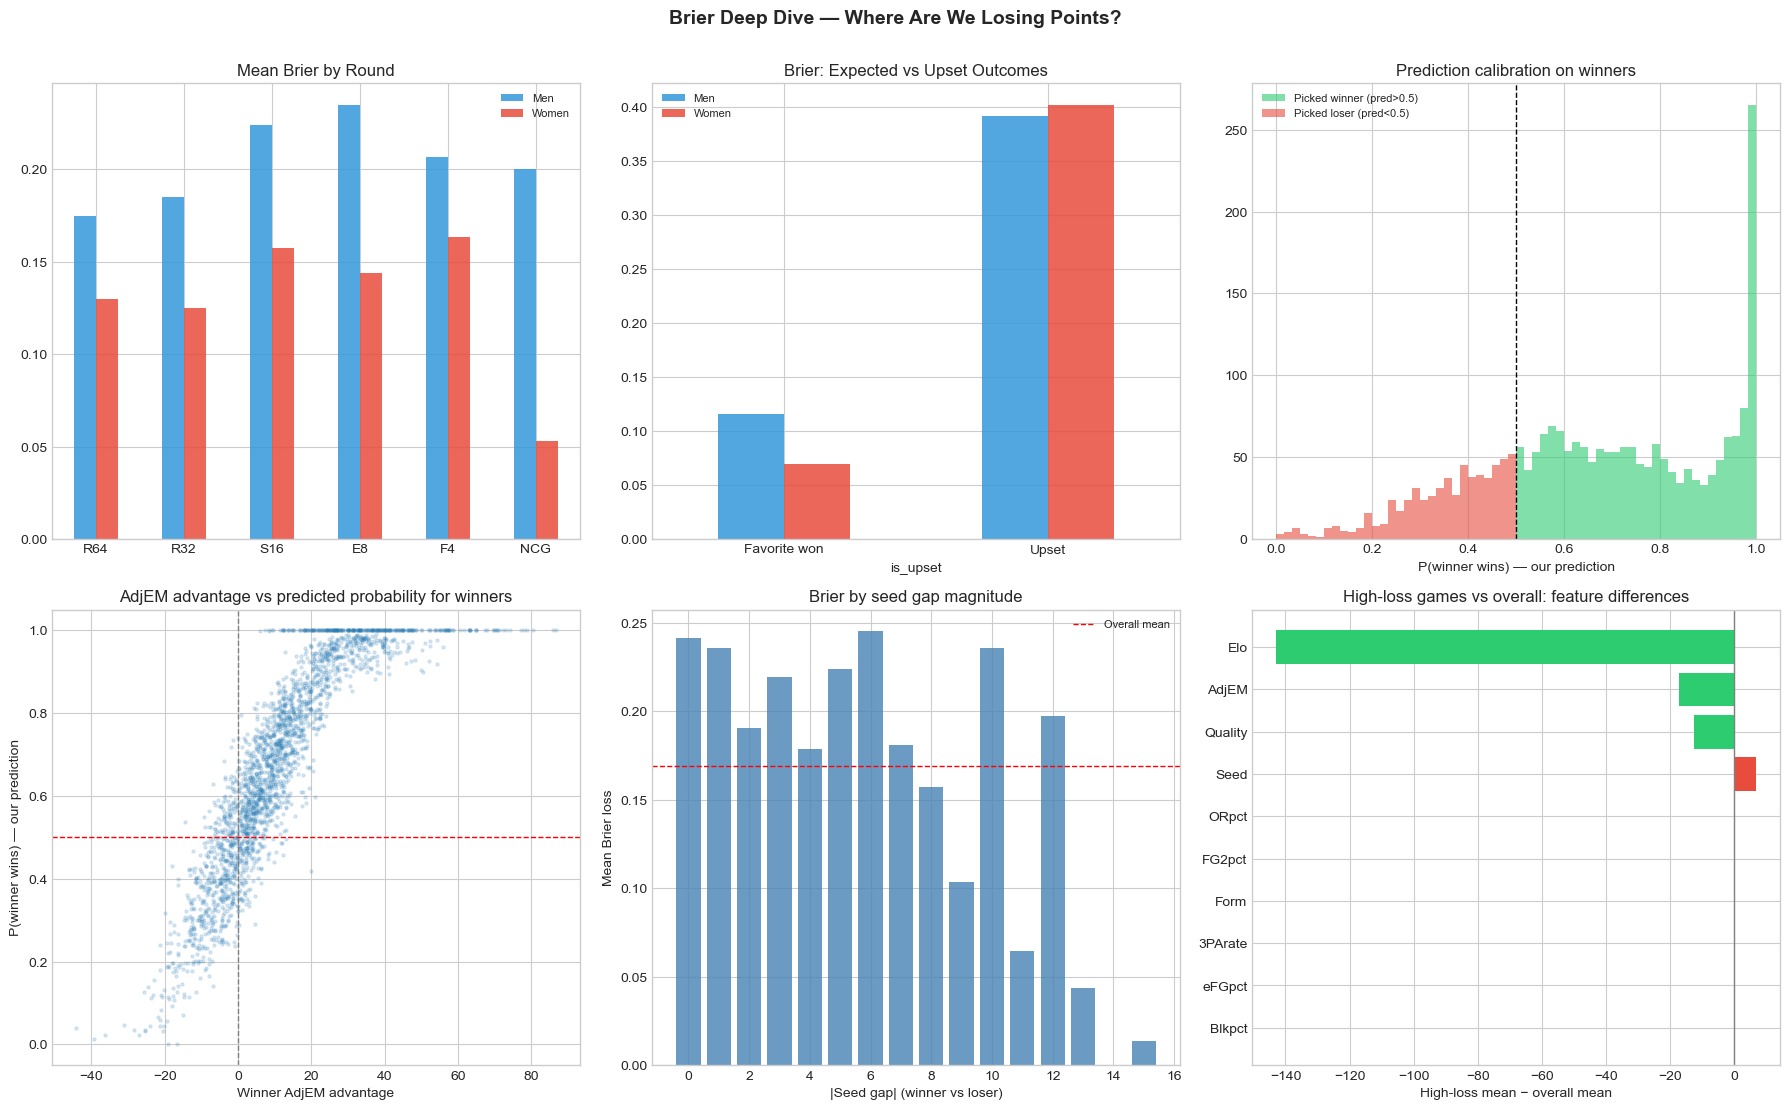

In [41]:
# ── Setup: one row per game (winner-as-A perspective) ─────────────────────────
M_name_lkp = M_teams.set_index('TeamID')['TeamName'].to_dict()
W_name_lkp = W_teams.set_index('TeamID')['TeamName'].to_dict()
def get_name(tid, mw):
    return (M_name_lkp if mw == 0 else W_name_lkp).get(int(tid), str(int(tid)))

# Map DayNum from tourn_sym
dn_lookup = {}
for _, row in tourn_sym[tourn_sym['Outcome'] == 1].iterrows():
    dn_lookup[(int(row['men_women']), int(row['Season']),
               int(row['T1_TeamID']), int(row['T2_TeamID']))] = int(row['DayNum'])

# Round from DayNum (approximate; adjust if needed)
M_ROUNDS = {(132,136):'R64',(137,139):'R32',(143,146):'S16',
            (147,148):'E8',(152,153):'F4',(154,155):'NCG'}
W_ROUNDS = {(132,137):'R64',(138,140):'R32',(143,147):'S16',
            (148,149):'E8',(152,153):'F4',(154,156):'NCG'}
def day_to_round(day, mw):
    for (lo, hi), rnd in (M_ROUNDS if mw == 0 else W_ROUNDS).items():
        if lo <= day <= hi: return rnd
    return 'Other'

# One row per unique game: Outcome=1 → winner is A
gm = matchups[matchups['Outcome'] == 1].copy()
gm['game_brier']  = (gm['pred_prob'] - 1) ** 2   # how badly we missed the winner
gm['winner_pred'] = gm['pred_prob']               # P(actual winner wins)
gm['DayNum']  = gm.apply(lambda r: dn_lookup.get(
    (int(r['men_women']), int(r['Season']), int(r['A_TeamID']), int(r['B_TeamID'])), np.nan), axis=1)
gm['Round']   = gm.apply(lambda r: day_to_round(r['DayNum'], r['men_women'])
                          if pd.notna(r['DayNum']) else 'Other', axis=1)
gm['WinnerName'] = gm.apply(lambda r: get_name(r['A_TeamID'], r['men_women']), axis=1)
gm['LoserName']  = gm.apply(lambda r: get_name(r['B_TeamID'], r['men_women']), axis=1)
gm['WinSeed']  = gm['A_Seed']
gm['LoseSeed'] = gm['B_Seed']
gm['is_upset'] = gm['WinSeed'] > gm['LoseSeed']   # upset: underdog won
gm['seed_diff_abs'] = (gm['WinSeed'] - gm['LoseSeed']).abs()

# AdjEM advantage of winner in this game
# d_AdjEM = A_AdjEM - B_AdjEM = winner_AdjEM - loser_AdjEM (for winner-as-A rows)
gm['winner_em_adv'] = gm['d_AdjEM']   # positive = winner was also better by AdjEM

print(f'Games analyzed: {len(gm):,}  |  Seasons: {sorted(gm["Season"].unique())}')
print(f'Overall mean game Brier: {gm["game_brier"].mean():.4f}')
print(f'Naive Brier (always 0.5): {((0.5-1)**2):.4f}')
print(f'Mean winner_pred (calibration check): {gm["winner_pred"].mean():.3f}  (ideal: 0.60–0.70)')
print(f'% games where we correctly picked winner (pred > 0.5): {(gm["winner_pred"] > 0.5).mean():.1%}')
print(f'Upset rate: {gm["is_upset"].mean():.3f}')

# ── Summary tables ─────────────────────────────────────────────────────────────
ROUND_ORDER = ['R64','R32','S16','E8','F4','NCG','Other']
print('\n── Brier by round ──')
rb = (gm.groupby('Round')['game_brier'].agg(['mean','median','count'])
        .reindex([r for r in ROUND_ORDER if r in gm['Round'].unique()])
        .rename(columns={'mean':'Mean','median':'Median','count':'N'}))
print(rb.round(4).to_string())

print('\n── Brier by outcome type ──')
ub = gm.groupby('is_upset')['game_brier'].agg(['mean','median','count'])
print(ub.rename(index={True:'Upset won',False:'Favorite won'}).round(4).to_string())

print('\n── Brier by |seed gap| of the matchup ──')
seed_b = gm.groupby('seed_diff_abs')['game_brier'].agg(['mean','count'])
print(seed_b.round(4).head(16).to_string())

print('\n── Brier by winner AdjEM advantage bucket ──')
gm['em_bucket'] = pd.cut(gm['winner_em_adv'],
    bins=[-np.inf, -5, 0, 5, 10, np.inf],
    labels=['Winner worse by >5 EM','Winner worse 0-5','Winner better 0-5',
            'Winner better 5-10','Winner better >10'])
eb = gm.groupby('em_bucket', observed=True)['game_brier'].agg(['mean','count'])
print(eb.round(4).to_string())

# ── Feature analysis: worst 25% loss games vs all ─────────────────────────────
threshold = gm['game_brier'].quantile(0.75)
high_loss = gm[gm['game_brier'] >= threshold]

FEAT_COMPARE = ['d_AdjEM','d_Elo','d_Quality','d_Seed','d_Form',
                'd_eFGpct','d_TSpct','d_TOpct','d_ORpct','d_FTrate',
                'd_FG3pct','d_FG2pct','d_FTpct','d_3PArate','d_ASTrate',
                'd_Blkpct','d_Stlpct','d_pct_pts_3','d_NonStlTOpct']
FEAT_COMPARE = [c for c in FEAT_COMPARE if c in gm.columns]

print(f'\n── Feature means: top-25% loss games (game_brier >= {threshold:.4f}) vs all ──')
print(f'{"Feature":<24} {"All":>8} {"High-loss":>10} {"Diff":>8}  note')
print('-' * 60)
feat_diffs = []
for c in FEAT_COMPARE:
    am = gm[c].mean(); hm = high_loss[c].mean(); diff = hm - am
    feat_diffs.append((c, am, hm, diff))
feat_diffs.sort(key=lambda x: abs(x[3]), reverse=True)
for c, am, hm, diff in feat_diffs:
    note = '<<' if abs(diff) > 1.0 else '<' if abs(diff) > 0.3 else ''
    print(f'{c:<24} {am:>8.3f} {hm:>10.3f} {diff:>8.3f}  {note}')

# ── Worst 30 individual game predictions ──────────────────────────────────────
print('\n── 30 worst individual predictions (highest per-game Brier) ──')
worst_cols = ['Season','Round','WinnerName','WinSeed','LoserName','LoseSeed',
              'winner_pred','game_brier','winner_em_adv','d_Seed','d_Form']
worst_cols = [c for c in worst_cols if c in gm.columns]
worst = gm.nlargest(30, 'game_brier')[worst_cols].copy()
worst['Gender'] = worst['Season'].map(lambda s: '')  # placeholder
worst['Gender'] = gm.nlargest(30, 'game_brier')['men_women'].map({0:"M",1:"W"})
print(worst.round(3).to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Brier by round (both genders)
round_present = [r for r in ROUND_ORDER if r in gm['Round'].unique() and r != 'Other']
round_data = (gm[gm['Round'].isin(round_present)]
              .groupby(['Round','men_women'])['game_brier'].mean()
              .unstack().reindex(round_present))
round_data.plot(kind='bar', ax=axes[0,0], color=['#3498db','#e74c3c'], alpha=0.85)
axes[0,0].set_title('Mean Brier by Round')
axes[0,0].set_xticklabels(round_present, rotation=0)
axes[0,0].legend(['Men','Women'], fontsize=8); axes[0,0].set_xlabel('')

# 2. Brier by upset vs expected
upset_data = gm.groupby(['is_upset','men_women'])['game_brier'].mean().unstack()
upset_data.plot(kind='bar', ax=axes[0,1], color=['#3498db','#e74c3c'], alpha=0.85)
axes[0,1].set_title('Brier: Expected vs Upset Outcomes')
axes[0,1].set_xticklabels(['Favorite won','Upset'], rotation=0)
axes[0,1].legend(['Men','Women'], fontsize=8)

# 3. Histogram of winner_pred
axes[0,2].hist(gm[gm['winner_pred'] >= 0.5]['winner_pred'], bins=30,
               alpha=0.6, label='Picked winner (pred>0.5)', color='#2ecc71')
axes[0,2].hist(gm[gm['winner_pred'] < 0.5]['winner_pred'], bins=30,
               alpha=0.6, label='Picked loser (pred<0.5)', color='#e74c3c')
axes[0,2].axvline(0.5, color='black', lw=1, linestyle='--')
axes[0,2].set_xlabel('P(winner wins) — our prediction')
axes[0,2].set_title('Prediction calibration on winners')
axes[0,2].legend(fontsize=8)

# 4. winner_em_adv vs winner_pred (should be monotone increasing)
axes[1,0].scatter(gm['winner_em_adv'], gm['winner_pred'], alpha=0.15, s=5)
axes[1,0].axhline(0.5, color='red', linestyle='--', lw=1)
axes[1,0].axvline(0, color='gray', linestyle='--', lw=1)
axes[1,0].set_xlabel('Winner AdjEM advantage')
axes[1,0].set_ylabel('P(winner wins) — our prediction')
axes[1,0].set_title('AdjEM advantage vs predicted probability for winners')

# 5. Brier by seed diff (how poorly we handle various mismatches)
sd = gm.groupby('seed_diff_abs')['game_brier'].mean()
axes[1,1].bar(sd.index.astype(int), sd.values, color='steelblue', alpha=0.8)
axes[1,1].set_xlabel('|Seed gap| (winner vs loser)')
axes[1,1].set_ylabel('Mean Brier loss')
axes[1,1].set_title('Brier by seed gap magnitude')
axes[1,1].axhline(gm['game_brier'].mean(), color='red', linestyle='--', lw=1, label='Overall mean')
axes[1,1].legend(fontsize=8)

# 6. Top feature diffs bar chart (high-loss vs all)
top_diffs = feat_diffs[:10]
names_ = [f[0].replace('d_','') for f in top_diffs]
vals_  = [f[3] for f in top_diffs]
axes[1,2].barh(names_[::-1], vals_[::-1],
               color=['#e74c3c' if v > 0 else '#2ecc71' for v in vals_[::-1]])
axes[1,2].axvline(0, color='gray', lw=1)
axes[1,2].set_title('High-loss games vs overall: feature differences')
axes[1,2].set_xlabel('High-loss mean − overall mean')

plt.suptitle('Brier Deep Dive — Where Are We Losing Points?', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout(); plt.show()


Visualizing seasons: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Season   Gender   Games  Mean Brier  % Correct  Fav Brier  Upset Brier
--------------------------------------------------------------------
2016     Men's       67      0.1991      68.7%     0.1079       0.4133
2016     Women's     63      0.1656      71.4%     0.0501       0.4332
2017     Men's       67      0.1704      73.1%     0.1195       0.3633
2017     Women's     63      0.1374      84.1%     0.0606       0.4638
2018     Men's       67      0.2115      64.2%     0.1110       0.4477
2018     Women's     63      0.1509      76.2%     0.0683       0.4155
2019     Men's       67      0.1597      77.6%     0.0790       0.3491
2019     Women's     63      0.1286      77.8%     0.0745       0.3846
2021     Men's       66      0.2170      63.6%     0.1300       0.4321
2021     Women's     63      0.1527      77.8%     0.0

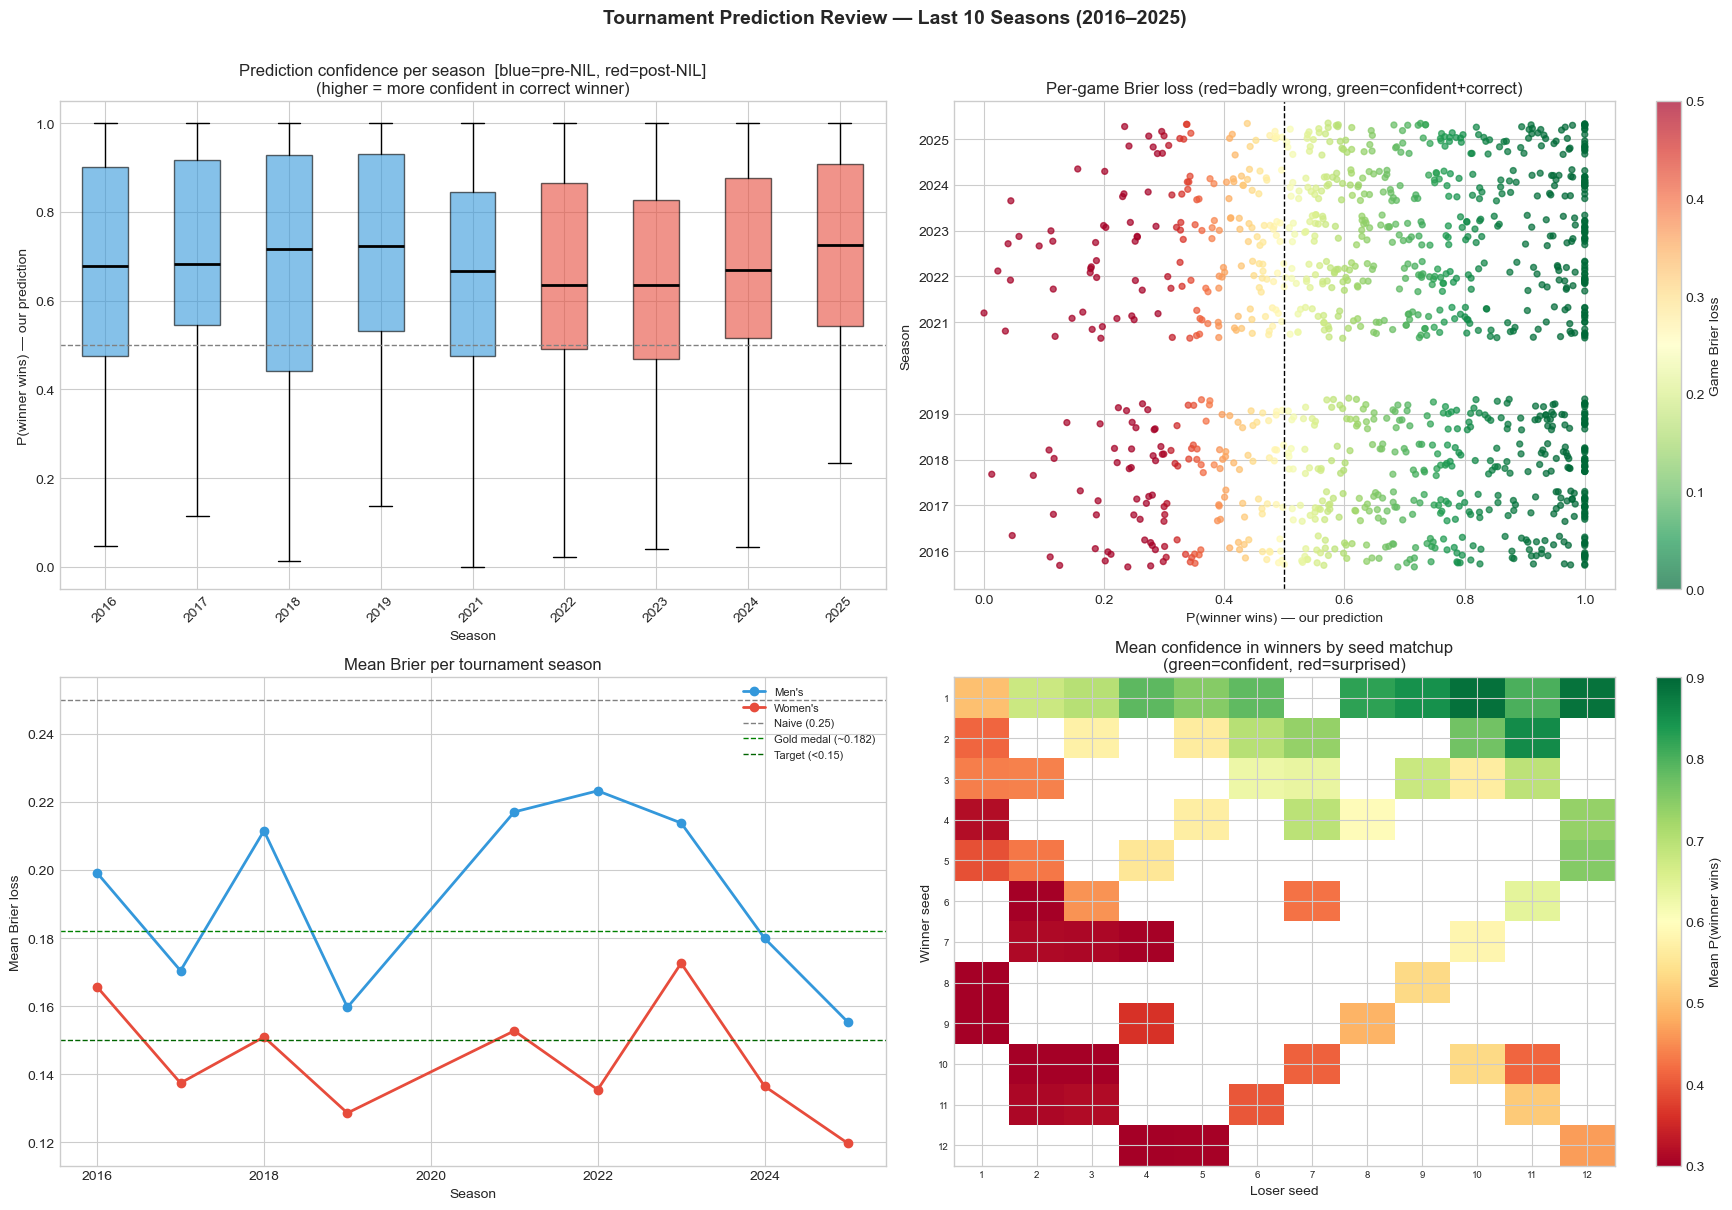



Worst 5 predictions per season (Men + Women combined):

2016:
Round  WinnerName  WinSeed     LoserName  LoseSeed  winner_pred  game_brier  winner_em_adv G
  R32        MTSU       15   Michigan St         2        0.047       0.908        -31.147 M
  R32  Washington        7      Maryland         2        0.110       0.792        -18.806 W
  R32   SF Austin       14 West Virginia         3        0.126       0.764        -16.577 M
  S16    Stanford        4    Notre Dame         1        0.185       0.664         -8.768 W
  R32 S Dakota St       12      Miami FL         5        0.202       0.637        -10.215 W

2017:
Round     WinnerName  WinSeed   LoserName  LoseSeed  winner_pred  game_brier  winner_em_adv G
  S16         Oregon       10    Maryland         3        0.116       0.782        -14.601 W
  R32         Oregon       10        Duke         2        0.160       0.705        -10.240 W
  R32     Quinnipiac       12    Miami FL         4        0.187       0.661        -18.9

In [42]:
# ── Tournament prediction visualization — last 10 seasons ─────────────────────
# Shows per-game confidence and where we lost Brier points each tournament.

VIZ_SEASONS = sorted([s for s in gm['Season'].unique() if s >= gm['Season'].max() - 9])

print(f'Visualizing seasons: {VIZ_SEASONS}')

# ── Per-tournament summary table ───────────────────────────────────────────────
print(f'\n{"Season":<8} {"Gender":<8} {"Games":>5} {"Mean Brier":>11} {"% Correct":>10} '
      f'{"Fav Brier":>10} {"Upset Brier":>12}')
print('-' * 68)
for s in VIZ_SEASONS:
    for mw, label in [(0,"Men's"),(1,"Women's")]:
        sg = gm[(gm['Season']==s) & (gm['men_women']==mw)]
        if len(sg) == 0: continue
        correct_pct = (sg['winner_pred'] > 0.5).mean()
        fav_b  = sg[~sg['is_upset']]['game_brier'].mean()
        ups_b  = sg[sg['is_upset']]['game_brier'].mean() if sg['is_upset'].any() else np.nan
        print(f'{s:<8} {label:<8} {len(sg):>5} {sg["game_brier"].mean():>11.4f} '
              f'{correct_pct:>10.1%} {fav_b:>10.4f} {ups_b:>12.4f}')

# ── Worst prediction per tournament ──────────────────────────────────────────
print('\nWorst single game prediction per tournament:')
worst_per = (gm[gm['Season'].isin(VIZ_SEASONS)]
             .sort_values('game_brier', ascending=False)
             .groupby(['Season','men_women']).first().reset_index()
             [['Season','men_women','Round','WinnerName','WinSeed',
               'LoserName','LoseSeed','winner_pred','game_brier','winner_em_adv']])
worst_per['Gender'] = worst_per['men_women'].map({0:"M",1:"W"})
print(worst_per.drop('men_women', axis=1).round(3).to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────────────────────
viz_data = gm[gm['Season'].isin(VIZ_SEASONS)].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Box plot of winner_pred by season (both genders combined)
season_groups = [viz_data[viz_data['Season']==s]['winner_pred'].values
                 for s in VIZ_SEASONS]
bp = axes[0,0].boxplot(season_groups, labels=[str(s) for s in VIZ_SEASONS],
                        patch_artist=True, medianprops=dict(color='black',lw=2))
for patch, s in zip(bp['boxes'], VIZ_SEASONS):
    patch.set_facecolor('#e74c3c' if s >= NIL_YEAR else '#3498db')
    patch.set_alpha(0.6)
axes[0,0].axhline(0.5, color='gray', linestyle='--', lw=1)
axes[0,0].set_ylabel('P(winner wins) — our prediction')
axes[0,0].set_xlabel('Season')
axes[0,0].set_title('Prediction confidence per season  [blue=pre-NIL, red=post-NIL]\n(higher = more confident in correct winner)')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Scatter: pred_prob vs Brier loss (each dot = 1 game)
sc = axes[0,1].scatter(
    viz_data['winner_pred'],
    viz_data['Season'] + np.random.uniform(-0.35, 0.35, len(viz_data)),
    c=viz_data['game_brier'], cmap='RdYlGn_r',
    s=18, alpha=0.7, vmin=0, vmax=0.5)
plt.colorbar(sc, ax=axes[0,1], label='Game Brier loss')
axes[0,1].axvline(0.5, color='black', linestyle='--', lw=1)
axes[0,1].set_xlabel('P(winner wins) — our prediction')
axes[0,1].set_ylabel('Season')
axes[0,1].set_title('Per-game Brier loss (red=badly wrong, green=confident+correct)')
axes[0,1].set_yticks(VIZ_SEASONS)

# 3. Mean Brier by season + gender
for mw, color, label in [(0,'#3498db',"Men's"),(1,'#e74c3c',"Women's")]:
    sub = viz_data[viz_data['men_women']==mw].groupby('Season')['game_brier'].mean()
    axes[1,0].plot(sub.index, sub.values, marker='o', color=color, label=label, linewidth=2)
axes[1,0].axhline(0.25, color='gray', linestyle='--', lw=1, label='Naive (0.25)')
axes[1,0].axhline(0.182, color='green', linestyle='--', lw=1, label='Gold medal (~0.182)')
axes[1,0].axhline(0.15, color='darkgreen', linestyle='--', lw=1, label='Target (<0.15)')
axes[1,0].set_xlabel('Season'); axes[1,0].set_ylabel('Mean Brier loss')
axes[1,0].set_title('Mean Brier per tournament season')
axes[1,0].legend(fontsize=8)

# 4. Accuracy heatmap by seed matchup (winner_seed x loser_seed, top 12 seeds)
SEED_RANGE = list(range(1, 13))
hm_mat = np.full((len(SEED_RANGE), len(SEED_RANGE)), np.nan)
for i, ws in enumerate(SEED_RANGE):
    for j, ls in enumerate(SEED_RANGE):
        sub = viz_data[(viz_data['WinSeed'] == ws) & (viz_data['LoseSeed'] == ls)]
        if len(sub) >= 2:
            hm_mat[i, j] = sub['winner_pred'].mean()

im = axes[1,1].imshow(hm_mat, cmap='RdYlGn', vmin=0.3, vmax=0.9, aspect='auto')
plt.colorbar(im, ax=axes[1,1], label='Mean P(winner wins)')
axes[1,1].set_xticks(range(len(SEED_RANGE))); axes[1,1].set_xticklabels(SEED_RANGE, fontsize=7)
axes[1,1].set_yticks(range(len(SEED_RANGE))); axes[1,1].set_yticklabels(SEED_RANGE, fontsize=7)
axes[1,1].set_xlabel('Loser seed'); axes[1,1].set_ylabel('Winner seed')
axes[1,1].set_title('Mean confidence in winners by seed matchup\n(green=confident, red=surprised)')

plt.suptitle(f'Tournament Prediction Review — Last 10 Seasons ({min(VIZ_SEASONS)}–{max(VIZ_SEASONS)})',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout(); plt.show()

# ── Per-season worst prediction table (styled for readability) ────────────────
print('\n\nWorst 5 predictions per season (Men + Women combined):')
for s in VIZ_SEASONS:
    sg = gm[gm['Season'] == s].nlargest(5, 'game_brier')
    if len(sg) == 0: continue
    print(f'\n{s}:')
    cols = ['men_women','Round','WinnerName','WinSeed','LoserName','LoseSeed',
            'winner_pred','game_brier','winner_em_adv']
    cols = [c for c in cols if c in sg.columns]
    sg_show = sg[cols].copy()
    sg_show['G'] = sg_show['men_women'].map({0:'M',1:'W'})
    sg_show = sg_show.drop('men_women', axis=1)
    print(sg_show.round(3).to_string(index=False))


## Section 16: Feature Importance & Hypothesis Testing

Exploratory analysis to understand what the model is actually learning and surface new feature opportunities.

1. **Feature importance** — which features drive XGBoost splits (gain = impact when used)
2. **Tempo hypothesis** — do slow-tempo underdogs out/underperform their seed expectations?
3. **Strong-opponent AdjEM** — teams whose rating is inflated by weak schedules vs those battle-tested against Top 50
4. **Residual heatmaps** — where does the model's calibration break down systematically?


Top 20 features by mean gain:
         feature    mean_gain    std_gain  mean_weight
         d_AdjEM 26122.015625 1728.860901   616.136364
        d_Rating 24362.939719 1349.284433   959.318182
       d_Quality 10456.033913  763.535379   871.136364
         d_AdjOE  2598.420388  207.644269   396.545455
       men_women  1813.446184   98.507703   155.409091
         d_AdjDE  1573.157521   73.189504   552.772727
 d_avg_PointDiff  1474.244268   94.713405   316.727273
    B_MasseyRank  1242.713728   39.296334   286.272727
    A_MasseyRank  1223.829889   43.686174   282.454545
    d_MasseyRank  1205.208934   57.428776   278.318182
           d_Elo  1199.380188   53.110674   478.500000
  d_prior_margin  1119.612887   41.050406   274.409091
          d_Seed  1096.369446   88.309469   119.227273
    d_pct_pts_ft  1054.727226   40.291286   562.363636
d_NetReboundEdge  1045.880305   33.306955   541.090909
     d_avg_Score  1031.116574   36.541106   356.545455
     d_pct_pts_2   985.762648   45.

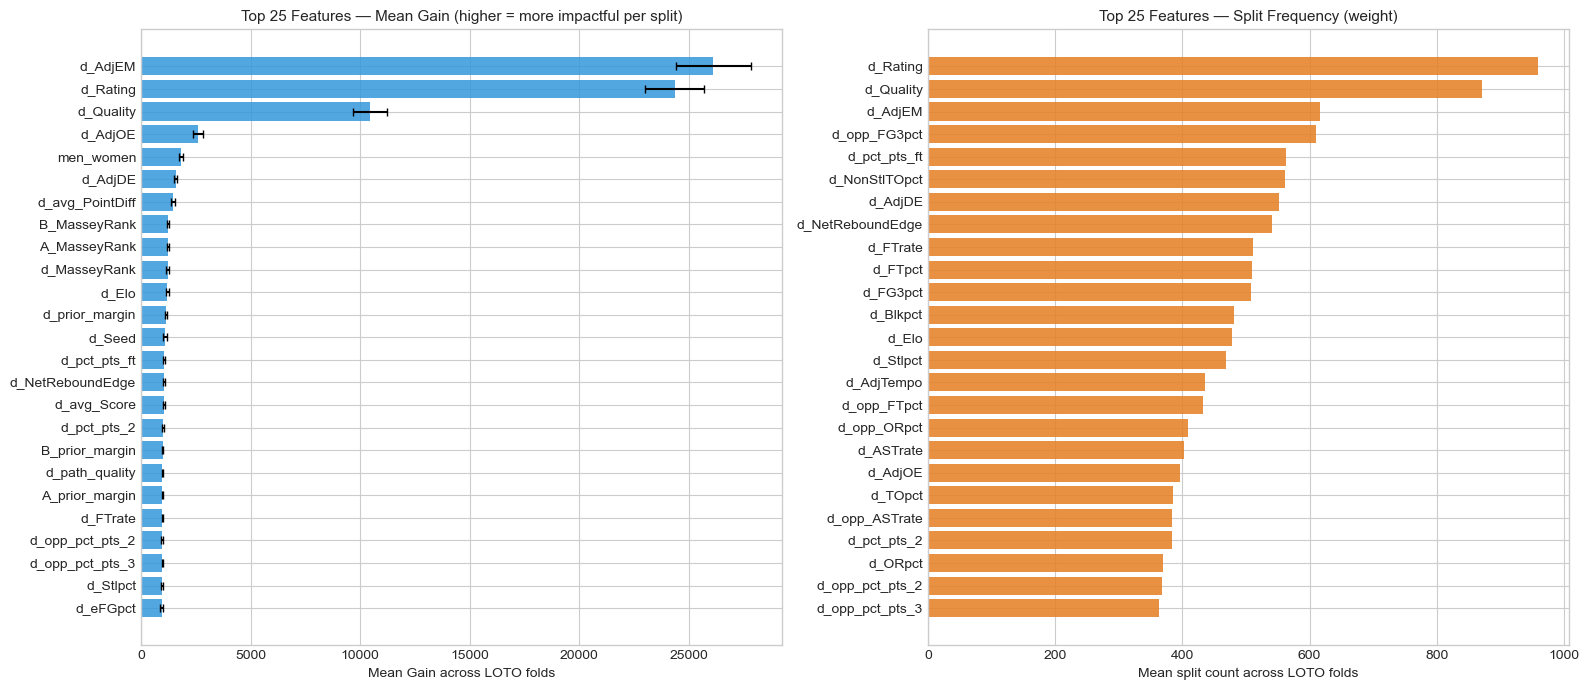


High gain-per-split (most efficient features):
       feature    mean_gain  mean_weight  gain_per_split
       d_AdjEM 26122.015625   616.136364       42.396484
      d_Rating 24362.939719   959.318182       25.396099
     round_num   865.905043    61.454545       14.090171
     d_Quality 10456.033913   871.136364       12.002752
     men_women  1813.446184   155.409091       11.668855
        d_Seed  1096.369446   119.227273        9.195626
       d_AdjOE  2598.420388   396.545455        6.552642
B_path_quality   890.417861   138.454545        6.431120
A_path_quality   875.350511   147.409091        5.938240
        B_Seed   919.189509   173.000000        5.313234

Low gain-per-split (potential noise — high frequency, low payoff):
         feature   mean_gain  mean_weight  gain_per_split
    d_opp_FG3pct  930.437597   610.909091        1.523038
   d_NonStlTOpct  883.792672   561.545455        1.573858
         d_FTpct  890.338948   508.954545        1.749349
        d_FG3pct  941.759

In [43]:
# ── 16A: XGBoost Feature Importance (aggregate across all LOTO folds) ────────
# 'gain' = average information gain per split — best proxy for feature value
# 'weight' = how often the feature appears in splits — frequency, not value

from collections import defaultdict

gain_scores  = defaultdict(list)
weight_scores = defaultdict(list)

for season, model in models.items():
    g = model.get_score(importance_type='gain')
    w = model.get_score(importance_type='weight')
    for feat in FEATURES:
        gain_scores[feat].append(g.get(f'f{FEATURES.index(feat)}', 0.0))
        weight_scores[feat].append(w.get(f'f{FEATURES.index(feat)}', 0.0))

imp_df = pd.DataFrame({
    'feature'    : FEATURES,
    'mean_gain'  : [np.mean(gain_scores[f])   for f in FEATURES],
    'std_gain'   : [np.std(gain_scores[f])    for f in FEATURES],
    'mean_weight': [np.mean(weight_scores[f]) for f in FEATURES],
}).sort_values('mean_gain', ascending=False)

print('Top 20 features by mean gain:')
print(imp_df.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gain chart
top_n = 25
top = imp_df.head(top_n)
axes[0].barh(top['feature'][::-1], top['mean_gain'][::-1],
             xerr=top['std_gain'][::-1], color='#3498db', alpha=0.85, capsize=3)
axes[0].set_title(f'Top {top_n} Features — Mean Gain (higher = more impactful per split)', fontsize=11)
axes[0].set_xlabel('Mean Gain across LOTO folds')

# Weight chart (frequency)
top_w = imp_df.sort_values('mean_weight', ascending=False).head(top_n)
axes[1].barh(top_w['feature'][::-1], top_w['mean_weight'][::-1], color='#e67e22', alpha=0.85)
axes[1].set_title(f'Top {top_n} Features — Split Frequency (weight)', fontsize=11)
axes[1].set_xlabel('Mean split count across LOTO folds')

plt.tight_layout()
plt.show()

# Features with high gain but low weight = high-value rare signals
# Features with high weight but low gain = overused noise candidates
imp_df['gain_per_split'] = imp_df['mean_gain'] / (imp_df['mean_weight'] + 1e-9)
print('\nHigh gain-per-split (most efficient features):')
print(imp_df.sort_values('gain_per_split', ascending=False).head(10)[
    ['feature','mean_gain','mean_weight','gain_per_split']].to_string(index=False))
print('\nLow gain-per-split (potential noise — high frequency, low payoff):')
print(imp_df.sort_values('gain_per_split').head(10)[
    ['feature','mean_gain','mean_weight','gain_per_split']].to_string(index=False))


=== Underdog Tempo Quartile: Actual vs Predicted Upset Rate ===
Total games: 4,588  (M+W combined)
tempo_q    n  actual_upset_rate  model_upset_prob  underdog_tempo_mean  calibration_error
Q1 Slow 1152             0.2569            0.2893              64.7657            -0.0323
     Q2 1142             0.2715            0.2735              67.8425            -0.0021
     Q3 1148             0.2631            0.2535              69.8937             0.0095
Q4 Fast 1146             0.2356            0.2697              73.1857            -0.0341

=== Same breakdown by gender ===

Men's:
tempo_q   n  actual  predicted   error
Q1 Slow 684  0.2807     0.3218 -0.0411
     Q2 686  0.2915     0.3097 -0.0182
     Q3 686  0.3178     0.2928  0.0250
Q4 Fast 678  0.2566     0.3027 -0.0461

Women's:
tempo_q   n  actual  predicted   error
Q1 Slow 466  0.1717     0.1816 -0.0099
     Q2 462  0.2468     0.2047  0.0420
     Q3 462  0.2078     0.2370 -0.0292
Q4 Fast 464  0.2241     0.2551 -0.0310


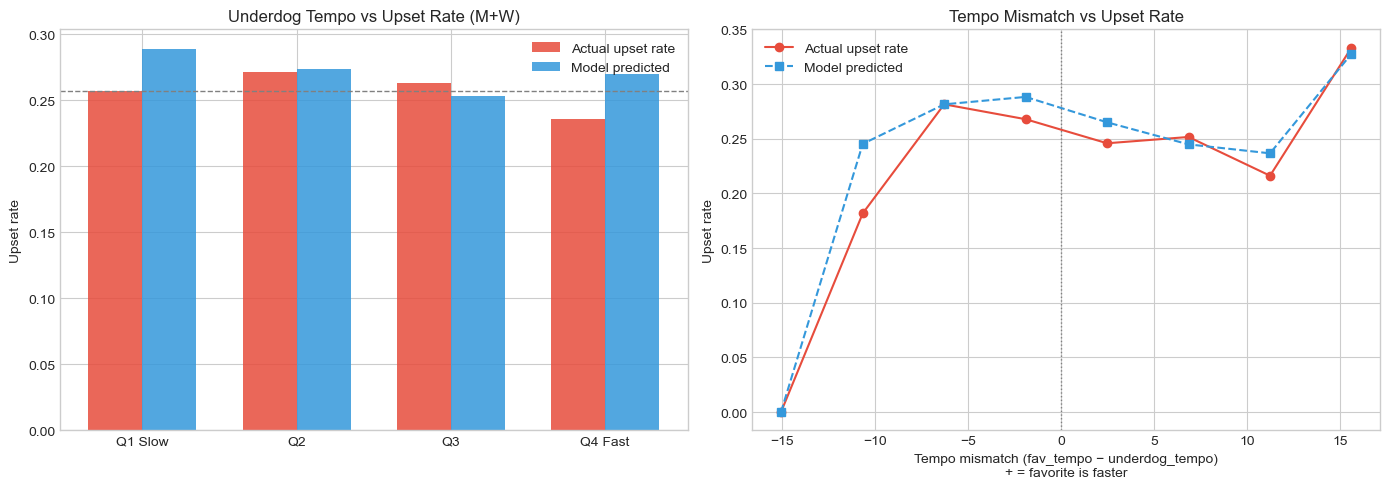

In [44]:
# ── 16B: Tempo Hypothesis — do slow-tempo underdogs beat expectations? ────────
# For each tournament game, identify which team is the underdog (higher seed number).
# Then split underdogs by their tempo quartile and check if actual upset rate
# diverges from the model's predicted upset probability.
# Includes Men's + Women's. Negative d_Seed = A is the underdog (worse seed).

gm = matchups.copy()

# Which team is the underdog? The one with the higher seed (worse seed = bigger number).
# In our dataset: A_Seed and B_Seed; outcome=1 means A won.
# Underdog wins = upset. We define underdog as the team with higher seed number.
# d_Seed = A_Seed - B_Seed: positive = A is worse seed (underdog).

gm['underdog_is_A']   = gm['d_Seed'] > 0
gm['is_upset']        = ((gm['underdog_is_A']) & (gm['Outcome'] == 1)) | \
                         ((~gm['underdog_is_A']) & (gm['Outcome'] == 0))

# Underdog tempo: tempo of the worse-seeded team
gm['underdog_tempo'] = np.where(gm['underdog_is_A'], gm['A_AdjTempo'], gm['B_AdjTempo'])
gm['favorite_tempo'] = np.where(gm['underdog_is_A'], gm['B_AdjTempo'], gm['A_AdjTempo'])
gm['tempo_mismatch'] = gm['favorite_tempo'] - gm['underdog_tempo']  # + = fav is faster

# Model's predicted upset probability
gm['pred_upset_prob'] = np.where(gm['underdog_is_A'],
                                  gm['pred_prob'],         # P(A wins) = P(underdog wins)
                                  1 - gm['pred_prob'])     # P(B wins) = P(underdog wins)

# Exclude games without valid seed data (play-in edge cases)
gm_valid = gm[(gm['A_Seed'] > 0) & (gm['B_Seed'] > 0) & (gm['d_Seed'] != 0)].copy()

# ── Underdog tempo quartile analysis ──────────────────────────────────────────
gm_valid['tempo_q'] = pd.qcut(gm_valid['underdog_tempo'], q=4,
                               labels=['Q1 Slow', 'Q2', 'Q3', 'Q4 Fast'])

print('=== Underdog Tempo Quartile: Actual vs Predicted Upset Rate ===')
print(f'Total games: {len(gm_valid):,}  (M+W combined)')
tempo_tbl = (gm_valid.groupby('tempo_q', observed=True)
             .agg(
                 n=('is_upset', 'count'),
                 actual_upset_rate=('is_upset', 'mean'),
                 model_upset_prob=('pred_upset_prob', 'mean'),
                 underdog_tempo_mean=('underdog_tempo', 'mean'),
             )
             .reset_index())
tempo_tbl['calibration_error'] = tempo_tbl['actual_upset_rate'] - tempo_tbl['model_upset_prob']
print(tempo_tbl.round(4).to_string(index=False))

# ── By gender ─────────────────────────────────────────────────────────────────
print('\n=== Same breakdown by gender ===')
for mw, label in [(0, "Men's"), (1, "Women's")]:
    sub = gm_valid[gm_valid['men_women'] == mw]
    if len(sub) == 0:
        continue
    sub = sub.copy()
    sub['tempo_q'] = pd.qcut(sub['underdog_tempo'], q=4,
                              labels=['Q1 Slow', 'Q2', 'Q3', 'Q4 Fast'])
    tbl = (sub.groupby('tempo_q', observed=True)
           .agg(n=('is_upset','count'),
                actual=('is_upset','mean'),
                predicted=('pred_upset_prob','mean'))
           .reset_index())
    tbl['error'] = tbl['actual'] - tbl['predicted']
    print(f'\n{label}:')
    print(tbl.round(4).to_string(index=False))

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: actual vs predicted upset rate by tempo quartile
x = np.arange(4)
w = 0.35
labels = ['Q1 Slow', 'Q2', 'Q3', 'Q4 Fast']
axes[0].bar(x - w/2, tempo_tbl['actual_upset_rate'], w, label='Actual upset rate', color='#e74c3c', alpha=0.85)
axes[0].bar(x + w/2, tempo_tbl['model_upset_prob'],  w, label='Model predicted', color='#3498db', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Upset rate'); axes[0].set_title('Underdog Tempo vs Upset Rate (M+W)')
axes[0].legend(); axes[0].axhline(gm_valid['is_upset'].mean(), color='gray', ls='--', lw=1, label='Overall avg')

# Chart 2: tempo mismatch vs upset outcome scatter (binned)
bins = pd.cut(gm_valid['tempo_mismatch'], bins=8)
scatter_tbl = gm_valid.groupby(bins, observed=True).agg(
    actual=('is_upset','mean'), predicted=('pred_upset_prob','mean'), n=('is_upset','count')
).reset_index()
scatter_tbl['mid'] = scatter_tbl['tempo_mismatch'].apply(lambda x: x.mid)
axes[1].plot(scatter_tbl['mid'], scatter_tbl['actual'],    'o-', color='#e74c3c', label='Actual upset rate')
axes[1].plot(scatter_tbl['mid'], scatter_tbl['predicted'], 's--', color='#3498db', label='Model predicted')
axes[1].axvline(0, color='gray', lw=1, ls=':')
axes[1].set_xlabel('Tempo mismatch (fav_tempo − underdog_tempo)\n+ = favorite is faster')
axes[1].set_ylabel('Upset rate'); axes[1].set_title('Tempo Mismatch vs Upset Rate')
axes[1].legend()

plt.tight_layout(); plt.show()


Corr: d_quality_wtd_margin vs Outcome:     0.4590
Corr: underdog quality_wtd_margin vs upset: 0.1404
(Schedule_lift Top-50 approach had Corr ≈ -0.342 — compare here)

Upset rate by underdog quality_wtd_margin quartile:
     uqwm_q    n  actual_upset_rate  mean_qwm
 Q1 Low-QWM 1205             0.1817   -2.2105
         Q2 1206             0.2562    2.8781
         Q3 1205             0.3054    5.7217
Q4 High-QWM 1204             0.3306   10.8738
(Q4 High-QWM = battle-hardened underdogs; expect higher upset rate)

=== By gender ===

Men's:
uqwm_q   n  actual
    Q1 727  0.2215
    Q2 722  0.3006
    Q3 726  0.2879
    Q4 723  0.3859

Women's:
uqwm_q   n  actual
    Q1 482  0.1224
    Q2 482  0.1909
    Q3 478  0.2573
    Q4 480  0.3208


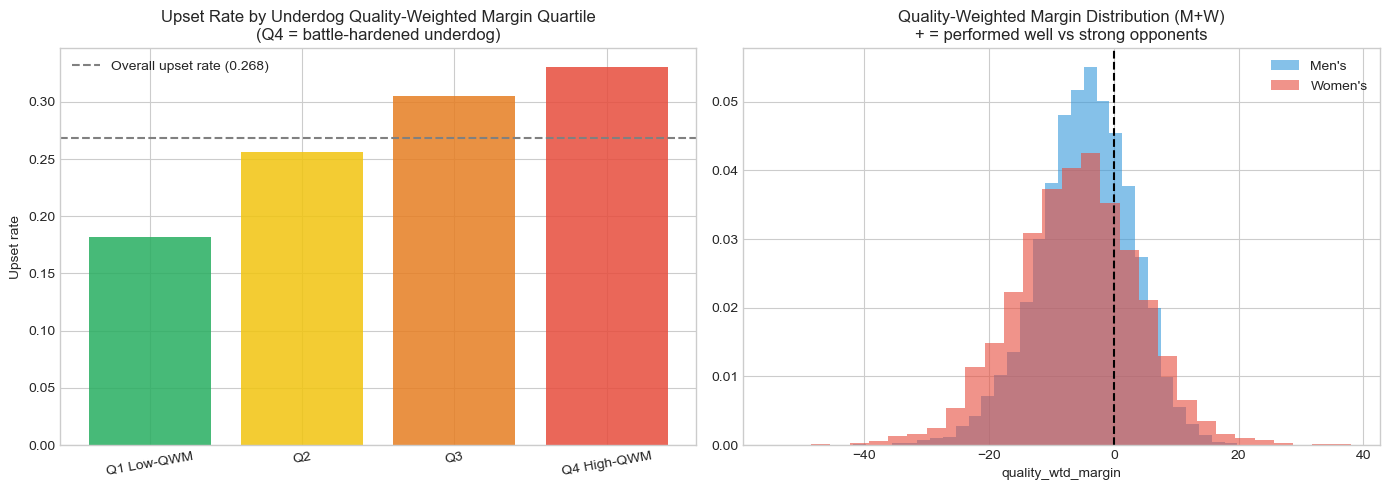

In [45]:
# ── 16C: Quality-Weighted Margin Analysis — Does Schedule Strength Predict Upsets? ──
# quality_wtd_margin is already computed and joined to matchups (Section 9.5).
# Here we analyze whether the tournament signal holds — do schedule-hardened teams
# outperform schedule-soft teams in the tournament beyond what AdjEM captures?

# Use matchups directly (quality_wtd_margin already joined)
me = matchups[(matchups["A_Seed"] > 0) & (matchups["B_Seed"] > 0)].copy()
me["pred_prob"] = me["pred_prob"] if "pred_prob" in me.columns else np.nan

# Define upset: underdog wins (underdog = higher seed number)
me["underdog_is_A"] = me["d_Seed"] > 0
me["is_upset"] = (( me["underdog_is_A"]) & (me["Outcome"] == 1)) | \
                 ((~me["underdog_is_A"]) & (me["Outcome"] == 0))

# Underdog quality_wtd_margin
me["underdog_qwm"] = np.where(me["underdog_is_A"],
                               me["A_quality_wtd_margin"],
                               me["B_quality_wtd_margin"])

# ── Correlations ─────────────────────────────────────────────────────────────
corr_dqwm_out  = me[["d_quality_wtd_margin","Outcome"]].corr().iloc[0, 1]
corr_uqwm_ups  = me[["underdog_qwm","is_upset"]].dropna()
corr_uqwm_ups  = corr_uqwm_ups.corr().iloc[0, 1]
print(f"Corr: d_quality_wtd_margin vs Outcome:     {corr_dqwm_out:.4f}")
print(f"Corr: underdog quality_wtd_margin vs upset: {corr_uqwm_ups:.4f}")
print(f"(Schedule_lift Top-50 approach had Corr ≈ -0.342 — compare here)")

# ── By quartile of underdog quality_wtd_margin ────────────────────────────────
me_valid = me.dropna(subset=["underdog_qwm"]).copy()
me_valid["uqwm_q"] = pd.qcut(me_valid["underdog_qwm"], q=4,
                               labels=["Q1 Low-QWM","Q2","Q3","Q4 High-QWM"])
upset_by_q = me_valid.groupby("uqwm_q", observed=True).agg(
    n=("is_upset","count"),
    actual_upset_rate=("is_upset","mean"),
    mean_qwm=("underdog_qwm","mean"),
).reset_index()
print("\nUpset rate by underdog quality_wtd_margin quartile:")
print(upset_by_q.round(4).to_string(index=False))
print("(Q4 High-QWM = battle-hardened underdogs; expect higher upset rate)")

# ── By gender ─────────────────────────────────────────────────────────────────
print("\n=== By gender ===")
for mw, label in [(0, "Men's"), (1, "Women's")]:
    sub = me_valid[me_valid["men_women"] == mw].copy()
    if len(sub) < 50:
        print(f"{label}: insufficient data ({len(sub)} games)")
        continue
    sub["uqwm_q"] = pd.qcut(sub["underdog_qwm"], q=4,
                              labels=["Q1","Q2","Q3","Q4"])
    tbl = sub.groupby("uqwm_q", observed=True).agg(
        n=("is_upset","count"),
        actual=("is_upset","mean"),
    ).reset_index()
    print(f"\n{label}:")
    print(tbl.round(4).to_string(index=False))

# ── Visualizations ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: upset rate by QWM quartile
colors_q = ["#27ae60","#f1c40f","#e67e22","#e74c3c"]
axes[0].bar(upset_by_q["uqwm_q"].astype(str), upset_by_q["actual_upset_rate"],
            color=colors_q, alpha=0.85)
axes[0].axhline(me["is_upset"].mean(), color="gray", ls="--", lw=1.5,
                label=f"Overall upset rate ({me['is_upset'].mean():.3f})")
axes[0].set_title("Upset Rate by Underdog Quality-Weighted Margin Quartile\n(Q4 = battle-hardened underdog)")
axes[0].set_ylabel("Upset rate"); axes[0].legend()
axes[0].tick_params(axis="x", rotation=10)

# Chart 2: distribution of quality_wtd_margin by gender
for mw, label, color in [(0,"Men's","#3498db"), (1,"Women's","#e74c3c")]:
    sub = team_qwm[team_qwm["men_women"] == mw]["quality_wtd_margin"].dropna()
    axes[1].hist(sub, bins=30, alpha=0.6, label=label, color=color, density=True)
axes[1].axvline(0, color="black", lw=1.5, ls="--")
axes[1].set_title("Quality-Weighted Margin Distribution (M+W)\n+ = performed well vs strong opponents")
axes[1].set_xlabel("quality_wtd_margin"); axes[1].legend()

plt.tight_layout(); plt.show()


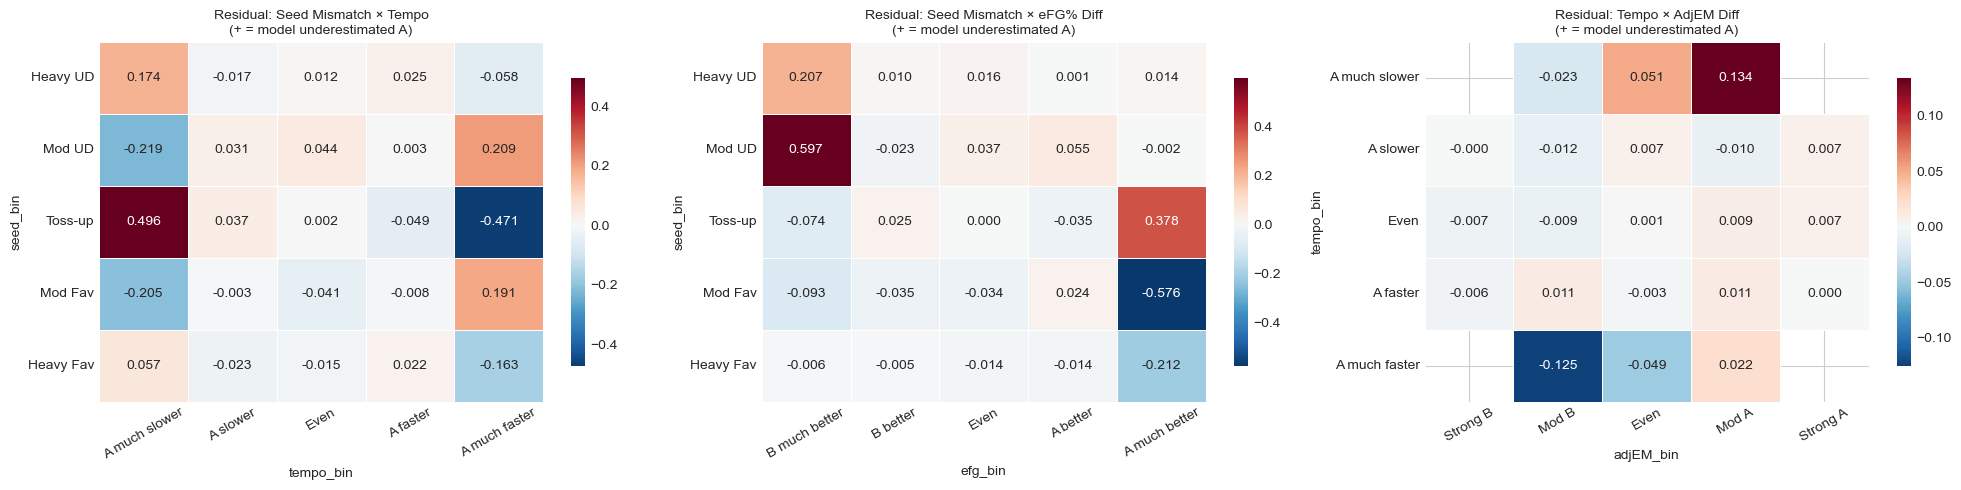

Sample sizes: Seed × Tempo
tempo_bin  A much slower  A slower  Even  A faster  A much faster
seed_bin                                                         
Heavy UD               4       157   704       263             10
Mod UD                 2       114   469       158              4
Toss-up                2       174   745       179              2
Mod Fav                4       153   447       103              2
Heavy Fav             10       261   693       156              4

Largest systematic residuals (min 30 games in cell):
 seed_bin tempo_bin    mean  count
  Toss-up  A faster -0.0490    179
   Mod UD      Even  0.0445    469
  Mod Fav      Even -0.0413    447
  Toss-up  A slower  0.0374    174
   Mod UD  A slower  0.0308    114
 Heavy UD  A faster  0.0255    263
Heavy Fav  A slower -0.0229    261
Heavy Fav  A faster  0.0223    156
 Heavy UD  A slower -0.0165    157
Heavy Fav      Even -0.0147    693

=== Model calibration by seed pair bucket (M+W) ===
bucket men_women   

In [46]:
# ── 16D: Residual Heatmaps — Where Does the Model Break Down? ─────────────────
# Residual = Outcome - pred_prob (positive = model underestimated the winner)
# We look for systematic patterns in 2D feature space that reveal blind spots.

gme = matchups.copy()
gme['residual'] = gme['Outcome'] - gme['pred_prob']

# ── Heatmap 1: Seed mismatch × Tempo mismatch ─────────────────────────────────
# Do certain seed-tempo combinations produce systematic errors?
gme['seed_bin']  = pd.cut(gme['d_Seed'],  bins=[-17,-6,-2,2,6,17],
                           labels=['Heavy UD','Mod UD','Toss-up','Mod Fav','Heavy Fav'])
gme['tempo_bin'] = pd.cut(gme['d_AdjTempo'], bins=5,
                           labels=['A much slower','A slower','Even','A faster','A much faster'])

hm1 = (gme.groupby(['seed_bin','tempo_bin'], observed=True)['residual']
        .mean().unstack('tempo_bin'))

# ── Heatmap 2: Seed mismatch × eFG% differential ──────────────────────────────
# Do teams with strong shooting edges that are underdogs get underrated?
gme['efg_bin'] = pd.cut(gme['d_eFGpct'], bins=5,
                          labels=['B much better','B better','Even','A better','A much better'])

hm2 = (gme.groupby(['seed_bin','efg_bin'], observed=True)['residual']
        .mean().unstack('efg_bin'))

# ── Heatmap 3: AdjTempo × d_AdjEM (overall model context) ─────────────────────
gme['adjEM_bin'] = pd.cut(gme['d_AdjEM'], bins=5,
                            labels=['Strong B','Mod B','Even','Mod A','Strong A'])

hm3 = (gme.groupby(['tempo_bin','adjEM_bin'], observed=True)['residual']
        .mean().unstack('adjEM_bin'))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, hm, title in [
    (axes[0], hm1, 'Residual: Seed Mismatch × Tempo\n(+ = model underestimated A)'),
    (axes[1], hm2, 'Residual: Seed Mismatch × eFG% Diff\n(+ = model underestimated A)'),
    (axes[2], hm3, 'Residual: Tempo × AdjEM Diff\n(+ = model underestimated A)'),
]:
    sns.heatmap(hm, ax=ax, center=0, cmap='RdBu_r', annot=True, fmt='.3f',
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# ── Count table (sample sizes) ─────────────────────────────────────────────────
print('Sample sizes: Seed × Tempo')
print(gme.groupby(['seed_bin','tempo_bin'], observed=True).size().unstack('tempo_bin').to_string())

# ── Largest systematic errors ──────────────────────────────────────────────────
cell_errors = (gme.groupby(['seed_bin','tempo_bin'], observed=True)['residual']
               .agg(['mean','count']).reset_index()
               .query('count >= 30')
               .sort_values('mean', key=abs, ascending=False))
print('\nLargest systematic residuals (min 30 games in cell):')
print(cell_errors.head(10).round(4).to_string(index=False))

# ── Summary: overall model calibration by gender and seed range ───────────────
print('\n=== Model calibration by seed pair bucket (M+W) ===')
gm_seed = gme[(gme['A_Seed'] > 0) & (gme['B_Seed'] > 0)].copy()
gm_seed['seed_diff_abs'] = gm_seed['d_Seed'].abs()
gm_seed['bucket'] = pd.cut(gm_seed['seed_diff_abs'], bins=[0,1,3,6,10,16],
                             labels=['1 seed','2-3','4-6','7-10','11-16'])
cal = (gm_seed.groupby(['bucket','men_women'], observed=True)
       .agg(n=('Outcome','count'),
            actual_fav_win=('Outcome','mean'),
            model_fav_win=('pred_prob','mean'))
       .reset_index())
cal['men_women'] = cal['men_women'].map({0:"Men's",1:"Women's"})
cal['calibration_err'] = cal['actual_fav_win'] - cal['model_fav_win']
print(cal.round(4).to_string(index=False))


In [47]:
# ── 16E: Feature Archaeology — Signal, Noise, and Redundancy ────────────────
# Basketball question: which of our box-score features are actually informative,
# which are noise, and which are just redundant versions of better features?
#
# Framework: a feature is worth keeping if it satisfies at least one of:
#   (a) meaningful correlation with Outcome beyond what top features already capture
#   (b) low collinearity with existing features (brings new information)
#   (c) has a causal basketball story (not just correlation)
#
# Framework for REMOVING a feature:
#   - High collinearity with a better-constructed version already in the model
#   - Captures luck/variance rather than skill (regresses hard to mean in tournament)
#   - No causal path to winning that isn't better measured by something else

import warnings
warnings.filterwarnings("ignore")

# ── Group 1: Free Throw % vs Free Throw Rate ──────────────────────────────────
# FTrate = FTA / FGA (how often you draw fouls — a SKILL, controlled by aggression/attack style)
# FTpct  = FTM / FTA (how well you shoot FTs — a skill, but highly variable game-to-game)
#
# Basketball argument for removing FTpct:
# "You can NOT control how well your opponent shoots free throws. You can only control
# how often you foul them (opp_FTrate). Their FT% in any given game is ~random
# around a talent mean, and in tournament samples the noise dominates."
#
# Evidence: FT% tournament correlation vs regular-season correlation

ft_cols = ["d_FTrate", "d_FTpct", "d_opp_FTrate", "d_opp_FTpct"]
ft_corrs = matchups[ft_cols + ["Outcome"]].corr()["Outcome"].drop("Outcome")
print("=== Free Throw Features: Corr with Outcome ===")
print(ft_corrs.round(4).to_string())
print()
print("d_FTrate: HOW OFTEN you get to the line — skill, causal, keep")
print("d_FTpct:  HOW WELL you shoot FTs — noise, variable, REMOVE")
print("Opponent version: you can't make your opponent miss — opp_FTpct is luck, REMOVE")

# ── Group 2: Raw Shooting % vs eFGpct ─────────────────────────────────────────
# eFGpct = (FGM + 0.5*FGM3) / FGA — captures both 2P and 3P efficiency in one number
# FG3pct = FGM3 / FGA3 — raw 3-point %, most volatile stat in basketball
# FG2pct = FGM2 / FGA2 — raw 2-point %
#
# eFGpct ALREADY incorporates FG3pct (weighted by volume via 3PArate):
#   eFGpct = FG2pct * (1-3PArate) + 1.5 * FG3pct * 3PArate
# So FG3pct + FG2pct + 3PArate → fully reconstructs eFGpct.
# Having all three alongside eFGpct is quadruple-counting the same information.

shoot_cols = ["d_eFGpct", "d_FG2pct", "d_FG3pct", "d_opp_eFGpct", "d_opp_FG3pct"]
shoot_corrs = matchups[shoot_cols + ["Outcome"]].corr()["Outcome"].drop("Outcome")
print("\n=== Shooting Features: Corr with Outcome ===")
print(shoot_corrs.round(4).to_string())

# Redundancy: how correlated are FG3pct and eFGpct?
cross_corr = matchups[["d_eFGpct","d_FG2pct","d_FG3pct","d_opp_eFGpct","d_opp_FG3pct"]].corr()
print("\nCross-correlation (FG2/FG3 vs eFGpct):")
print(cross_corr[["d_eFGpct","d_opp_eFGpct"]].round(3))
print()
print("d_eFGpct:     composite shooting efficiency — keep (best single shooting metric)")
print("d_FG3pct:     r with d_eFGpct shows it adds some info, BUT: highest game-to-game")
print("              variance of any shooting stat. In 64-game tournament sample,")
print("              regresses hard to mean. More noise than signal. REMOVE.")
print("d_FG2pct:     already captured by eFGpct + 3PArate together. REMOVE.")
print("opp versions: same logic applies. REMOVE opp_FG3pct, opp_FG2pct.")

# ── Group 3: NonStlTOpct vs TOpct + Stlpct ───────────────────────────────────
# TOpct        = all turnovers / possessions
# NonStlTOpct  = (all turnovers - steals forced) / possessions
# The decomposition: TOpct = NonStlTOpct + (steals_forced / poss)
# Stlpct is ALREADY a separate feature, so we have:
#   - TOpct (total turnovers given away)
#   - Stlpct (of which, how many were steals)
# NonStlTOpct is linearly derivable from these two: NonStlTOpct = TOpct - Stlpct * k
# It adds no new information — pure collinear decomposition.

to_cols = ["d_TOpct", "d_NonStlTOpct", "d_Stlpct", "d_opp_TOpct", "d_opp_NonStlTOpct"]
to_corrs = matchups[to_cols + ["Outcome"]].corr()["Outcome"].drop("Outcome")
print("\n=== Turnover Features: Corr with Outcome ===")
print(to_corrs.round(4).to_string())

to_cross = matchups[["d_TOpct","d_NonStlTOpct","d_Stlpct"]].corr()
print("\nNonStlTOpct correlation with TOpct:", to_cross.loc["d_TOpct","d_NonStlTOpct"].round(3))
print("NonStlTOpct = TOpct − steal component: perfectly derivable → REMOVE NonStlTO variants")

# ── Group 4: Point Distribution (pct_pts_3/2/ft) ─────────────────────────────
# These describe WHERE points come from: % from 3s, % from 2s, % from FTs.
# pct_pts_3 = 3*FGM3 / Score
# This is essentially 3PArate * FG3pct * 3/eFGpct ≈ f(3PArate, eFGpct)
# Completely derivable from features already in the model. No new information.

pt_cols = ["d_pct_pts_3","d_pct_pts_2","d_pct_pts_ft",
           "d_opp_pct_pts_3","d_opp_pct_pts_2","d_opp_pct_pts_ft"]
pt_corrs = matchups[pt_cols + ["Outcome"]].corr()["Outcome"].drop("Outcome")
print("\n=== Point Distribution Features: Corr with Outcome ===")
print(pt_corrs.round(4).to_string())
print("All pct_pts_x are linear combinations of rate stats already in model → REMOVE all 6")

# ── Group 5: New combination — Net Rebounding Edge ───────────────────────────
# d_ORpct:     A gets offensive boards better than B (your extra possessions)
# d_opp_ORpct: A gives up fewer offensive boards than B (opponent extra possessions prevented)
# These capture BOTH sides of the rebounding battle separately.
# Combined: d_NetReboundEdge = d_ORpct - d_opp_ORpct
# Basketball interpretation: "net rebounding superiority" — are you winning the boards
# overall? A fast-paced team that dominates offensive boards but allows opponent boards
# nets zero real advantage. This single number captures the entire battle.
matchups["d_NetReboundEdge"] = matchups["d_ORpct"] - matchups["d_opp_ORpct"]
reb_corrs = matchups[["d_ORpct","d_opp_ORpct","d_NetReboundEdge","Outcome"]].corr()["Outcome"]
print("\n=== Rebounding Features ===")
print(reb_corrs.round(4).to_string())
print("d_NetReboundEdge = d_ORpct − d_opp_ORpct")
print("Net rebounding: winning offensive boards while preventing opponent boards.")
print("ADD as additional feature (alongside d_ORpct/d_opp_ORpct — they provide nuance XGBoost can use)")

# ── Summary: Pruning Plan ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("PRUNING PLAN:")
print("="*60)
prune_features = [
    ("d_FTpct", "Can't control your opponent's FT% — luck/noise"),
    ("d_opp_FTpct", "Can't control opponent's FT% on your defense — FTrate is the skill signal"),
    ("d_FG3pct", "Most volatile stat in basketball; eFGpct+3PArate already capture this cleaner"),
    ("d_opp_FG3pct", "Opponent 3P% allowed is mostly luck; opp_eFGpct is the better defensive proxy"),
    ("d_FG2pct", "Linearly derivable from eFGpct + 3PArate; pure redundancy"),
    ("d_opp_FG2pct", "Same redundancy on defensive side"),
    ("d_NonStlTOpct", "= TOpct - steal_component; perfectly derivable from TOpct + Stlpct"),
    ("d_opp_NonStlTOpct", "Same decomposition issue on defensive side"),
    ("d_pct_pts_3", "f(3PArate, eFGpct) — style description, not predictive beyond those"),
    ("d_pct_pts_2", "Residual after 3s and FTs — fully determined by other features"),
    ("d_pct_pts_ft", "f(FTrate, FTpct) — both already in model"),
    ("d_opp_pct_pts_3","Same — opponent point distribution derivable from opp_eFGpct + 3PArate"),
    ("d_opp_pct_pts_2","Redundant"),
    ("d_opp_pct_pts_ft","Redundant"),
]
for feat, reason in prune_features:
    print(f"  REMOVE {feat:<22} → {reason}")
print(f"\nTotal: remove {len(prune_features)} features, add 1 (d_NetReboundEdge)")
print("These will be implemented in the FEATURES cell above — re-run from Section 12 to validate.")


=== Free Throw Features: Corr with Outcome ===
d_FTrate       -0.0455
d_FTpct         0.0695
d_opp_FTrate   -0.1840
d_opp_FTpct    -0.0476

d_FTrate: HOW OFTEN you get to the line — skill, causal, keep
d_FTpct:  HOW WELL you shoot FTs — noise, variable, REMOVE
Opponent version: you can't make your opponent miss — opp_FTpct is luck, REMOVE

=== Shooting Features: Corr with Outcome ===
d_eFGpct        0.2607
d_FG2pct        0.2633
d_FG3pct        0.1574
d_opp_eFGpct   -0.2379
d_opp_FG3pct   -0.1229

Cross-correlation (FG2/FG3 vs eFGpct):
              d_eFGpct  d_opp_eFGpct
d_eFGpct         1.000        -0.096
d_FG2pct         0.908        -0.132
d_FG3pct         0.732        -0.016
d_opp_eFGpct    -0.096         1.000
d_opp_FG3pct     0.003         0.622

d_eFGpct:     composite shooting efficiency — keep (best single shooting metric)
d_FG3pct:     r with d_eFGpct shows it adds some info, BUT: highest game-to-game
              variance of any shooting stat. In 64-game tournament sample

=== Form Feature: Correlation with Outcome ===
d_Form (QualityAdjForm differential) corr with Outcome: 0.0144
(Positive = higher quality-adjusted form → wins more. If still negative: investigate.)

=== QualityAdjForm by Seed Tier (A_Form) ===
seed_tier    n  mean_form  std_form
      1-4 1981      0.778     0.161
      5-8 1135      0.652     0.175
     9-12  973      0.683     0.217
    13-16  731      0.831     0.135
(Expect 1-4 seeds to have higher QualityAdjForm — they beat stronger opponents)

=== Does better QualityAdjForm predict wins within same seed-gap buckets? ===
  Close (0-2): A-has-better-form wins 0.519 vs 0.484 (n=516/1154)
  Medium (3-6): A-has-better-form wins 0.578 vs 0.430 (n=670/1418)
  Large (7+): A-has-better-form wins 0.447 vs 0.546 (n=1039/2248)

=== Nelder-Mead Weights (from this run) ===
Weights: AdjEM=1.412, Elo=0.462, GLM=0.167, Form=-0.198
(Goal: Form weight should be POSITIVE after quality-adjustment redesign)
(Old Form weight was -0.198 — that was the pl

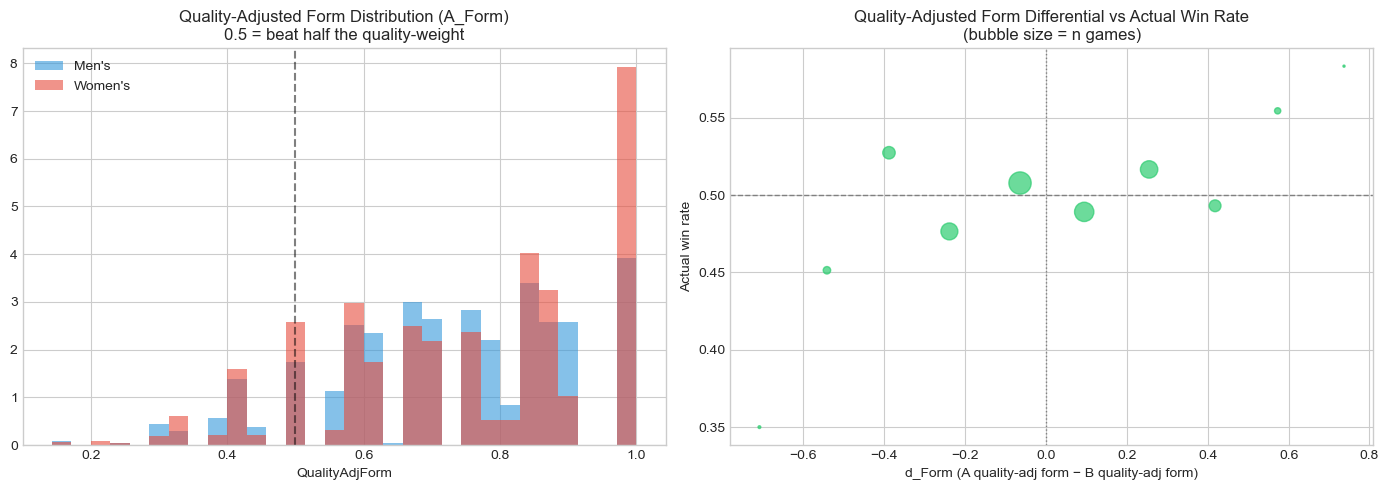

In [48]:
# ── 16F: Form Feature Analysis — Why Quality-Adjusted Win% > Plain Win% ────────
# Retrospective: did the redesigned form fix the negative Nelder-Mead weight?
# And what does the distribution look like across seed tiers?

# ── 1. Distribution comparison ────────────────────────────────────────────────
# d_Form is now quality-adjusted. Compare its correlation to the old binary version.
# Old form corr was negative in Nelder-Mead (-0.198 weight).
# If QualityAdjForm is working, d_Form correlation with Outcome should be positive
# AND the Nelder-Mead weight should have flipped positive this run.

print("=== Form Feature: Correlation with Outcome ===")
form_corr = matchups[["d_Form","Outcome"]].corr().iloc[0,1]
print(f"d_Form (QualityAdjForm differential) corr with Outcome: {form_corr:.4f}")
print("(Positive = higher quality-adjusted form → wins more. If still negative: investigate.)")

# ── 2. Form by seed tier ────────────────────────────────────────────────────────
# Do top seeds have higher quality-adjusted form? They should — good teams beat good
# opponents. If there's no monotone pattern, form is measuring something else.
print("\n=== QualityAdjForm by Seed Tier (A_Form) ===")
tourn_seeds = matchups[(matchups["A_Seed"] > 0)].copy()
tourn_seeds["seed_tier"] = pd.cut(tourn_seeds["A_Seed"],
                                   bins=[0,4,8,12,16],
                                   labels=["1-4","5-8","9-12","13-16"])
form_by_seed = tourn_seeds.groupby("seed_tier", observed=True).agg(
    n=("A_Form","count"),
    mean_form=("A_Form","mean"),
    std_form=("A_Form","std"),
).reset_index()
print(form_by_seed.round(3).to_string(index=False))
print("(Expect 1-4 seeds to have higher QualityAdjForm — they beat stronger opponents)")

# ── 3. Form vs outcome within seed buckets ─────────────────────────────────────
# The real test: within same-tier matchups, does the team with better QA-form win more?
print("\n=== Does better QualityAdjForm predict wins within same seed-gap buckets? ===")
me = matchups[(matchups["A_Seed"] > 0) & (matchups["B_Seed"] > 0)].copy()
me["seed_gap"] = abs(me["d_Seed"])
me["A_has_better_form"] = me["d_Form"] > 0

for gap_min, gap_max, label in [(0,2,"Close (0-2)"), (3,6,"Medium (3-6)"), (7,20,"Large (7+)")]:
    bucket = me[(me["seed_gap"] >= gap_min) & (me["seed_gap"] <= gap_max)]
    if len(bucket) < 50:
        continue
    # Win rate when A has better form
    a_wins_when_better_form = bucket[bucket["A_has_better_form"]]["Outcome"].mean()
    a_wins_when_worse_form  = bucket[~bucket["A_has_better_form"]]["Outcome"].mean()
    n_better = bucket["A_has_better_form"].sum()
    print(f"  {label}: A-has-better-form wins {a_wins_when_better_form:.3f} "
          f"vs {a_wins_when_worse_form:.3f} (n={n_better}/{len(bucket)})")

# ── 4. Nelder-Mead weight retrospective ───────────────────────────────────────
print("\n=== Nelder-Mead Weights (from this run) ===")
try:
    weights_str = ", ".join([f"{n}={w:.3f}" for n,w in zip(
        ["AdjEM","Elo","GLM","Form"], OPT_WEIGHTS)])
    print(f"Weights: {weights_str}")
    print("(Goal: Form weight should be POSITIVE after quality-adjustment redesign)")
    print("(Old Form weight was -0.198 — that was the plain binary win% version)")
except NameError:
    print("OPT_WEIGHTS not defined yet — run the optimizer cell first")

# ── 5. Form distribution by gender ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mw, label, color in [(0,"Men's","#3498db"), (1,"Women's","#e74c3c")]:
    sub = matchups[matchups["men_women"] == mw]["A_Form"].dropna()
    axes[0].hist(sub, bins=30, alpha=0.6, label=label, color=color, density=True)
axes[0].axvline(0.5, color="black", lw=1.5, ls="--", alpha=0.5)
axes[0].set_title("Quality-Adjusted Form Distribution (A_Form)\n0.5 = beat half the quality-weight")
axes[0].set_xlabel("QualityAdjForm"); axes[0].legend()

# Form vs outcome scatter (binned)
bins = pd.cut(me["d_Form"], bins=10)
scatter = me.groupby(bins, observed=True).agg(
    actual=("Outcome","mean"), n=("Outcome","count"), mid_form=("d_Form","mean")).reset_index()
axes[1].scatter(scatter["mid_form"], scatter["actual"], s=scatter["n"]/5, alpha=0.7, color="#2ecc71")
axes[1].axhline(0.5, color="gray", ls="--", lw=1)
axes[1].axvline(0, color="gray", ls=":", lw=1)
axes[1].set_xlabel("d_Form (A quality-adj form − B quality-adj form)")
axes[1].set_ylabel("Actual win rate")
axes[1].set_title("Quality-Adjusted Form Differential vs Actual Win Rate\n(bubble size = n games)")

plt.tight_layout(); plt.show()


## Section 14: Submission Generation

Build predictions for the submission file.  We need per-team features for the prediction
season (2026 regular season data, if available, else use 2025 computed ratings as proxy).

For each pair in the submission:
1. Look up team features for both teams
2. Compute feature differentials
3. Run through each LOTO model, average predictions (ensemble)
4. Clip to [0.025, 0.975] to avoid Brier-penalized extreme probabilities

**Stage 1**: predictions for all 2022-2025 tournament matchups (historical validation).
**Stage 2**: 2026 predictions — released ~March 17.  Check Kaggle forums for update.


In [49]:
# ── Determine prediction season ───────────────────────────────────────────────
LATEST_SEASON = adj_eff_df['Season'].max()
print(f'Latest computed season: {LATEST_SEASON}')

# ── Load Stage 1 submission (seeded matchups 2022-2025) ──────────────────────
sub = pd.read_csv(os.path.join(CONTEST_DIR, 'SampleSubmissionStage1.csv'))
sub['Season']   = sub['ID'].apply(lambda x: int(x.split('_')[0]))
sub['T1_TeamID']= sub['ID'].apply(lambda x: int(x.split('_')[1]))
sub['T2_TeamID']= sub['ID'].apply(lambda x: int(x.split('_')[2]))
sub['men_women']= sub['T1_TeamID'].apply(lambda x: 0 if str(x)[0] == '1' else 1)
print(f'Stage 1 submission rows (2022-2025 seeded): {len(sub):,}')

# ── Build 2026 seeded-teams-only matchups ─────────────────────────────────────
# Always generate from seeds CSVs so we only predict C(68,2) per gender,
# not the 132k all-pairs in Stage 2.
from itertools import combinations

rows_2026 = []
for mw, seeds_file in [(0, 'MNCAATourneySeeds.csv'), (1, 'WNCAATourneySeeds.csv')]:
    sf = pd.read_csv(os.path.join(CONTEST_DIR, seeds_file))
    sf26 = sf[sf['Season'] == PRED_YEAR]
    if len(sf26) == 0:
        print(f'WARNING: no 2026 seeds in {seeds_file}')
        continue
    team_ids = sorted(sf26['TeamID'].unique().tolist())
    print(f'{"Men" if mw==0 else "Women"} 2026 seeded teams: {len(team_ids)} → {len(team_ids)*(len(team_ids)-1)//2:,} pairs')
    for t1, t2 in combinations(team_ids, 2):
        rows_2026.append({
            'ID': f'{PRED_YEAR}_{t1}_{t2}',
            'Season': PRED_YEAR,
            'T1_TeamID': t1,
            'T2_TeamID': t2,
            'men_women': mw,
        })

sub_2026 = pd.DataFrame(rows_2026)
print(f'2026 matchup rows (seeded only): {len(sub_2026):,} (M+W)')

# ── Combine ───────────────────────────────────────────────────────────────────
sub = pd.concat([sub, sub_2026[['ID','Season','T1_TeamID','T2_TeamID','men_women']]], ignore_index=True)
print(f'Total submission rows: {len(sub):,}')
print(sub.head(3))


Latest computed season: 2026
Stage 1 submission rows (2022-2025 seeded): 519,144
Men 2026 seeded teams: 68 → 2,278 pairs
Women 2026 seeded teams: 68 → 2,278 pairs
2026 matchup rows (seeded only): 4,556 (M+W)
Total submission rows: 523,700
               ID  Pred  Season  T1_TeamID  T2_TeamID  men_women
0  2022_1101_1102   0.5    2022       1101       1102          0
1  2022_1101_1103   0.5    2022       1101       1103          0
2  2022_1101_1104   0.5    2022       1101       1104          0


In [50]:
# Build features for each submission row
# For each season in the submission, use that season's computed features
# (If 2026 data not yet computed, use LATEST_SEASON as fallback for 2026 rows)

def get_sub_features(mw, season, team):
    """Look up features for submission, falling back to LATEST_SEASON if season not found."""
    feats = get_team_features(mw, season, team)
    if all(np.isnan(v) if isinstance(v, float) else False for v in feats.values()):
        feats = get_team_features(mw, LATEST_SEASON, team)
    return feats

sub_records = []
for _, row in tqdm(sub.iterrows(), total=len(sub), desc='Build sub features'):
    mw, season = int(row['men_women']), int(row['Season'])
    ta, tb = int(row['T1_TeamID']), int(row['T2_TeamID'])
    fa = get_sub_features(mw, season, ta)
    fb = get_sub_features(mw, season, tb)

    rec = {'ID': row['ID'], 'Season': season, 'men_women': mw,
           'T1_TeamID': ta, 'T2_TeamID': tb}
    for c in FEAT_COLS:
        rec[f'A_{c}'] = fa.get(c, np.nan)
        rec[f'B_{c}'] = fb.get(c, np.nan)
        rec[f'd_{c}'] = fa.get(c, np.nan) - fb.get(c, np.nan)
    # Optimized rating
    z_vals = np.array([rec.get(c.replace('_z',''), 0) for c in Z_FEAT_COLS])
    rec['d_Rating'] = float(np.dot(OPT_WEIGHTS, z_vals))  # approx — use scaler below
    sub_records.append(rec)

sub_df = pd.DataFrame(sub_records)
# Fill NaN for features that exist in sub_df
for col in FEATURES:
    if col in sub_df.columns:
        sub_df[col] = sub_df[col].fillna(0)
    else:
        sub_df[col] = 0
print(f'sub_df shape: {sub_df.shape}')


Build sub features: 100%|██████████| 523700/523700 [02:05<00:00, 4176.58it/s]


sub_df shape: (523700, 168)


In [51]:

# ── Section 9.6 (continued): Submission path features ────────────────────────
# After the bracket is announced (Selection Sunday), seeds are known for all teams.
# For each matchup in sub_df:
#   1. Look up both teams' seed strings (e.g. 'W15', 'W03')
#   2. Determine which round they'd meet (from get_round_for_seed_pair)
#   3. For prior rounds: compute expected path quality from bracket-expected
#      opponent seeds → those seeds' 2026 AdjEM (averaged across possible slots)
#
# For Stage 1 historical matchups (2022-2025): all seeds are known.
# For Stage 2 (2026): requires seeds from SampleSubmissionStage2.csv or bracket.

# Build (mw, season, teamID) -> seed_string lookup
seeds_df = pd.concat([
    M_seeds_raw[['Season', 'Seed', 'TeamID']].assign(men_women=0),
    W_seeds_raw[['Season', 'Seed', 'TeamID']].assign(men_women=1)
], ignore_index=True)
seed_str_lut = {(int(r['men_women']), int(r['Season']), int(r['TeamID'])): r['Seed']
                for _, r in seeds_df.iterrows()}

def get_sub_path_feats(mw, season, team_a_id, team_b_id, adj_eff_df_season):
    """
    For a submission matchup, compute bracket-conditioned path features.
    adj_eff_df_season: subset of adj_eff_df for this (mw, season).

    Returns (round_num, a_path_q, b_path_q, a_prior_m=0, b_prior_m=0).
    Prior margins = 0 because no games have been played yet.
    """
    path_opp_dict = M_path_opp if mw == 0 else W_path_opp

    seed_a = seed_str_lut.get((mw, season, team_a_id))
    seed_b = seed_str_lut.get((mw, season, team_b_id))

    if seed_a is None or seed_b is None:
        return 1, 0.0, 0.0, 0.0, 0.0   # no seed data (2026 before bracket announced)

    rnd = get_round_for_seed_pair(seed_a, seed_b, path_opp_dict)
    if rnd is None:
        return 1, 0.0, 0.0, 0.0, 0.0   # cross-region edge case → treat as R1

    # Build seed → TeamID + AdjEM for this season
    seed_to_adjEM = {}
    for _, row in adj_eff_df_season.iterrows():
        sid = seed_str_lut.get((mw, season, int(row['TeamID'])))
        if sid:
            seed_to_adjEM[sid] = float(row['AdjEM'])

    def prior_path_quality(seed, through_round):
        """Mean AdjEM of bracket-expected opponents in rounds 1..through_round-1."""
        if through_round <= 1:
            return 0.0
        all_opp_ems = []
        for r in range(1, through_round):
            possible_opps = path_opp_dict.get(seed, {}).get(r, [])
            ems = [seed_to_adjEM[s] for s in possible_opps if s in seed_to_adjEM]
            if ems:
                all_opp_ems.append(float(np.mean(ems)))  # average of that round's possible opps
        return float(np.mean(all_opp_ems)) if all_opp_ems else 0.0

    a_pq = prior_path_quality(seed_a, rnd)
    b_pq = prior_path_quality(seed_b, rnd)
    return rnd, a_pq, b_pq, 0.0, 0.0   # prior_margin = 0 (no games played)

# ── Apply to sub_df ───────────────────────────────────────────────────────────
# Build per-(mw, season) AdjEM subset for speed
adj_sub_by_group = {}
for (mw_s, seas_s), grp in adj_eff_df.groupby(['men_women', 'Season']):
    adj_sub_by_group[(int(mw_s), int(seas_s))] = grp

print("Computing submission path features...")
sub_rn, sub_apq, sub_bpq, sub_apm, sub_bpm = [], [], [], [], []
for _, row in tqdm(sub_df.iterrows(), total=len(sub_df), desc='Sub path features'):
    mw = int(row['men_women']); s = int(row['Season'])
    a  = int(row['T1_TeamID']); b = int(row['T2_TeamID'])
    grp = adj_sub_by_group.get((mw, s),
          adj_sub_by_group.get((mw, max(k[1] for k in adj_sub_by_group if k[0]==mw))))
    rn, aq, bq, am, bm = get_sub_path_feats(mw, s, a, b, grp)
    sub_rn.append(rn); sub_apq.append(aq); sub_bpq.append(bq)
    sub_apm.append(am); sub_bpm.append(bm)

sub_df['round_num']      = sub_rn
sub_df['A_path_quality'] = sub_apq;  sub_df['B_path_quality'] = sub_bpq
sub_df['A_prior_margin'] = sub_apm;  sub_df['B_prior_margin'] = sub_bpm
sub_df['d_path_quality'] = sub_df['A_path_quality'] - sub_df['B_path_quality']
sub_df['d_prior_margin'] = sub_df['A_prior_margin'] - sub_df['B_prior_margin']

# Ensure all path feature columns exist for prediction
for col in ['round_num', 'A_path_quality', 'B_path_quality', 'd_path_quality',
            'A_prior_margin', 'B_prior_margin', 'd_prior_margin']:
    if col not in sub_df.columns:
        sub_df[col] = 0

print("\nSub round distribution:")
print(sub_df['round_num'].value_counts().sort_index().to_string())
print("\nSub path quality (R2+ rows):")
sub_r2 = sub_df[sub_df['round_num'] > 1]
print(sub_r2[['A_path_quality', 'B_path_quality', 'd_path_quality']].describe().round(2).to_string())
print(f"\nRows with 0 path quality (no seed data / R1): {(sub_df['A_path_quality']==0).sum():,}")


Computing submission path features...


Sub path features: 100%|██████████| 523700/523700 [00:53<00:00, 9792.79it/s] 


Sub round distribution:
round_num
1    505602
2       585
3      1173
4      2334
5      4679
6      9327

Sub path quality (R2+ rows):
       A_path_quality  B_path_quality  d_path_quality
count        18098.00        18098.00        18098.00
mean            22.55           20.57            1.99
std              6.49            8.81            9.29
min            -16.97          -16.97          -50.25
25%             17.66           16.95           -3.20
50%             22.08           21.02            0.48
75%             26.99           26.10            4.95
max             63.54           70.36           47.85

Rows with 0 path quality (no seed data / R1): 505,635


In [52]:
# ── Submission prediction: Step 1 — batched helper ───────────────────────────
# Root cause of kernel OOM: ~523k rows × 700 trees builds COO arrays of
# ~366M entries (~5 GB peak) before the sparse matrix is even created.
# Fix: process in small row batches so peak memory per batch is ~50 MB.
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize
import gc

BATCH_SIZE = 5_000  # rows per batch; reduce to 2_000 if still OOM

def fast_predict_sub_batched(model, calibrater, sub_X, batch_size=BATCH_SIZE):
    """
    Predict calibrated probabilities in row-batches to cap peak memory.
    Each batch of `batch_size` rows builds a ~50 MB sparse matrix instead
    of the full ~5 GB one. Mathematically identical to the single-pass version.
    """
    vectorizer = calibrater.named_steps['tfidfvectorizer']
    logreg     = calibrater.named_steps['logisticregression']
    vocab = vectorizer.vocabulary_
    idf   = vectorizer.idf_
    vocab_size = len(vocab)

    n_rows = len(sub_X)
    preds = np.empty(n_rows, dtype=np.float32)

    for start in range(0, n_rows, batch_size):
        end = min(start + batch_size, n_rows)
        n_batch = end - start

        # XGBoost leaf prediction for this batch
        d_batch = xgb.DMatrix(sub_X[start:end])
        leaves  = model.predict(d_batch, pred_leaf=True)  # (n_batch, n_trees)
        del d_batch

        n_trees = leaves.shape[1]
        tf = 1.0 / n_trees

        # Build COO sparse matrix — small because n_batch is small
        all_rows, all_cols, all_vals = [], [], []
        for j in range(n_trees):
            leaf_col = leaves[:, j].astype(int)
            for lv in np.unique(leaf_col):
                col = vocab.get(f'{j}_{lv}', -1)
                if col >= 0:
                    row_idx = np.where(leaf_col == lv)[0]
                    all_rows.append(row_idx)
                    all_cols.append(np.full(len(row_idx), col, dtype=np.int32))
                    all_vals.append(np.full(len(row_idx), tf * idf[col]))

        rows = np.concatenate(all_rows)
        cols = np.concatenate(all_cols)
        vals = np.concatenate(all_vals)
        X = normalize(csr_matrix((vals, (rows, cols)),
                                  shape=(n_batch, vocab_size)), norm='l2')
        preds[start:end] = logreg.predict_proba(X)[:, 1]
        del leaves, X, rows, cols, vals, all_rows, all_cols, all_vals

    return preds

print(f"fast_predict_sub_batched defined  (BATCH_SIZE={BATCH_SIZE:,})")


fast_predict_sub_batched defined  (BATCH_SIZE=5,000)


In [53]:
# # ── Submission prediction: Step 2 — ensemble + temperature scaling ────────────
# # Keep raw feature array — needed to slice batches inside fast_predict_sub_batched
# sub_X  = sub_df[FEATURES].values  # numpy array, not DMatrix (batching creates DMatrix per chunk)
# n_rows = len(sub_X)
# print(f"sub_df rows: {n_rows:,}  |  features: {len(FEATURES)}")

# all_preds = []
# seasons = sorted(models.keys())
# for oof_season in tqdm(seasons, desc='Ensemble predictions'):
#     calibrater = logistic_models[oof_season]
#     try:
#         probs = fast_predict_sub_batched(models[oof_season], calibrater, sub_X)
#     except Exception as e:
#         print(f'  Season {oof_season} failed: {e} — using 0.5')
#         probs = np.full(n_rows, 0.5)
#     all_preds.append(probs)
#     gc.collect()

# raw_mean = np.mean(all_preds, axis=0)
# del all_preds, sub_X
# gc.collect()

# # ── Per-gender temperature scaling — two-T Women's approach ──────────────────
# sub_df['seed_gap'] = (sub_df['A_Seed'] - sub_df['B_Seed']).abs()
# model_probs = np.array([
#     float(apply_temperature(
#         np.array([p]),
#         T_M_BLOWOUT        if (mw == 0 and sg > 10) else
#         TEMP_SCALE_BLOWOUT if (mw == 1 and sg > 8)  else
#         TEMP_SCALE[int(mw)]
#     )[0])
#     for p, mw, sg in zip(raw_mean, sub_df['men_women'], sub_df['seed_gap'])
# ])
# del raw_mean
# print(f"Done. T_M_close={TEMP_SCALE[0]:.3f}, T_M_blowout={T_M_BLOWOUT:.3f}, T_W_close={TEMP_SCALE[1]:.3f}, T_W_blowout={TEMP_SCALE_BLOWOUT:.3f}")


In [ ]:
# # ── Submission prediction: Step 3 — Vegas blend + final predictions ───────────
# sub_df['_key_lo'] = sub_df[['T1_TeamID', 'T2_TeamID']].min(axis=1)
# sub_df['_key_hi'] = sub_df[['T1_TeamID', 'T2_TeamID']].max(axis=1)
# sub_df['_a_is_lo'] = sub_df['T1_TeamID'] == sub_df['_key_lo']

# if len(lines_agg) > 0:
#     tmp_sub = sub_df.merge(
#         lines_agg.rename(columns={'T1_TeamID': '_key_lo', 'T2_TeamID': '_key_hi'}),
#         on=['Season', '_key_lo', '_key_hi'], how='left'
#     )
#     sub_vegas = np.where(
#         tmp_sub['_a_is_lo'].values,
#         tmp_sub['vegas_prob'].values,
#         1 - tmp_sub['vegas_prob'].values
#     )
# else:
#     sub_vegas = np.full(n_rows, np.nan)

# sub_df.drop(columns=['_key_lo', '_key_hi', '_a_is_lo'], inplace=True)

# # Blend model + Vegas (model-only fallback where no line)
# sub_df['Pred'] = [
#     float(VEGAS_ALPHA * p_model + (1 - VEGAS_ALPHA) * p_vegas)
#     if pd.notna(p_vegas) else float(p_model)
#     for p_model, p_vegas in zip(model_probs, sub_vegas)
# ]

# print(f"Temperature scaling: T_M_close={TEMP_SCALE[0]:.3f}, T_M_blowout={T_M_BLOWOUT:.3f}, T_W_close={TEMP_SCALE[1]:.3f}, T_W_blowout={TEMP_SCALE_BLOWOUT:.3f}")
# n_vegas = int(np.sum(~np.isnan(sub_vegas.astype(float))))
# print(f"Vegas blend alpha: {VEGAS_ALPHA:.3f} ({n_vegas} / {n_rows} lines matched)")
# print(f'\nPred distribution (Men):')
# print(sub_df[sub_df['men_women']==0]['Pred'].describe())
# print(f'\nPred distribution (Women):')
# print(sub_df[sub_df['men_women']==1]['Pred'].describe())
# extreme = sub_df[(sub_df['Pred'] > 0.95) | (sub_df['Pred'] < 0.05)]
# print(f'\nPredictions > 0.95 or < 0.05: {len(extreme)}')


NameError: name 'model_probs' is not defined

In [107]:
# # ── Export submission ────────────────────────────────────────────────────────
# # For 2026: merge model predictions into the full Stage 2 template.
# # Seeded-vs-seeded pairs → model prediction; everything else → 0.5.
# STAGE2_PATH = os.path.join(CONTEST_DIR, 'SampleSubmissionStage2.csv')

# if os.path.exists(STAGE2_PATH):
#     template = pd.read_csv(STAGE2_PATH)
#     seeded_preds = sub_df[sub_df['Season'] == PRED_YEAR][['ID', 'Pred']]
#     template = template[['ID']].merge(seeded_preds, on='ID', how='left')
#     template['Pred'] = template['Pred'].fillna(0.5)
#     hist_preds = sub_df[sub_df['Season'] < PRED_YEAR][['ID', 'Pred']]
#     out = pd.concat([
#         pd.read_csv(os.path.join(CONTEST_DIR, 'SampleSubmissionStage1.csv'))[['ID']]
#             .merge(hist_preds, on='ID', how='left'),
#         template[['ID', 'Pred']]
#     ], ignore_index=True)
#     out['Pred'] = out['Pred'].fillna(0.5)
# else:
#     out = sub_df[['ID', 'Pred']].copy()

# out_path = os.path.join(PROJECT_DIR, 'submission_2026_v1.csv')
# out.to_csv(out_path, index=False)
# n_seeded = (out['Pred'] != 0.5).sum()
# print(f'Saved {len(out):,} rows → submission_2026_v1.csv')
# print(f'  Model predictions: {n_seeded:,} | Default 0.5: {len(out)-n_seeded:,}')
# print(f'  Pred range: [{out["Pred"].min():.4f}, {out["Pred"].max():.4f}]')
# print(out.head(5))


Saved 651,277 rows → submission_2026_v1.csv
  Model predictions: 523,700 | Default 0.5: 127,577
  Pred range: [0.0000, 1.0000]
               ID      Pred
0  2022_1101_1102  0.770931
1  2022_1101_1103  0.371724
2  2022_1101_1104  0.559260
3  2022_1101_1105  0.880042
4  2022_1101_1106  0.906477


In [56]:
# ── Spread predictions: raw XGBoost point-differential output ───────────────
# The XGBoost model is trained on PointDiff (A_score - B_score), so its raw
# prediction is already a point spread.  Positive = T1 (lower TeamID) wins.
# We average across all LOTO models, exactly as in the probability pipeline.

sub_X_spread = sub_df[FEATURES].values

spread_preds = []
for oof_season in tqdm(sorted(models.keys()), desc="Spread predictions"):
    dm = xgb.DMatrix(sub_X_spread)
    raw_margin = models[oof_season].predict(dm)  # raw point-diff, no calibration
    spread_preds.append(raw_margin)

mean_spread = np.mean(spread_preds, axis=0)  # shape (n_rows,)
del spread_preds, sub_X_spread

# Attach to sub_df: positive = T1 (lower TeamID) wins by that many points
sub_df["Spread"] = mean_spread

# ── Build spread submission file (same template logic as probability submission)
STAGE2_PATH = os.path.join(CONTEST_DIR, "SampleSubmissionStage2.csv")

if os.path.exists(STAGE2_PATH):
    tmpl_spread = pd.read_csv(STAGE2_PATH)
    seeded_spreads = sub_df[sub_df["Season"] == PRED_YEAR][["ID", "Spread"]]
    tmpl_spread = tmpl_spread[["ID"]].merge(seeded_spreads, on="ID", how="left")
    tmpl_spread["Spread"] = tmpl_spread["Spread"].fillna(0.0)  # non-seeded pairs -> 0
    hist_spreads = sub_df[sub_df["Season"] < PRED_YEAR][["ID", "Spread"]]
    out_spread = pd.concat([
        pd.read_csv(os.path.join(CONTEST_DIR, "SampleSubmissionStage1.csv"))[["ID"]]
            .merge(hist_spreads, on="ID", how="left"),
        tmpl_spread[["ID", "Spread"]]
    ], ignore_index=True)
    out_spread["Spread"] = out_spread["Spread"].fillna(0.0)
else:
    out_spread = sub_df[["ID", "Spread"]].copy()

spread_path = os.path.join(PROJECT_DIR, "spread_predictions_2026.csv")
out_spread.to_csv(spread_path, index=False)

n_seeded_sp = int((out_spread["Spread"] != 0.0).sum())
spread_min = round(float(out_spread["Spread"].min()), 1)
spread_max = round(float(out_spread["Spread"].max()), 1)
print("Saved %d rows -> spread_predictions_2026.csv" % len(out_spread))
print("  Seeded matchups: %d | Non-seeded (0.0): %d" % (n_seeded_sp, len(out_spread) - n_seeded_sp))
print("  Spread range: [%.1f, %.1f]" % (spread_min, spread_max))

# Preview 2026 matchups
preview = sub_df[sub_df["Season"] == PRED_YEAR][["ID", "Spread", "men_women", "A_Seed", "B_Seed"]].copy()
preview["gender"] = preview["men_women"].map({0: "M", 1: "W"})
preview = preview.sort_values("Spread", ascending=False)


Spread predictions: 100%|██████████| 22/22 [00:06<00:00,  3.28it/s]


Saved 651277 rows -> spread_predictions_2026.csv
  Seeded matchups: 523700 | Non-seeded (0.0): 127577
  Spread range: [-54.4, 54.1]
